MODELO DE BENCHMARKING

PARTE I: ESTRUCTURA INICIAL.

Librerías

In [234]:
import pypsa #PyPSA: Python for Power System Analysis
import pandas as pd #Pandas: Biblioteca para manipulación y análisis de datos
import numpy as np #Numpy: Biblioteca para cálculos numéricos
import matplotlib.pyplot as plt #Matplotlib: Biblioteca para creación de gráficos
import matplotlib.dates as mdates #Matplotlib.dates: Módulo para manejar fechas en gráficos
#graficos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pypsa.options.api.new_components_api = True # Activar la nueva API de componentes de PyPSA

Elección del SRES MODE

In [235]:
SRES_MODE = "2busSRES"
#SRES_MODE = puedo poner "1busSRES" o "2busSRES" 
# "1busSRES" incluye un solo bus sres, que divide la generación electrica al mercado eléctrico y al mercado de hidrógeno
# "2busSRES" incluye un bus sres excedentes y un bus sres electrolyzer: es el método utilizado en el TYNDP26


Creación de Snapshot

In [236]:
# (1) Definir el periodo. 
hours=pd.date_range("2025-01-01", periods=24*7, freq="h")

# (2) Crear la red vacía con esos snapshots
network=pypsa.Network()
network.set_snapshots(hours)

# (3) Calcular el peso de cada hora para extrapolar a un año completo
hours_per_year=365*24
snapshot_weight=len(hours)
single_weight=hours_per_year/snapshot_weight

#(4) Asignar el peso a cada snapshot
network.snapshot_weightings = pd.DataFrame(
    index=network.snapshots,
    data={
        "objective": single_weight,
        "generators": single_weight,
        "stores": 1.0,
    }
)

Lectura de Hojas de Datos (excel integrado)

In [237]:
data = pd.read_excel(
    "modelo BenchMarking - s1Marruecos.xlsx",
    sheet_name=None,
    engine="openpyxl"
)
# Verificación de correcta lectura de datos
print(data.keys())  # Muestra las hojas disponibles en el archivo Excel


dict_keys(['Guide Sheet', 'carriers', 'buses_2busSRES', 'generators_2busSRES', 'links_2busSRES', 'loads', 'run_of_river_inflow', 'store', 'storage_units', 'demands', 'profiles', 'Datos Modificaciones Bus Europa', 'Obtencion de Datos', 'Obtención Datos Demandas'])


Asignación perfiles y demanda

In [238]:
from pathlib import Path
file = Path("modelo BenchMarking - s1Marruecos.xlsx")
hours_week = 168

def get_series(df, col, n_hours):
    if col not in df.columns:
        raise KeyError(f"La columna '{col}' no existe. Disponibles: {list(df.columns)}")
    return df[col].iloc[:n_hours].reset_index(drop=True)

sheets = pd.read_excel(
    file,
    sheet_name=["profiles", "run_of_river_inflow", "demands"]
)

df_profiles = sheets["profiles"].copy()
df_run_of_river_inflow = sheets["run_of_river_inflow"].copy()
df_demands = sheets["demands"].copy()

for df in [df_profiles, df_run_of_river_inflow, df_demands]:
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"])

profiles = {
    "ES": {
        "solar_pv": get_series(df_profiles, "ES_solar_pv_profile", hours_week),
        "solar_csp": get_series(df_profiles, "ES_solar_csp_profile", hours_week),
        "biomass": get_series(df_profiles, "ES_biomass_profile", hours_week),
        "wind": get_series(df_profiles, "ES_wind_profile", hours_week),
        "ccgt": get_series(df_profiles, "ES_ccgt_profile", hours_week),
        "turbina": get_series(df_profiles, "ES_turbine_profile", hours_week),
        "pump": get_series(df_profiles, "ES_pump_profile", hours_week),
        "SRES_electrolyzer": get_series(df_profiles, "ES_electrolyzer_profile", hours_week),
        "SRES_excedentes": get_series(df_profiles, "ES_excedentes_profile", hours_week),
        "reservoir": get_series(df_profiles, "ES_reservoir_profile", hours_week),
        "extragenerator": get_series(df_profiles, "ES_extragenerator", hours_week),
        "generacionh2": get_series(df_profiles, "ES_generacionh2SRES", hours_week),
    },
    "PT": {
        "solar_pv": get_series(df_profiles, "PT_solar_pv_profile", hours_week),
        "wind_onshore": get_series(df_profiles, "PT_wind_onshore_profile", hours_week),
        "wind_offshore": get_series(df_profiles, "PT_wind_offshore_profile", hours_week),
        "biomass": get_series(df_profiles, "PT_biomass_profile", hours_week),
        "ccgt": get_series(df_profiles, "PT_ccgt_profile", hours_week),
        "turbina": get_series(df_profiles, "PT_turbine_profile", hours_week),
        "pump": get_series(df_profiles, "PT_pump_profile", hours_week),
        "SRES_electrolyzer": get_series(df_profiles, "PT_electrolyzer_profile", hours_week),
        "SRES_excedentes": get_series(df_profiles, "PT_excedentes_profile", hours_week),
        "reservoir": get_series(df_profiles, "PT_reservoir_profile", hours_week),
        "extragenerator": get_series(df_profiles, "PT_extragenerator", hours_week),
        "generacionh2": get_series(df_profiles, "PT_generacionh2SRES", hours_week),
    },
    "FR": {
        "electricity_generator": get_series(df_profiles, "FR00_generation", hours_week),
        "h2_generation": get_series(df_profiles, "FRh2_generation", hours_week),
        "h2SW_generation": get_series(df_profiles, "FRh2SW_generation", hours_week),
        "h2S_storage": get_series(df_profiles, "FRh2S_storage", hours_week),
        "h2SW_storage": get_series(df_profiles, "FRh2SW_storage", hours_week),
        "precioFRh2": get_series(df_profiles, "FR_precioFRh2", hours_week),
        "h2_generation_plus": get_series(df_profiles, "FRh2_generation+", hours_week),      
    },
"EU": {
        "precioEUh2": get_series(df_profiles, "EU_precio", hours_week),
        "generacionh2": get_series(df_profiles, "EU_generation", hours_week),
},       

}

run_of_river = {
    "ES": get_series(df_run_of_river_inflow, "ES_hydraulic_profile", hours_week),
    "PT": get_series(df_run_of_river_inflow, "PT_hydraulic_profile", hours_week),
}


demands = {
    "ES": {
        "electricity": get_series(df_demands, "ES_demand_2040", hours_week),
        "hydrogen": get_series(df_demands, "ES_hydrogen_demand", hours_week),
    },
    "PT": {
        "electricity": get_series(df_demands, "PT_demand_2040", hours_week),
        "hydrogen": get_series(df_demands, "PT_hydrogen_demand", hours_week),
    },
    "FR": {
        "electricity": get_series(df_demands, "FR_demand_2040", hours_week),
        "hydrogen": get_series(df_demands, "FR_hydrogen_demand", hours_week),
        #"hydrogen_SW": get_series(df_demands, "FRSW_hydrogen_demand", hours_week),
        "h2S_storage": get_series(df_demands, "FRh2S_storage", hours_week),
        "h2SW_storage": get_series(df_demands, "FRh2SW_storage", hours_week),
      
    },
    "EU": {
        "hydrogen": get_series(df_demands, "EU_hydrogen_demand", hours_week),
}

}




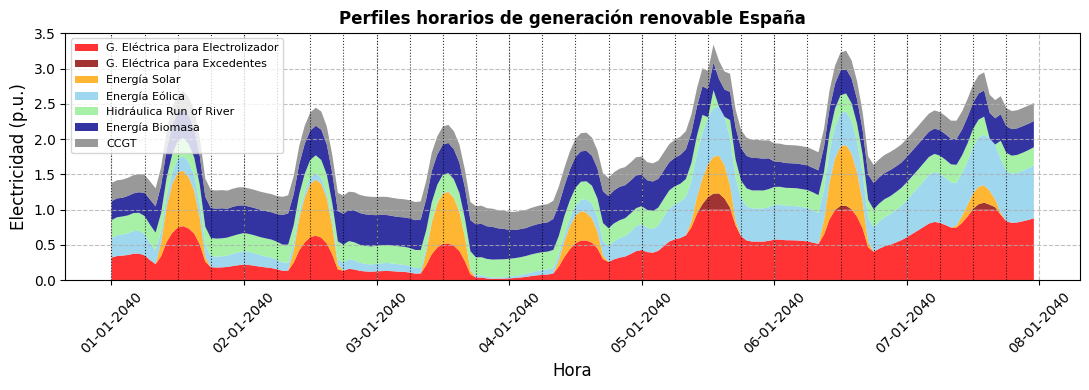

In [239]:
plt.figure(figsize=(11,4))
plt.style.use("default")

# Series
solar = profiles["ES"]["solar_pv"] + profiles["ES"]["solar_csp"]
wind = profiles["ES"]["wind"]
ror = run_of_river["ES"]
biomass = profiles["ES"]["biomass"]
ccgt = profiles["ES"]["ccgt"]
electrolyzer = profiles["ES"]["SRES_electrolyzer"]
excedentes = profiles["ES"]["SRES_excedentes"]

# Stackplot (orden importa)
plt.stackplot(
    hours,
    electrolyzer,
    excedentes,
    solar,
    wind,
    ror,
    biomass,
    ccgt,

    labels=[
        "G. Eléctrica para Electrolizador",
        "G. Eléctrica para Excedentes",
        "Energía Solar",
        "Energía Eólica",
        "Hidráulica Run of River",
        "Energía Biomasa",
        "CCGT",

    ],
    colors=["red", "darkred", "orange", "skyblue", "lightgreen", "darkblue", "grey" ],
    alpha=0.8
)

plt.title("Perfiles horarios de generación renovable España", fontsize=12, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Electricidad (p.u.)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.8)
plt.legend(loc="upper left", fontsize=8)

# Líneas verticales
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hh in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hh)
        plt.axvline(x=timestamp, color="black", linestyle=":", linewidth=0.8, alpha=0.8)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%m-2040"))

plt.tight_layout()
plt.show()

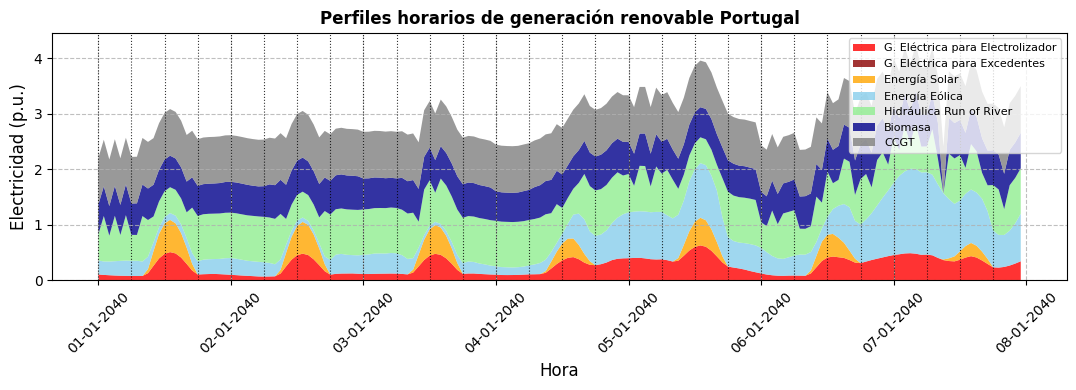

In [240]:
plt.figure(figsize=(11,4))
plt.style.use("default")

# Series
electrolyzer = profiles["PT"]["SRES_electrolyzer"]
excedentes = profiles["PT"]["SRES_excedentes"]
solar = profiles["PT"]["solar_pv"] 
wind = profiles["PT"]["wind_onshore"] + profiles["PT"]["wind_offshore"]
ror = run_of_river["PT"]
biomass = profiles["PT"]["biomass"]
ccgt = profiles["PT"]["ccgt"]


# Stackplot (orden importa)
plt.stackplot(
    hours,
    electrolyzer,
    excedentes,
    solar,
    wind,
    ror,
    biomass,
    ccgt,

    labels=[
        "G. Eléctrica para Electrolizador",
        "G. Eléctrica para Excedentes",
        "Energía Solar",
        "Energía Eólica",
        "Hidráulica Run of River",
        "Biomasa",
        "CCGT",

    ],
    colors=["red", "darkred", "orange", "skyblue", "lightgreen", "darkblue", "grey" ],
    alpha=0.8
)

plt.title("Perfiles horarios de generación renovable Portugal", fontsize=12, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Electricidad (p.u.)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.8)
plt.legend(loc="upper right", fontsize=8)

# Líneas verticales
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hh in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hh)
        plt.axvline(x=timestamp, color="black", linestyle=":", linewidth=0.8, alpha=0.8)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%m-2040"))

plt.tight_layout()
plt.show()

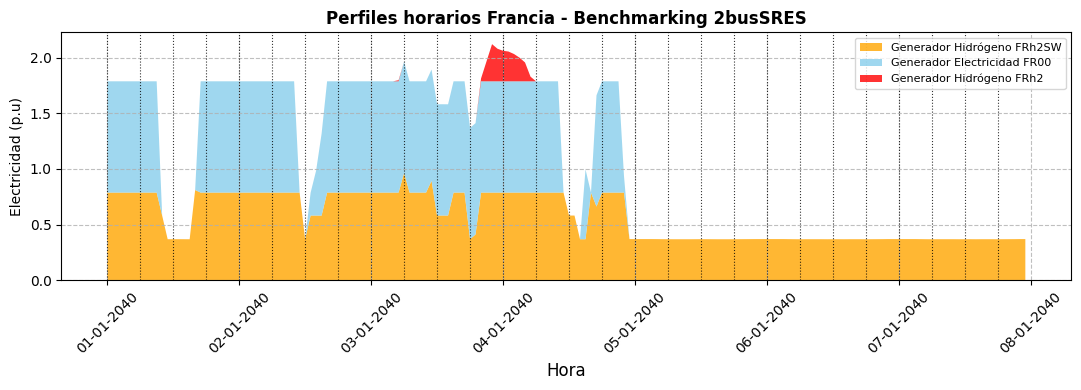

In [241]:
plt.figure(figsize=(11,4))
plt.style.use("default")

# Series
gen_h2SW = profiles["FR"]["h2SW_generation"]
gen_el = profiles["FR"]["electricity_generator"]
gen_h2 = profiles["FR"]["h2_generation"]


# Stackplot
plt.stackplot(
    hours,
    gen_h2SW,
    gen_el,
    gen_h2,
    
    labels=[
        "Generador Hidrógeno FRh2SW",
        "Generador Electricidad FR00",
        "Generador Hidrógeno FRh2",
        
    ],
    colors=["orange", "skyblue", "red"],
    alpha=0.8
)
# Líneas verticales
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hh in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hh)
        plt.axvline(x=timestamp, color="black", linestyle=":", linewidth=0.8, alpha=0.8)
plt.title("Perfiles horarios Francia - Benchmarking 2busSRES", fontsize=12, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Electricidad (p.u)", fontsize=10)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.8)
plt.legend(loc="upper right", fontsize=8)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%m-2040"))

plt.tight_layout()
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\1796371898.py:2: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



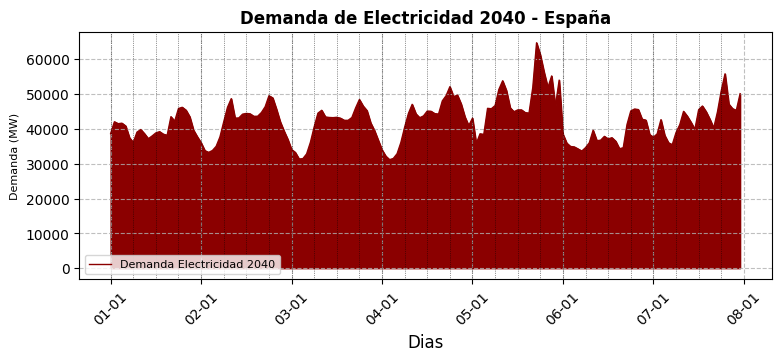

In [242]:
# Dibuja la Demanda para la primera semana de 2040.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="H") #para que no me ploteé el día 8 con 1 hora
plt.figure(figsize=(8, 4))
plt.style.use('default')

plt.plot(hours, demands["ES"]["electricity"], label="Demanda Electricidad 2040", color="darkred", linewidth=1, linestyle="-")

plt.fill_between(hours, demands["ES"]["electricity"], color="darkred", alpha=1)
plt.title("Demanda de Electricidad 2040 - España",  fontsize=12, fontweight="bold")
plt.xlabel("Dias", fontsize=12)
plt.ylabel("Demanda (MW)", fontsize=8)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.8)
plt.legend(loc="lower left", fontsize=8)
plt.tight_layout()

for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.8)
       
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%m"))
plt.xticks(rotation=45)
plt.show()

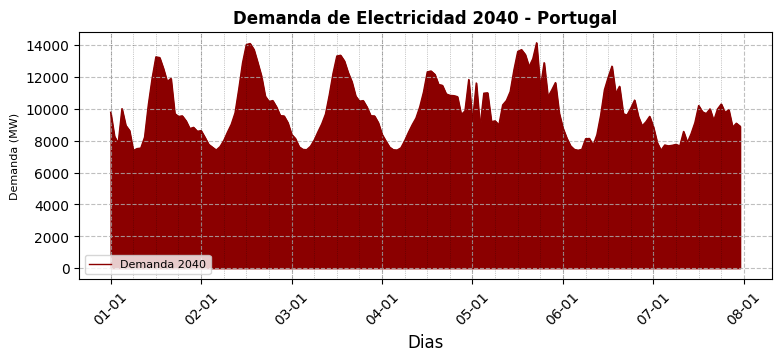

In [243]:
# Dibuja la Demanda para la primera semana de 2040.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") #para que no me ploteé el día 8 con 1 hora
plt.figure(figsize=(8, 4))
plt.style.use('default')
plt.plot(hours, demands["PT"]["electricity"], label="Demanda 2040", color="darkred", linewidth=1, linestyle="-")
plt.fill_between(hours, demands["PT"]["electricity"], color="darkred", alpha=1)
plt.title("Demanda de Electricidad 2040 - Portugal",  fontsize=12, fontweight="bold")
plt.xlabel("Dias", fontsize=12)
plt.ylabel("Demanda (MW)", fontsize=8)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.8)
plt.legend(loc="lower left", fontsize=8)
plt.tight_layout()

for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
       
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%m"))
plt.xticks(rotation=45)
plt.show()

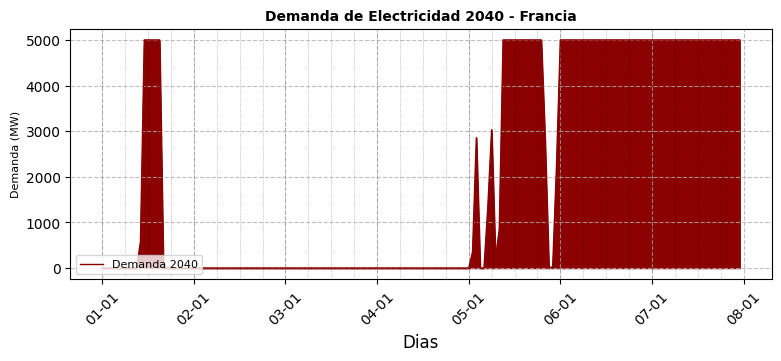

In [244]:
# Dibuja la Demanda para la primera semana de 2040.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") #para que no me ploteé el día 8 con 1 hora
plt.figure(figsize=(8 ,4))
plt.style.use('default')
plt.plot(hours, demands["FR"]["electricity"], label="Demanda 2040", color="darkred", linewidth=1, linestyle="-")
plt.fill_between(hours, demands["FR"]["electricity"], color="darkred", alpha=1)
plt.title("Demanda de Electricidad 2040 - Francia",  fontsize=10, fontweight="bold")
plt.xlabel("Dias", fontsize=12)
plt.ylabel("Demanda (MW)", fontsize=8)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.8)
plt.legend(loc="lower left", fontsize=8)
plt.tight_layout()

for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%m"))

plt.xticks(rotation=45)
plt.show()

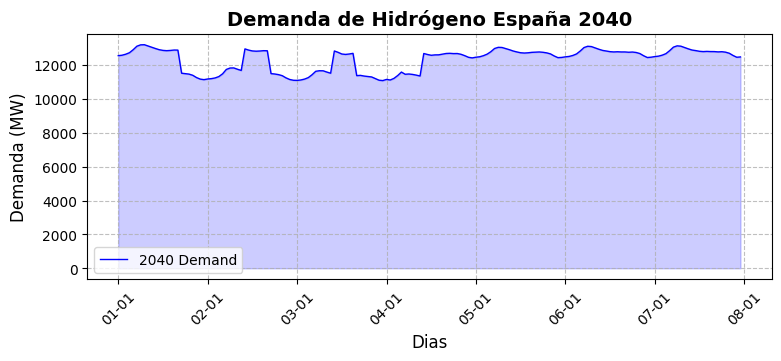

In [245]:
 # Dibuja la Demanda para la primera semana de 2040.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") #para que no me ploteé el día 8 con 1 hora
plt.figure(figsize=(8, 4))
plt.style.use('default')
plt.plot(hours, demands["ES"]["hydrogen"], label="2040 Demand", color="blue", linewidth=1, linestyle="-")
plt.fill_between(hours, demands["ES"]["hydrogen"], color="blue", alpha=0.2)
plt.title("Demanda de Hidrógeno España 2040",  fontsize=14, fontweight="bold")
plt.xlabel("Dias", fontsize=12)
plt.ylabel("Demanda (MW)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.8)
plt.legend(loc="lower left", fontsize=10)
plt.tight_layout()


plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%m"))
plt.xticks(rotation=45)
plt.show()

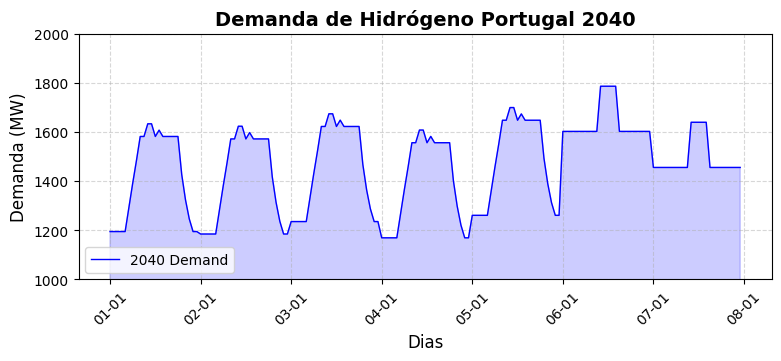

In [246]:
 # Dibuja la Demanda para la primera semana de 2040.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") #para que no me ploteé el día 8 con 1 hora
plt.figure(figsize=(8, 4))
plt.style.use('default')
plt.plot(hours, demands["PT"]["hydrogen"], label="2040 Demand", color="blue", linewidth=1, linestyle="-")
plt.fill_between(hours, demands["PT"]["hydrogen"], color="blue", alpha=0.2)
plt.title("Demanda de Hidrógeno Portugal 2040",  fontsize=14, fontweight="bold")
plt.xlabel("Dias", fontsize=12)
plt.ylabel("Demanda (MW)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="lower left", fontsize=10)
plt.tight_layout()
plt.ylim(1000,2000)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%m"))
plt.xticks(rotation=45)
plt.show()

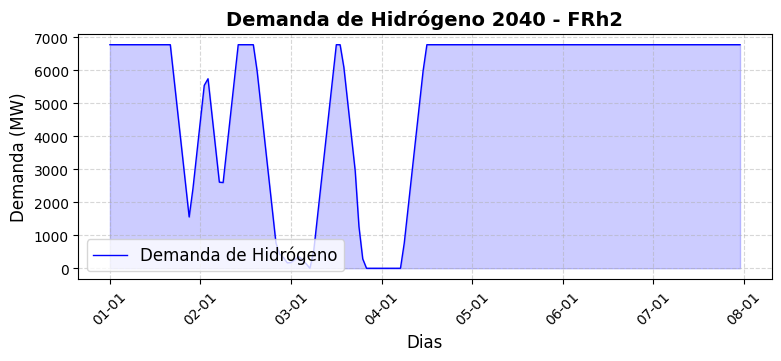

In [247]:
 # Dibuja la Demanda para la primera semana de 2040.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") #para que no me ploteé el día 8 con 1 hora
plt.figure(figsize=(8, 4))
plt.style.use('default')
plt.plot(hours, demands["FR"]["hydrogen"], label="Demanda de Hidrógeno", color="blue", linewidth=1, linestyle="-")
plt.fill_between(hours, demands["FR"]["hydrogen"], color="blue", alpha=0.2)
plt.title("Demanda de Hidrógeno 2040 - FRh2",  fontsize=14, fontweight="bold")
plt.xlabel("Dias", fontsize=12)
plt.ylabel("Demanda (MW)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="lower left", fontsize=12)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%m"))

plt.xticks(rotation=45)
plt.show()

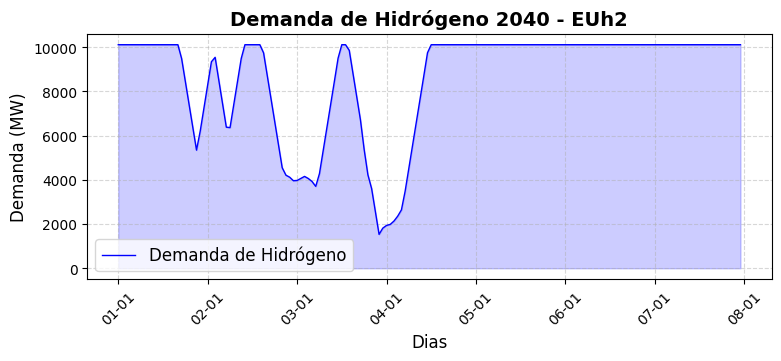

In [248]:
 # Dibuja la Demanda para la primera semana de 2040.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") #para que no me ploteé el día 8 con 1 hora
plt.figure(figsize=(8, 4))
plt.style.use('default')
plt.plot(hours, demands["EU"]["hydrogen"], label="Demanda de Hidrógeno", color="blue", linewidth=1, linestyle="-")
plt.fill_between(hours, demands["EU"]["hydrogen"], color="blue", alpha=0.2)
plt.title("Demanda de Hidrógeno 2040 - EUh2",  fontsize=14, fontweight="bold")
plt.xlabel("Dias", fontsize=12)
plt.ylabel("Demanda (MW)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="lower left", fontsize=12)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%m"))

plt.xticks(rotation=45)
plt.show()

PARTE II: CREACIÓN DEL ENTORNO: Llamada a Componentes

Carriers

In [249]:
# CARRIERS
df_carriers = data["carriers"]

for _, carrier in df_carriers.iterrows():
    network.add(
        "Carrier",
        carrier["name"].strip(),
        overwrite=carrier["overwrite"]
    )

# Verificación con API moderna
print("\n=== Carriers añadidos ===")
print(network.carriers.static)


=== Carriers añadidos ===
                   co2_emissions color nice_name  max_growth  \
name                                                           
AC                           0.0                         inf   
water                        0.0                         inf   
wind                         0.0                         inf   
gas                          0.0                         inf   
solar_pv                     0.0                         inf   
solar_csp                    0.0                         inf   
solar_rooftop                0.0                         inf   
grid_import                  0.0                         inf   
biomass                      0.0                         inf   
hydrogen                     0.0                         inf   
load_shedding                0.0                         inf   
nuclear                      0.0                         inf   
sres_electrolyzer            0.0                         inf   
sres_excedent

Buses

In [250]:
# BUSES
df_buses = data[f"buses_{SRES_MODE}"].copy()

for col in ["name", "carrier"]:
    df_buses[col] = (
        df_buses[col]
        .astype(str)
        .str.replace("\xa0", "", regex=False)
        .str.replace("\u200b", "", regex=False)
        .str.strip()
    )

if "overwrite" in df_buses.columns:
    df_buses["overwrite"] = (
        df_buses["overwrite"]
        .astype(str).str.strip().str.lower()
        .map({"true": True, "false": False, "1": True, "0": False})
        .fillna(False)
    )
else:
    df_buses["overwrite"] = False

for _, bus in df_buses.iterrows():
    network.add(
        "Bus",
        bus["name"],
        carrier=bus["carrier"],
        overwrite=bool(bus["overwrite"]),
        x=float(bus["x"]) if "x" in df_buses.columns and pd.notna(bus["x"]) else np.nan,
        y=float(bus["y"]) if "y" in df_buses.columns and pd.notna(bus["y"]) else np.nan,
    )

print("\n=== Buses añadidos ===")
print(network.buses.static)


=== Buses añadidos ===
                           v_nom type       x        y   carrier unit  \
name                                                                    
ES_electricity_market_bus    1.0      -3.7038  40.4168        AC        
ES_water_bus                 1.0      -3.7038  40.4168     water        
ES_gas_bus                   1.0      -3.7038  40.4168       gas        
ES_hydrogen_bus              1.0      -3.7038  40.4168  hydrogen        
ES_SRES_excedentes_bus       1.0      -3.7038  40.4168        AC        
ES_SRES_electrolyzer_bus     1.0      -3.7038  40.4168  hydrogen        
PT_electricity_market_bus    1.0      -9.1393  38.7223        AC        
PT_water_bus                 1.0      -9.1393  38.7223     water        
PT_gas_bus                   1.0      -9.1393  38.7223       gas        
PT_hydrogen_bus              1.0      -9.1393  38.7223  hydrogen        
PT_SRES_excedentes_bus       1.0      -9.1393  38.7223        AC        
PT_SRES_electrolyzer_bus   

In [251]:
# %% GENERADORES BENCHMARKING - 2busSRES

import numpy as np
import pandas as pd

df_generators = data[f"generators_{SRES_MODE}"].copy()

# -------------------------------------------------
# LIMPIEZA
# -------------------------------------------------
df_generators = df_generators.dropna(subset=["name", "bus", "carrier"]).copy()

for col in ["name", "bus", "carrier"]:
    df_generators[col] = (
        df_generators[col]
        .astype(str)
        .str.replace("\xa0", "", regex=False)
        .str.replace("\u200b", "", regex=False)
        .str.strip()
    )

# IMPORTANTE: incluir EU
df_generators = df_generators[
    df_generators["bus"].str.startswith(("ES", "PT", "FR", "FRS", "FRSW", "MA", "EU"))
].copy()

# overwrite booleano
if "overwrite" in df_generators.columns:
    df_generators["overwrite"] = (
        df_generators["overwrite"]
        .astype(str).str.strip().str.lower()
        .map({"true": True, "false": False, "1": True, "0": False})
        .fillna(False)
    )
else:
    df_generators["overwrite"] = False

# -------------------------------------------------
# HELPERS
# -------------------------------------------------
def get_country(bus_name):
    b = str(bus_name).strip().upper()

    if b.startswith("ES"):
        return "ES"
    if b.startswith("PT"):
        return "PT"
    if b.startswith("FRSW"):
        return "FRSW"
    if b.startswith("FRS"):
        return "FRS"
    if b.startswith("FR"):
        return "FR"
    if b.startswith("EU"):
        return "EU"

    return None


def get_profile(country, carrier_key, gen_name):
    """
    Devuelve:
        mode, profile

    mode:
        - p_max_pu: perfil en p.u. multiplicado por p_nom
        - p_set: generación exacta en MW
        - None: sin perfil
    """

    g = str(gen_name).strip().lower()
    c = str(carrier_key).strip().lower()

    # ---------------- ESPAÑA ----------------
    if country == "ES":

        if "sres" in g and c == "sres_excedentes":
            return "p_max_pu", profiles["ES"]["SRES_excedentes"]

        elif "sres" in g and c == "sres_electrolyzer":
            return "p_max_pu", profiles["ES"]["SRES_electrolyzer"]

        elif c == "solar_pv":
            return "p_max_pu", profiles["ES"]["solar_pv"]

        elif c == "solar_csp":
            return "p_max_pu", profiles["ES"]["solar_csp"]

        elif c == "wind":
            return "p_max_pu", profiles["ES"]["wind"]

        elif c == "water":
            return "p_max_pu", run_of_river["ES"]

        elif c == "biomass":
            return "p_max_pu", profiles["ES"]["biomass"]

        elif c == "reservoir":
            return "p_max_pu", profiles["ES"]["reservoir"]

        elif g == "es_extragenerator":
            return "p_set", profiles["ES"]["extragenerator"]

        else:
            return None, None

    # ---------------- PORTUGAL ----------------
    elif country == "PT":

        if "sres" in g and c == "sres_excedentes":
            return "p_max_pu", profiles["PT"]["SRES_excedentes"]

        elif "sres" in g and c == "sres_electrolyzer":
            return "p_max_pu", profiles["PT"]["SRES_electrolyzer"]

        elif c == "solar_pv":
            return "p_max_pu", profiles["PT"]["solar_pv"]

        elif c == "wind_onshore":
            return "p_max_pu", profiles["PT"]["wind_onshore"]

        elif c == "wind_offshore":
            return "p_max_pu", profiles["PT"]["wind_offshore"]

        elif c == "water":
            return "p_max_pu", run_of_river["PT"]

        elif c == "biomass":
            return "p_max_pu", profiles["PT"]["biomass"]

        elif c == "reservoir":
            return "p_max_pu", profiles["PT"]["reservoir"]

        elif g == "pt_extragenerator":
            return "p_set", profiles["PT"]["extragenerator"]

        else:
            return None, None

    # ---------------- FRANCIA ----------------
    elif country in ("FR", "FRS", "FRSW"):

        if g == "fr_electricity_generator":
            return "p_max_pu", profiles["FR"]["electricity_generator"]

        elif g == "fr_hydrogen_generator_frh2":
            return "p_max_pu", profiles["FR"]["h2_generation"]

        elif g == "fr_hydrogen_generator_frsw":
            return "p_max_pu", profiles["FR"]["h2SW_generation"]

        elif g == "frs_hydrogen_storage":
            return "p_set", profiles["FR"]["h2S_storage"]

        elif g == "frsw_hydrogen_storage":
            return "p_set", profiles["FR"]["h2SW_storage"]

        elif g == "fr_hydrogen_generator_frh2_plus":
            return "p_max_pu", profiles["FR"]["h2_generation_plus"]
    
        else:
            return None, None


    # ---------------- EUROPA ----------------
    elif country == "EU":

        if g == "eu_hydrogen_generator":
            return "p_set", profiles["EU"]["generacionh2"]

        else:
            return None, None

    return None, None


# -------------------------------------------------
# 1) AÑADIR GENERADORES ESTÁTICOS
# -------------------------------------------------
for _, gen in df_generators.iterrows():

    gen_name = gen["name"]

    kwargs = dict(
        bus=gen["bus"],
        p_nom=float(gen["p_nom"]),
        marginal_cost=float(gen["marginal_cost"]) if pd.notna(gen["marginal_cost"]) else 0.0,
        carrier=gen["carrier"],
        overwrite=bool(gen["overwrite"]),
    )

    network.add("Generator", gen_name, **kwargs)


# -------------------------------------------------
# 2) INICIALIZAR SERIES DINÁMICAS
# -------------------------------------------------
network.generators.dynamic["p_max_pu"] = pd.DataFrame(
    1.0,
    index=network.snapshots,
    columns=network.generators.static.index,
    dtype=float
)

network.generators.dynamic["p_set"] = pd.DataFrame(
    np.nan,
    index=network.snapshots,
    columns=network.generators.static.index,
    dtype=float
)

static_mc = network.generators.static["marginal_cost"].fillna(0.0).astype(float)

network.generators.dynamic["marginal_cost"] = pd.DataFrame(
    index=network.snapshots,
    columns=network.generators.static.index,
    dtype=float
)

for gen_name in network.generators.static.index:
    network.generators.dynamic["marginal_cost"].loc[:, gen_name] = static_mc.loc[gen_name]


# -------------------------------------------------
# 3) ASIGNAR PERFILES DE GENERACIÓN
# -------------------------------------------------
for _, gen in df_generators.iterrows():

    gen_name = gen["name"]
    carrier_key = gen["carrier"]
    country = get_country(gen["bus"])

    mode, profile = get_profile(country, carrier_key, gen_name)

    if profile is None:
        continue

    vals = pd.Series(profile).iloc[:len(network.snapshots)].to_numpy(dtype=float)
    vals = np.nan_to_num(vals, nan=0.0)

    if len(vals) != len(network.snapshots):
        raise ValueError(
            f"Perfil mal dimensionado para {gen_name}: "
            f"{len(vals)} valores vs {len(network.snapshots)} snapshots"
        )

    if mode == "p_max_pu":
        vals = np.clip(vals, 0.0, 1.0)
        network.generators.dynamic["p_max_pu"].loc[:, gen_name] = vals

    elif mode == "p_set":
        p_nom = float(network.generators.static.loc[gen_name, "p_nom"])

        if vals.max() > p_nom + 1e-6:
            raise ValueError(
                f"{gen_name}: max(p_set)={vals.max():.3f} MW > p_nom={p_nom:.3f} MW"
            )

        if np.any(vals < -1e-6):
            raise ValueError(f"{gen_name}: p_set contiene valores negativos")

        network.generators.dynamic["p_set"].loc[:, gen_name] = vals
        network.generators.dynamic["p_max_pu"].loc[:, gen_name] = 1.0


# -------------------------------------------------
# 4) ASIGNAR COSTES MARGINALES HORARIOS
# -------------------------------------------------
hourly_cost_profiles = {
    "FR_hydrogen_generator_FRh2_plus": profiles["FR"]["precioFRh2"],
    "EU_hydrogen_generator": profiles["EU"]["precioEUh2"],
}

for gen_name, price_profile in hourly_cost_profiles.items():

    if gen_name not in network.generators.static.index:
        raise KeyError(
            f"No existe el generador '{gen_name}'. "
            f"Disponibles: {list(network.generators.static.index)}"
        )

    mc = pd.Series(
        price_profile.iloc[:len(network.snapshots)].to_numpy(dtype=float),
        index=network.snapshots
    ).fillna(0.0)

    network.generators.dynamic["marginal_cost"].loc[:, gen_name] = mc.values


# -------------------------------------------------
# 5) VERIFICACIÓN
# -------------------------------------------------
print("\n=== Generadores añadidos ===")
print(network.generators.static[["bus", "p_nom", "marginal_cost", "carrier"]])

print("\n=== Costes horarios FR/EU ===")
print(
    network.generators.dynamic["marginal_cost"][
        ["FR_hydrogen_generator_FRh2_plus", "EU_hydrogen_generator"]
    ].head(20)
)

print("\n=== Perfiles p_set FR/EU ===")
cols_check = [c for c in ["EU_hydrogen_generator", "FR_hydrogen_generator_FRh2_plus"] 
              if c in network.generators.dynamic["p_set"].columns]
print(network.generators.dynamic["p_set"][cols_check].head(20))


=== Generadores añadidos ===
                                                       bus         p_nom  \
name                                                                       
ES_solar_pv                      ES_electricity_market_bus  8.300000e+04   
ES_solar_csp                     ES_electricity_market_bus  4.805000e+03   
ES_wind                          ES_electricity_market_bus  9.179979e+04   
ES_biomass                       ES_electricity_market_bus  2.462660e+03   
ES_gas                                          ES_gas_bus  1.000000e+13   
ES_water                         ES_electricity_market_bus  3.117919e+03   
ES_reservoir                     ES_electricity_market_bus  1.153630e+04   
ES_extragenerator                ES_electricity_market_bus  8.980000e+03   
ES_SRES_excedentes                  ES_SRES_excedentes_bus  3.260000e+04   
ES_SRES_electrolyzer              ES_SRES_electrolyzer_bus  4.339800e+04   
PT_solar_pv                      PT_electricity_market_bus

Generadores

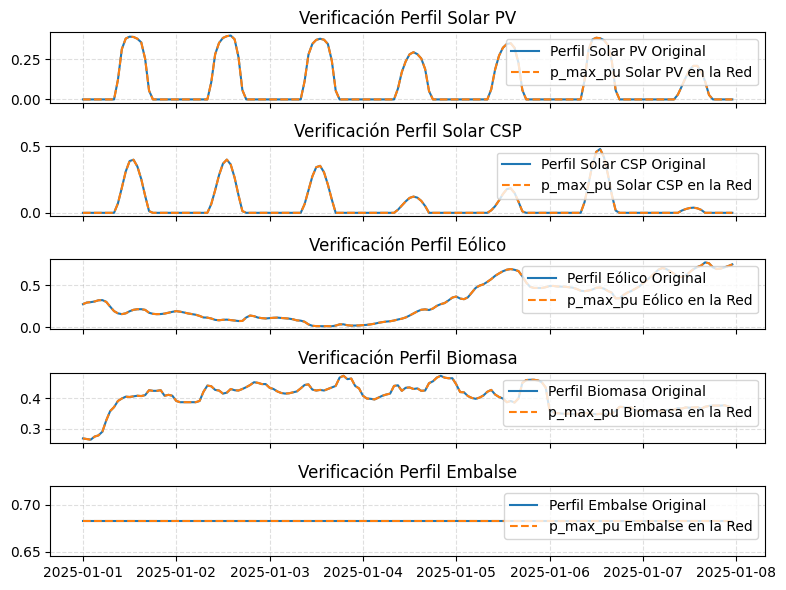

In [252]:
# %%
# Verificación de perfiles asignados correctamente: ES
es_solar_pv_profile = profiles["ES"]["solar_pv"].copy()
es_solar_csp_profile = profiles["ES"]["solar_csp"].copy()
es_wind_profile = profiles["ES"]["wind"].copy()
es_biomass_profile = profiles["ES"]["biomass"].copy()
es_reservoir_profile = profiles["ES"]["reservoir"].copy()

es_solar_pv_profile.index = network.snapshots[:len(es_solar_pv_profile)]
es_solar_csp_profile.index = network.snapshots[:len(es_solar_csp_profile)]
es_wind_profile.index = network.snapshots[:len(es_wind_profile)]
es_biomass_profile.index = network.snapshots[:len(es_biomass_profile)]
es_reservoir_profile.index = network.snapshots[:len(es_reservoir_profile)]

# Extraer perfiles INDIVIDUALES desde la red
solar_pv_pm = network.generators.dynamic["p_max_pu"]["ES_solar_pv"]
solar_csp_pm = network.generators.dynamic["p_max_pu"]["ES_solar_csp"]
gas_pm = network.generators.dynamic["p_max_pu"]["ES_gas"]
wind_pm = network.generators.dynamic["p_max_pu"]["ES_wind"]
biomass_pm = network.generators.dynamic["p_max_pu"]["ES_biomass"]
reservoir_pm = network.generators.dynamic["p_max_pu"]["ES_reservoir"]

# Gráfico
fig, axes = plt.subplots(5, 1, figsize=(8, 6), sharex=True)

axes[0].plot(es_solar_pv_profile.index, es_solar_pv_profile, label="Perfil Solar PV Original")
axes[0].plot(solar_pv_pm.index, solar_pv_pm, linestyle="--", label="p_max_pu Solar PV en la Red")
axes[0].set_title("Verificación Perfil Solar PV")
axes[0].legend(loc="upper right")
axes[0].grid(True, linestyle="--", alpha=0.4)

axes[1].plot(es_solar_csp_profile.index, es_solar_csp_profile, label="Perfil Solar CSP Original")
axes[1].plot(solar_csp_pm.index, solar_csp_pm, linestyle="--", label="p_max_pu Solar CSP en la Red")
axes[1].set_title("Verificación Perfil Solar CSP")
axes[1].legend(loc="upper right")
axes[1].grid(True, linestyle="--", alpha=0.4)

axes[2].plot(es_wind_profile.index, es_wind_profile, label="Perfil Eólico Original")
axes[2].plot(wind_pm.index, wind_pm, linestyle="--", label="p_max_pu Eólico en la Red")
axes[2].set_title("Verificación Perfil Eólico")
axes[2].legend(loc="upper right")
axes[2].grid(True, linestyle="--", alpha=0.4)

axes[3].plot(es_biomass_profile.index, es_biomass_profile, label="Perfil Biomasa Original")
axes[3].plot(biomass_pm.index, biomass_pm, linestyle="--", label="p_max_pu Biomasa en la Red")
axes[3].set_title("Verificación Perfil Biomasa")
axes[3].legend(loc="upper right")
axes[3].grid(True, linestyle="--", alpha=0.4)

axes[4].plot(es_reservoir_profile.index, es_reservoir_profile, label="Perfil Embalse Original")
axes[4].plot(reservoir_pm.index, reservoir_pm, linestyle="--", label="p_max_pu Embalse en la Red")
axes[4].set_title("Verificación Perfil Embalse")
axes[4].legend(loc="upper right")
axes[4].grid(True, linestyle="--", alpha=0.4)



plt.tight_layout()
plt.show()

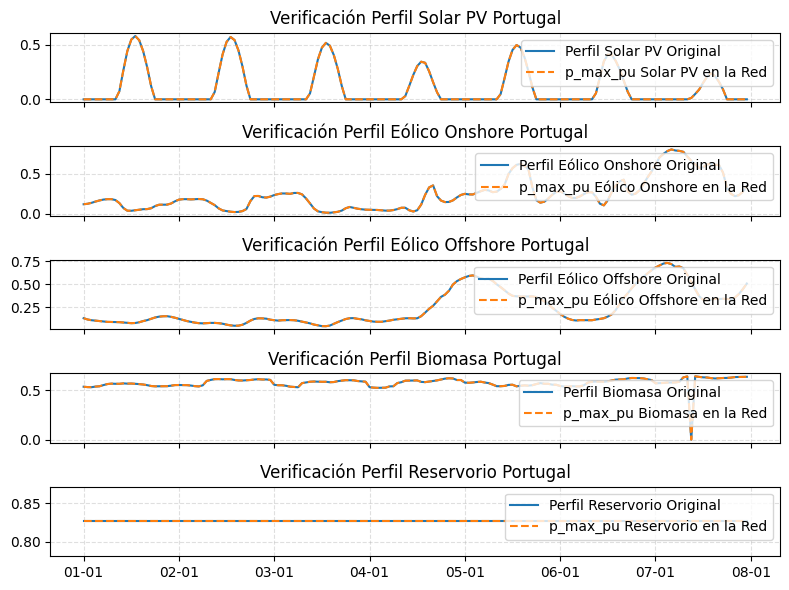

In [253]:
# %%
# Verificación de perfiles asignados correctamente: PT

pt_solar_pv_profile = profiles["PT"]["solar_pv"].copy()
pt_wind_onshore_profile = profiles["PT"]["wind_onshore"].copy()
pt_wind_offshore_profile = profiles["PT"]["wind_offshore"].copy()
pt_biomass_profile = profiles["PT"]["biomass"].copy()
pt_reservoir_profile = profiles["PT"]["reservoir"].copy()


pt_solar_pv_profile.index = network.snapshots[:len(pt_solar_pv_profile)]
pt_wind_onshore_profile.index = network.snapshots[:len(pt_wind_onshore_profile)]
pt_wind_offshore_profile.index = network.snapshots[:len(pt_wind_offshore_profile)]
pt_biomass_profile.index = network.snapshots[:len(pt_biomass_profile)]
pt_reservoir_profile.index = network.snapshots[:len(pt_reservoir_profile)]


# Extraer perfiles individuales desde la red
pt_solar_pv_pm = network.generators.dynamic["p_max_pu"]["PT_solar_pv"]
pt_wind_onshore_pm = network.generators.dynamic["p_max_pu"]["PT_wind_onshore"]
pt_wind_offshore_pm = network.generators.dynamic["p_max_pu"]["PT_wind_offshore"]
pt_biomass_pm = network.generators.dynamic["p_max_pu"]["PT_biomass"]
pt_reservoir_pm = network.generators.dynamic["p_max_pu"]["PT_reservoir"]

# Gráfico
fig, axes = plt.subplots(5, 1, figsize=(8, 6), sharex=True)

axes[0].plot(pt_solar_pv_profile.index, pt_solar_pv_profile, label="Perfil Solar PV Original")
axes[0].plot(pt_solar_pv_pm.index, pt_solar_pv_pm, linestyle="--", label="p_max_pu Solar PV en la Red")
axes[0].set_title("Verificación Perfil Solar PV Portugal")
axes[0].legend(loc="upper right")
axes[0].grid(True, linestyle="--", alpha=0.4)

axes[1].plot(pt_wind_onshore_profile.index, pt_wind_onshore_profile, label="Perfil Eólico Onshore Original")
axes[1].plot(pt_wind_onshore_pm.index, pt_wind_onshore_pm, linestyle="--", label="p_max_pu Eólico Onshore en la Red")
axes[1].set_title("Verificación Perfil Eólico Onshore Portugal")
axes[1].legend(loc="upper right")
axes[1].grid(True, linestyle="--", alpha=0.4)

axes[2].plot(pt_wind_offshore_profile.index, pt_wind_offshore_profile, label="Perfil Eólico Offshore Original")
axes[2].plot(pt_wind_offshore_pm.index, pt_wind_offshore_pm, linestyle="--", label="p_max_pu Eólico Offshore en la Red")
axes[2].set_title("Verificación Perfil Eólico Offshore Portugal")
axes[2].legend(loc="upper right")
axes[2].grid(True, linestyle="--", alpha=0.4)

axes[3].plot(pt_biomass_profile.index, pt_biomass_profile, label="Perfil Biomasa Original")
axes[3].plot(pt_biomass_pm.index, pt_biomass_pm, linestyle="--", label="p_max_pu Biomasa en la Red")
axes[3].set_title("Verificación Perfil Biomasa Portugal")
axes[3].legend(loc="upper right")
axes[3].grid(True, linestyle="--", alpha=0.4)


axes[4].plot(pt_reservoir_profile.index, pt_reservoir_profile, label="Perfil Reservorio Original")
axes[4].plot(pt_reservoir_pm.index, pt_reservoir_pm, linestyle="--", label="p_max_pu Reservorio en la Red")
axes[4].set_title("Verificación Perfil Reservorio Portugal")
axes[4].legend(loc="upper right")
axes[4].grid(True, linestyle="--", alpha=0.4)



axes[4].xaxis.set_major_formatter(mdates.DateFormatter("%d-%m"))

plt.tight_layout()
plt.show()

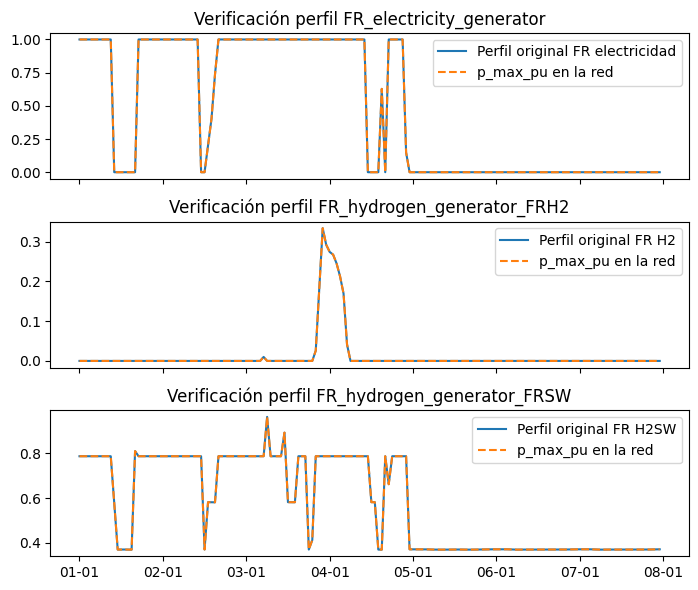

In [254]:
# Verificación de perfiles asignados correctamente: FR

fr_elec_profile = profiles["FR"]["electricity_generator"].copy()
fr_h2_profile = profiles["FR"]["h2_generation"].copy()
fr_h2sw_profile = profiles["FR"]["h2SW_generation"].copy()

fr_elec_profile.index = network.snapshots[:len(fr_elec_profile)]
fr_h2_profile.index = network.snapshots[:len(fr_h2_profile)]
fr_h2sw_profile.index = network.snapshots[:len(fr_h2sw_profile)]

# Extraer perfiles desde la red
fr_elec_pm = network.generators.dynamic["p_max_pu"]["FR_electricity_generator"]
fr_h2_pm = network.generators.dynamic["p_max_pu"]["FR_hydrogen_generator_FRH2"]
fr_h2sw_pm = network.generators.dynamic["p_max_pu"]["FR_hydrogen_generator_FRSW"]

# Gráfico
fig, axes = plt.subplots(3, 1, figsize=(7, 6), sharex=True)

axes[0].plot(fr_elec_profile.index, fr_elec_profile, label="Perfil original FR electricidad")
axes[0].plot(fr_elec_pm.index, fr_elec_pm, linestyle="--", label="p_max_pu en la red")
axes[0].set_title("Verificación perfil FR_electricity_generator")
axes[0].legend()

axes[1].plot(fr_h2_profile.index, fr_h2_profile, label="Perfil original FR H2")
axes[1].plot(fr_h2_pm.index, fr_h2_pm, linestyle="--", label="p_max_pu en la red")
axes[1].set_title("Verificación perfil FR_hydrogen_generator_FRH2")
axes[1].legend()

axes[2].plot(fr_h2sw_profile.index, fr_h2sw_profile, label="Perfil original FR H2SW")
axes[2].plot(fr_h2sw_pm.index, fr_h2sw_pm, linestyle="--", label="p_max_pu en la red")
axes[2].set_title("Verificación perfil FR_hydrogen_generator_FRSW")
axes[2].legend()

axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%d-%m"))

plt.tight_layout()
plt.show()

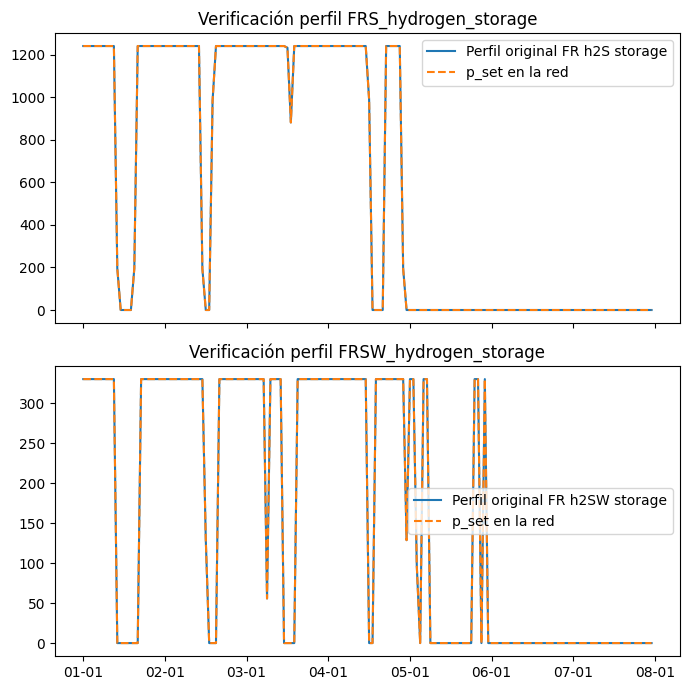

In [255]:
# Verificación de perfiles asignados correctamente: FR storage H2S / H2SW

fr_h2s_storage_profile = profiles["FR"]["h2S_storage"].copy()
fr_h2sw_storage_profile = profiles["FR"]["h2SW_storage"].copy()


fr_h2s_storage_profile.index = network.snapshots[:len(fr_h2s_storage_profile)]
fr_h2sw_storage_profile.index = network.snapshots[:len(fr_h2sw_storage_profile)]


# Extraer perfiles desde la red
h2s_pm = network.generators.dynamic["p_set"]["FRS_hydrogen_storage"]
h2sw_pm = network.generators.dynamic["p_set"]["FRSW_hydrogen_storage"]


# Gráfico
fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True)

axes[0].plot(fr_h2s_storage_profile.index, fr_h2s_storage_profile, label="Perfil original FR h2S storage")
axes[0].plot(h2s_pm.index, h2s_pm, linestyle="--", label="p_set en la red")
axes[0].set_title("Verificación perfil FRS_hydrogen_storage")
axes[0].legend()

axes[1].plot(fr_h2sw_storage_profile.index, fr_h2sw_storage_profile, label="Perfil original FR h2SW storage")
axes[1].plot(h2sw_pm.index, h2sw_pm, linestyle="--", label="p_set en la red")
axes[1].set_title("Verificación perfil FRSW_hydrogen_storage")
axes[1].legend()


axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%d-%m"))

plt.tight_layout()
plt.show()


Loads, demandas

In [256]:
# %% LOADS - BENCHMARKING

import numpy as np
import pandas as pd

# -------------------------------------------------
# 0) ASEGURAR QUE DEMANDS Y LOADS SON LOS DEL EXCEL
# -------------------------------------------------
# Opción A: si ya cargaste el Excel en un dict llamado data
demands_df = data["demands"].copy()
df_loads = data["loads"].copy()

# Si prefieres leer directo del Excel, usa esto en vez de lo anterior:
# excel_path = "modelo BenchMarking.xlsx"
# demands_df = pd.read_excel(excel_path, sheet_name="demands")
# df_loads = pd.read_excel(excel_path, sheet_name="loads")

# Limpiar nombres de columnas por si hay espacios ocultos
demands_df.columns = demands_df.columns.astype(str).str.strip()
df_loads.columns = df_loads.columns.astype(str).str.strip()

# Verificación de columnas esperadas
expected_cols = [
    "ES_demand_2040",
    "ES_hydrogen_demand",
    "PT_demand_2040",
    "PT_hydrogen_demand",
    "FR_demand_2040",
    "FR_hydrogen_demand",
    "EU_hydrogen_demand",
    #"FRSW_hydrogen_demand",
    "FRh2S_storage",
    "FRh2SW_storage",
]

missing = [col for col in expected_cols if col not in demands_df.columns]
if missing:
    raise KeyError(f"Faltan columnas en la hoja demands: {missing}")

# -------------------------------------------------
# 1) CREAR SERIES DE DEMANDA
# -------------------------------------------------
n_snap = len(network.snapshots)

ES_demand_hydrogen_series = pd.Series(
    demands_df["ES_hydrogen_demand"].iloc[:n_snap].to_numpy(dtype=float),
    index=network.snapshots
)
ES_demand_series = pd.Series(
    demands_df["ES_demand_2040"].iloc[:n_snap].to_numpy(dtype=float),
    index=network.snapshots
)

PT_demand_hydrogen_series = pd.Series(
    demands_df["PT_hydrogen_demand"].iloc[:n_snap].to_numpy(dtype=float),
    index=network.snapshots
)
PT_demand_series = pd.Series(
    demands_df["PT_demand_2040"].iloc[:n_snap].to_numpy(dtype=float),
    index=network.snapshots
)

FR_demand_hydrogen_series = pd.Series(
    demands_df["FR_hydrogen_demand"].iloc[:n_snap].to_numpy(dtype=float),
    index=network.snapshots
)
#FRSW_demand_hydrogen_series = pd.Series(
#    demands_df["FRSW_hydrogen_demand"].iloc[:n_snap].to_numpy(dtype=float),
#    index=network.snapshots
#)
FR_demand_series = pd.Series(
    demands_df["FR_demand_2040"].iloc[:n_snap].to_numpy(dtype=float),
    index=network.snapshots
)
FRS_demand_hydrogen_storage_series = pd.Series(
    demands_df["FRh2S_storage"].iloc[:n_snap].to_numpy(dtype=float),
    index=network.snapshots
)
FRSW_demand_hydrogen_storage_series = pd.Series(
    demands_df["FRh2SW_storage"].iloc[:n_snap].to_numpy(dtype=float),
    index=network.snapshots
)

EU_hydrogen_demand_series = pd.Series(
    demands_df["EU_hydrogen_demand"].iloc[:n_snap].to_numpy(dtype=float),
    index=network.snapshots
)
# -------------------------------------------------
# 2) AÑADIR LOADS ESTÁTICOS
# -------------------------------------------------
df_loads = df_loads.dropna(subset=["name", "bus", "carrier"]).copy()

for col in ["name", "bus", "carrier"]:
    df_loads[col] = df_loads[col].astype(str).str.strip()

if "overwrite" in df_loads.columns:
    df_loads["overwrite"] = (
        df_loads["overwrite"]
        .astype(str).str.strip().str.lower()
        .map({"true": True, "false": False, "1": True, "0": False})
        .fillna(False)
    )
else:
    df_loads["overwrite"] = False

for _, load in df_loads.iterrows():
    network.add(
        "Load",
        load["name"],
        bus=load["bus"],
        carrier=load["carrier"],
        overwrite=bool(load["overwrite"])
    )

# -------------------------------------------------
# 3) INICIALIZAR p_set DINÁMICO
# -------------------------------------------------
network.loads.dynamic["p_set"] = pd.DataFrame(
    0.0,
    index=network.snapshots,
    columns=network.loads.static.index,
    dtype=float
)

# -------------------------------------------------
# 4) ASIGNAR SERIES DINÁMICAS
# -------------------------------------------------
assignments = {
    "ES_hydrogen_demand": ES_demand_hydrogen_series,
    "ES_demand_2040": ES_demand_series,
    "PT_hydrogen_demand": PT_demand_hydrogen_series,
    "PT_demand_2040": PT_demand_series,
    "FR_hydrogen_demand": FR_demand_hydrogen_series,
   # "FRSW_hydrogen_demand": FRSW_demand_hydrogen_series,
    "FR_demand_2040": FR_demand_series,
    "FRh2S_storage": FRS_demand_hydrogen_storage_series,
    "FRh2SW_storage": FRSW_demand_hydrogen_storage_series,
    "EU_hydrogen_demand": EU_hydrogen_demand_series,
}

missing_loads = [name for name in assignments if name not in network.loads.static.index]
if missing_loads:
    raise KeyError(f"Estos loads no existen en network.loads.static: {missing_loads}")

for load_name, series in assignments.items():
    network.loads.dynamic["p_set"].loc[:, load_name] = series.values

# -------------------------------------------------
# 5) VERIFICACIÓN
# -------------------------------------------------
print("\n=== Columnas de demands_df ===")
print(demands_df.columns.tolist())

print("\n=== Loads estáticos ===")
print(network.loads.static)

print("\n=== Primeras filas de p_set dinámico ===")
print(network.loads.dynamic["p_set"].head())


=== Columnas de demands_df ===
['ES_demand_2040', 'ES_hydrogen_demand', 'PT_demand_2040', 'PT_hydrogen_demand', 'FR_demand_2040', 'FR_hydrogen_demand', 'FRh2S_storage', 'FRh2SW_storage', 'EU_hydrogen_demand']

=== Loads estáticos ===
                                          bus   carrier type  p_set  q_set  \
name                                                                         
ES_demand_2040      ES_electricity_market_bus        AC         0.0    0.0   
ES_hydrogen_demand            ES_hydrogen_bus  hydrogen         0.0    0.0   
PT_demand_2040      PT_electricity_market_bus        AC         0.0    0.0   
PT_hydrogen_demand            PT_hydrogen_bus  hydrogen         0.0    0.0   
FR_demand_2040      FR_electricity_market_bus        AC         0.0    0.0   
FR_hydrogen_demand            FR_hydrogen_bus  hydrogen         0.0    0.0   
FRh2S_storage                FRS_hydrogen_bus  hydrogen         0.0    0.0   
FRh2SW_storage              FRSW_hydrogen_bus  hydrogen        

Links

In [257]:
df_links = data[f"links_{SRES_MODE}"].copy()

for col in ["name", "bus0", "bus1", "carrier"]:
    df_links[col] = (
        df_links[col]
        .astype(str)
        .str.replace("\xa0", "", regex=False)
        .str.replace("\u200b", "", regex=False)
        .str.strip()
    )

if "overwrite" in df_links.columns:
    df_links["overwrite"] = (
        df_links["overwrite"]
        .astype(str).str.strip().str.lower()
        .map({"true": True, "false": False, "1": True, "0": False})
        .fillna(False)
    )
else:
    df_links["overwrite"] = False

# chequeo antes de añadir
bus_index = set(network.buses.static.index.astype(str))
missing0 = sorted(set(df_links["bus0"]) - bus_index)
missing1 = sorted(set(df_links["bus1"]) - bus_index)

print("Faltan bus0:", missing0)
print("Faltan bus1:", missing1)

if missing0 or missing1:
    raise ValueError("Hay buses en links que no coinciden exactamente con network.buses.static.index")


# -------------------------------------------------
# 1) AÑADIR LINKS ESTÁTICOS
# -------------------------------------------------
for _, lk in df_links.iterrows():

    kwargs = dict(
        bus0=lk["bus0"],
        bus1=lk["bus1"],
        p_nom=float(lk["p_nom"]),
        efficiency=float(lk["efficiency"]) if pd.notna(lk["efficiency"]) else 1.0,
        marginal_cost=float(lk["marginal_cost"]) if pd.notna(lk["marginal_cost"]) else 0.0,
        carrier=lk["carrier"],
        overwrite=bool(lk["overwrite"]),
    )

    if "p_min_pu" in df_links.columns and pd.notna(lk["p_min_pu"]):
        kwargs["p_min_pu"] = float(lk["p_min_pu"])

    # Convertir rampas MW/h -> p.u./h
    if "ramp_limit_up" in df_links.columns and pd.notna(lk["ramp_limit_up"]):
        kwargs["ramp_limit_up"] = float(lk["ramp_limit_up"]) / float(lk["p_nom"])

    if "ramp_limit_down" in df_links.columns and pd.notna(lk["ramp_limit_down"]):
        kwargs["ramp_limit_down"] = float(lk["ramp_limit_down"]) / float(lk["p_nom"])

    network.add("Link", lk["name"], **kwargs)


# -------------------------------------------------
# 2) INICIALIZAR p_max_pu DE LINKS
# -------------------------------------------------
network.links.dynamic["p_max_pu"] = pd.DataFrame(
    1.0,
    index=network.snapshots,
    columns=network.links.static.index,
    dtype=float
)


# -------------------------------------------------
# 3) ASIGNAR PERFILES CCGT A LINKS
# -------------------------------------------------
link_profiles = {
    "ES_CCGT": profiles["ES"]["ccgt"],
    "PT_CCGT": profiles["PT"]["ccgt"],
    "ES_turbina": profiles["ES"]["turbina"],
    "PT_turbina": profiles["PT"]["turbina"],
    "ES_pump": profiles["ES"]["pump"],
    "PT_pump": profiles["PT"]["pump"],
    "ES_SRES_electrolyzer": profiles["ES"]["generacionh2"],
    "PT_SRES_electrolyzer": profiles["PT"]["generacionh2"],
}

for link_name, profile in link_profiles.items():

    if link_name not in network.links.static.index:
        raise KeyError(
            f"El link '{link_name}' no existe en network.links. "
            f"Links disponibles: {list(network.links.static.index)}"
        )

    vals = pd.Series(profile).iloc[:len(network.snapshots)].to_numpy(dtype=float)

    if len(vals) != len(network.snapshots):
        raise ValueError(
            f"Perfil mal dimensionado para {link_name}: "
            f"{len(vals)} vs snapshots {len(network.snapshots)}"
        )

    vals = np.nan_to_num(vals, nan=0.0)
    vals = np.clip(vals, 0.0, 1.0)

    network.links.dynamic["p_max_pu"].loc[:, link_name] = vals



print("\n=== Links añadidos ===")
print(network.links.static[["bus0", "bus1", "carrier"]])

print("\n=== Perfiles p_max_pu asignados a links CCGT ===")
print(network.links.dynamic["p_max_pu"][["ES_CCGT", "PT_CCGT"]].head())

Faltan bus0: []
Faltan bus1: []

=== Links añadidos ===
                                                               bus0  \
name                                                                  
ES_CCGT                                                  ES_gas_bus   
ES_turbina                                             ES_water_bus   
ES_pump                                   ES_electricity_market_bus   
ES_electrolyzer                           ES_electricity_market_bus   
ES_SRES_electrolyzer                       ES_SRES_electrolyzer_bus   
ES_SRES_excedentes                           ES_SRES_excedentes_bus   
PT_CCGT                                                  PT_gas_bus   
PT_turbina                                             PT_water_bus   
PT_pump                                   PT_electricity_market_bus   
PT_electrolyzer                           PT_electricity_market_bus   
PT_SRES_electrolyzer                       PT_SRES_electrolyzer_bus   
PT_SRES_excedentes   

Almacenamientos y Baterias (Storage Units) y embalses (Store Unit)

In [258]:

df_storage = data["storage_units"]

for _, st in df_storage.iterrows():
    name = st["name"].strip()

    soc0=0.5*st["p_nom"]*st["max_hours"]  # Estado de carga inicial al 50%

    # Añadir atributos estáticos
    network.add(
        "StorageUnit",
        name,
        bus=st["bus"].strip(),
        p_nom=st["p_nom"],
        max_hours=st["max_hours"],
        efficiency_store=st["efficiency_store"],
        efficiency_dispatch=st["efficiency_dispatch"],
        marginal_cost=st["marginal_cost"],
        carrier=st["carrier"],
        overwrite=st["overwrite"],
        state_of_charge_initial= soc0, 
        cyclic_state_of_charge=False
    )

    print(f"✅ StorageUnit '{name}' añadida en bus {st['bus']}: {st['p_nom']} MW · {st['max_hours']} h")

# Verificación
print("\n=== Storage Units estáticos ===")
print(network.storage_units.static.head())

print("\n=== Storage Units dinámicos ===")
print(network.storage_units.dynamic.keys())


✅ StorageUnit 'ES_electricity_market_battery' añadida en bus ES_electricity_market_bus: 26698 MW · 2 h
✅ StorageUnit 'ES_hydrogen_market_battery' añadida en bus ES_hydrogen_bus: 2583 MW · 500 h
✅ StorageUnit 'PT_electricity_market_battery' añadida en bus PT_electricity_market_bus: 3000 MW · 4 h

=== Storage Units estáticos ===
                                                     bus control type  \
name                                                                    
ES_electricity_market_battery  ES_electricity_market_bus      PQ        
ES_hydrogen_market_battery               ES_hydrogen_bus      PQ        
PT_electricity_market_battery  PT_electricity_market_bus      PQ        

                                 p_nom  p_nom_mod  p_nom_extendable  \
name                                                                  
ES_electricity_market_battery  26698.0        0.0             False   
ES_hydrogen_market_battery      2583.0        0.0             False   
PT_electricity_market

In [259]:
df_store = data["store"].copy()
 
# normaliza la columna a boolean REAL
df_store["cyclic_state_of_charge"] = (
    df_store["cyclic_state_of_charge"]
    .astype(str).str.strip().str.lower()
    .map({"true": True, "false": False, "1": True, "0": False, "nan": False})
)

# si algo no mapea, lo dejamos en False (o lanza error si prefieres)
df_store["cyclic_state_of_charge"] = df_store["cyclic_state_of_charge"].fillna(False)

In [260]:
for _, store in df_store.iterrows():
    network.add(
        "Store",
        store["name"].strip(),
        bus=store["bus"].strip(),
        e_nom=store["e_nom"],
        e_initial=store["e_initial"], 
        e_min_pu=store["e_min_pu"],
        e_max_pu=store["e_max_pu"],
        e_cyclic=store["cyclic_state_of_charge"],
        #capital_cost=store["capital_cost"],
        marginal_cost=store["marginal_cost"],
        carrier=store["carrier"],
        overwrite=store["overwrite"]
    )

    print(f"✅ Store '{store['name']}' añadida en bus {store['bus']}: "
          f"{store['e_nom']} MWh · inicial {store['e_initial']} MWh · "
          f"min {store['e_min_pu']} pu · max {store['e_max_pu']} pu · "
          f"coste marginal {store['marginal_cost']}")

# Verificación con API moderna
print("\n=== Stores estáticos ===")
print(network.stores.static.head())


✅ Store 'ES_embalse' añadida en bus ES_water_bus: 20414989 MWh · inicial 18373490.1 MWh · min 0.2 pu · max 0.9 pu · coste marginal 1
✅ Store 'PT_embalse' añadida en bus PT_water_bus: 3307600 MWh · inicial 2976840.0 MWh · min 0.2 pu · max 0.9 pu · coste marginal 1

=== Stores estáticos ===
                     bus type carrier       e_nom  e_nom_mod  \
name                                                           
ES_embalse  ES_water_bus        water  20414989.0        0.0   
PT_embalse  PT_water_bus        water   3307600.0        0.0   

            e_nom_extendable  e_nom_min  e_nom_max  e_nom_set  e_min_pu  ...  \
name                                                                     ...   
ES_embalse             False        0.0        inf        NaN       0.2  ...   
PT_embalse             False        0.0        inf        NaN       0.2  ...   

            sign  marginal_cost  marginal_cost_quadratic  \
name                                                       
ES_embalse  

RESTRICCIONES

In [261]:
def enforce_storage_units_start_50_end_20(n, snapshots):
    m = n.model
    t0 = snapshots[0]
    tN = snapshots[-1]

    su_names = [
        "ES_electricity_market_battery",
        "ES_hydrogen_storage",
        "PT_electricity_market_battery",
    ]
    su_names = [x for x in su_names if x in n.storage_units.static.index]

    if not su_names:
        raise ValueError("No encuentro StorageUnits objetivo en network.storage_units.static")

    su = n.storage_units.static
    emax = su.loc[su_names, "p_nom"].astype(float) * su.loc[su_names, "max_hours"].astype(float)

    # Condición inicial real antes de optimizar
    n.storage_units.static.loc[su_names, "state_of_charge_initial"] = 0.50 * emax.values
    n.storage_units.static.loc[su_names, "cyclic_state_of_charge"] = False

    soc = m.variables["StorageUnit-state_of_charge"]
   
    # Inicio exacto al 50%
    m.add_constraints(
        soc.loc[t0, su_names] >= 0.50 * emax.values,
        name="storage_units_soc_50pct_start"
    )

    # Condición final: acabar al 20%
    m.add_constraints(
        soc.loc[tN, su_names] >= 0.20 * emax.values,
        name="storage_units_soc_20pct_end"
    )

In [262]:
def sres_constraints_excess_max_target(
    n, snapshots=None, countries=("ES","PT"),
    h2_share=0.50,      # solo para definir el "target eléctrico equivalente"
    excess_share=1,  # 100% máximo. en dispatching esto ponlo en 1
    tol=0.0
):
    """
    ÚNICA restricción:
      Excedentes eléctricos SRES <= excess_share * (h2_share*Demanda_H2/eff)   (en energía eléctrica)

    Requiere:
      Link: f"{c}_SRES_electrolyzer"  (para leer efficiency)
      Link: f"{c}_SRES_excedentes"    (p0 en MW_el)
      Load: f"{c}_hydrogen_demand" en loads_t.p_set
    """
    if snapshots is None:
        snapshots = n.snapshots

    m = n.model
    p_link = m.variables["Link-p"]

    # dims robustas
    dims = list(p_link.dims)
    snap_dim = "snapshot" if "snapshot" in dims else dims[0]
    link_dim = [d for d in dims if d != snap_dim][0]

    # pesos: MW -> MWh equivalente
    w = n.snapshot_weightings["objective"].reindex(snapshots).to_numpy(dtype=float)
    w_da = xr.DataArray(w, coords={snap_dim: snapshots}, dims=[snap_dim])

    links = n.links.static

    for c in countries:
        l_ely = f"{c}_SRES_electrolyzer"
        l_ex  = f"{c}_SRES_excedentes"
        load  = f"{c}_hydrogen_demand"

        if l_ely not in links.index:
            continue
        if l_ex not in links.index:
            raise KeyError(f"No existe link excedentes '{l_ex}'")
        if load not in n.loads_t.p_set.columns:
            raise KeyError(f"No existe load '{load}' en loads_t.p_set")

        eff = float(links.at[l_ely, "efficiency"])

        # p_ex (MW_el en bus0)
        p_ex = p_link.sel({link_dim: l_ex, snap_dim: snapshots})

        # Demanda H2 (MW_H2)
        h2 = n.loads_t.p_set[load].reindex(snapshots).fillna(0.0).to_numpy(dtype=float)

        # Energía total H2 demandada (MWh_H2)
        E_h2_dem = float(np.sum(h2 * w))

        # Target eléctrico equivalente (MWh_el)
        E_el_target = (h2_share * E_h2_dem) / eff

        # Energía excedentes (MWh_el)
        E_excess = (p_ex * w_da).sum(dim=snap_dim)

        m.add_constraints(
            E_excess <= excess_share * E_el_target + tol,
            name=f"{c}_SRES_excess_cap_energy"
        )

In [263]:
def extra_functionality_combined(n, snapshots):
    enforce_storage_units_start_50_end_20(n, snapshots)
    
    if SRES_MODE == "1busSRES":
        sres_constraints_excess_max_target(
            n,
            snapshots,
            countries=("ES", "PT"),
            h2_share=0.3,
            excess_share=1
        )

    elif SRES_MODE == "2busSRES":
        pass

In [264]:
# Antes de optimize: desactivar rampas nativas de PyPSA para Links
network.links.static["ramp_limit_up"] = np.nan
network.links.static["ramp_limit_down"] = np.nan

PARTE III: OPTIMIZACIÓN

In [265]:
network.optimize(
    solver_name="highs",
    extra_functionality=extra_functionality_combined
)

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 331.54it/s]
INFO:linopy.io: Writing time: 0.21s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 12432 primals, 28732 duals
Objective: 6.99e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-p_set, Link-fix-p-lower, Link-fix-p-upper, Store-fix-e-lower, Store-fix-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance, storage_units_soc_50pct_start, storage_units_soc_20pct_end were not assigned to the network.


('ok', 'optimal')

WARNING - buses no encontrados en la red: ['MA_hydrogen_bus']


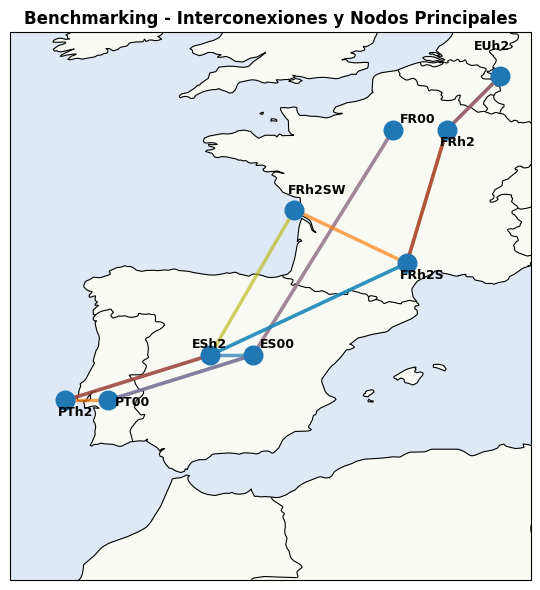

In [266]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# -------------------------------------------------
# 1) BUSES DEL BENCHMARKING 2busSRES
# -------------------------------------------------
wanted_buses = [
    "ES_electricity_market_bus",
    "ES_hydrogen_bus",
    "PT_electricity_market_bus",
    "PT_hydrogen_bus",
    "FR_electricity_market_bus",
    "FR_hydrogen_bus",
    "FRS_hydrogen_bus",
    "FRSW_hydrogen_bus",
    "MA_hydrogen_bus",
    "EU_hydrogen_bus",
]

# API robusta para buses
if hasattr(network.buses, "static"):
    buses_df = network.buses.static.copy()
elif hasattr(network.buses, "df"):
    buses_df = network.buses.df.copy()
else:
    buses_df = network.buses.copy()

# quedarnos solo con los que realmente existen en la red
existing_buses = [b for b in wanted_buses if b in buses_df.index]

missing_buses = [b for b in wanted_buses if b not in buses_df.index]
if missing_buses:
    print("WARNING - buses no encontrados en la red:", missing_buses)

bdf = buses_df.loc[existing_buses, ["x", "y", "carrier"]].copy()

# -------------------------------------------------
# 2) JITTER para separar buses con misma coordenada
# -------------------------------------------------
jitter = 0.8

grouped = bdf.groupby(["x", "y"])

for (x, y), idx in grouped.groups.items():
    idx = list(idx)
    if len(idx) > 1:
        angles = np.linspace(0, 2 * np.pi, len(idx), endpoint=False)
        for i, bus in enumerate(idx):
            bdf.loc[bus, "x"] = x + jitter * np.cos(angles[i])
            bdf.loc[bus, "y"] = y + jitter * np.sin(angles[i])

# -------------------------------------------------
# 3) INTERCONEXIONES ENTRE ELLOS
# -------------------------------------------------
edges = []

def add_edges(df, bus0="bus0", bus1="bus1"):
    if df is None or len(df) == 0:
        return
    for _, r in df.iterrows():
        if (r[bus0] in bdf.index) and (r[bus1] in bdf.index):
            edges.append((r[bus0], r[bus1]))

# Links
if hasattr(network, "links"):
    if hasattr(network.links, "static"):
        add_edges(network.links.static)
    elif hasattr(network.links, "df"):
        add_edges(network.links.df)
    else:
        add_edges(network.links)

# Lines
if hasattr(network, "lines"):
    if hasattr(network.lines, "static"):
        add_edges(network.lines.static)
    elif hasattr(network.lines, "df"):
        add_edges(network.lines.df)
    else:
        add_edges(network.lines)

# Transformers
if hasattr(network, "transformers"):
    if hasattr(network.transformers, "static"):
        add_edges(network.transformers.static)
    elif hasattr(network.transformers, "df"):
        add_edges(network.transformers.df)
    else:
        add_edges(network.transformers)

# eliminar duplicados visuales
edges = list(dict.fromkeys(edges))

# -------------------------------------------------
# 4) MAPA BASE
# -------------------------------------------------
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, alpha=0.25)
ax.add_feature(cfeature.OCEAN, alpha=0.3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.8)

ax.set_extent([-12, 7.5, 32.0, 52.5], crs=ccrs.PlateCarree())

# -------------------------------------------------
# 5) DIBUJAR INTERCONEXIONES
# -------------------------------------------------
for b0, b1 in edges:
    x0, y0 = bdf.loc[b0, ["x", "y"]]
    x1, y1 = bdf.loc[b1, ["x", "y"]]

    ax.plot(
        [x0, x1],
        [y0, y1],
        linewidth=2.5,
        alpha=0.7,
        transform=ccrs.PlateCarree(),
        zorder=3,
    )

# -------------------------------------------------
# 6) DIBUJAR BUSES
# -------------------------------------------------
ax.scatter(
    bdf["x"],
    bdf["y"],
    s=180,
    transform=ccrs.PlateCarree(),
    zorder=5,
)

label_offset = {
    "ES_electricity_market_bus": (0.25, 0.25),
    "ES_hydrogen_bus": (-0.7, 0.25),
    "PT_electricity_market_bus": (0.25, -0.2),
    "PT_hydrogen_bus": (-0.25, -0.6),
    "FR_electricity_market_bus": (0.25, 0.25),
    "FR_hydrogen_bus": (-0.25, -0.6),
    "FRS_hydrogen_bus": (-0.25, -0.6),
    "FRSW_hydrogen_bus": (-0.25, 0.6),
    "MA_hydrogen_bus": (0.45, -0.2),
    "EU_hydrogen_bus": (-1, 1),
}

label_map = {
    "ES_electricity_market_bus": "ES00",
    "ES_hydrogen_bus": "ESh2",
    "PT_electricity_market_bus": "PT00",
    "PT_hydrogen_bus": "PTh2",
    "FR_electricity_market_bus": "FR00",
    "FR_hydrogen_bus": "FRh2",
    "FRS_hydrogen_bus": "FRh2S",
    "FRSW_hydrogen_bus": "FRh2SW",
    "MA_hydrogen_bus": "MAh2",
    "EU_hydrogen_bus": "EUh2",
}

for name, r in bdf.iterrows():
    label = label_map.get(name, name)
    dx, dy = label_offset.get(name, (0.2, 0.2))

    ax.text(
        r["x"] + dx,
        r["y"] + dy,
        label,
        transform=ccrs.PlateCarree(),
        fontsize=9,
        fontweight="bold",
        zorder=6,
    )

ax.set_title(
    "Benchmarking - Interconexiones y Nodos Principales",
    fontweight="bold",
)

plt.tight_layout()
plt.show()

PARTE IV: OBTENCIÓN DE RESULTADOS.

Guardar resultados en Excel 

In [267]:
# Guardar resultados en un archivo Excel
network.export_to_excel(
    r"C:\Users\EXT10348\Downloads\WinPython 3.12.10\WPy64-31241\PROYECTOS PYPSA\Dispatching-Project-in-PypSA\hojas_de_datos\ResultadosBenchMarking.xlsx",
    engine="openpyxl"
)


INFO:pypsa.network.io:Exported network 'Unnamed Network' saved to 'C:\Users\EXT10348\Downloads\WinPython 3.12.10\WPy64-31241\PROYECTOS PYPSA\Dispatching-Project-in-PypSA\hojas_de_datos\ResultadosBenchMarking.xlsx contains: generators, buses, sub_networks, carriers, stores, links, loads, storage_units


Mapa Cobertura Demanda

Buses dibujados: ['ES_electricity_market_bus', 'ES_hydrogen_bus', 'PT_electricity_market_bus', 'PT_hydrogen_bus', 'FR_electricity_market_bus', 'FR_hydrogen_bus', 'FRS_hydrogen_bus', 'FRSW_hydrogen_bus']
Links dibujados: ['ES_PT_interconexion_electricidad', 'PT_ES_interconexion_electricidad', 'ES_PT_interconexion_hidrogeno', 'PT_ES_interconexion_hidrogeno', 'ES_FR_interconexion_electricidad', 'FR_ES_interconexion_electricidad', 'FR_ES_interconexion_hidrogeno_BarMar', 'ES_FR_interconexion_hidrogeno_BarMar', 'ES_FR_interconexion_hidrogeno_IrunLarrau', 'FR_FR_interconexion_hidrogeno_SWtoS', 'FR_FR_interconexion_hidrogeno_StoFRh2', 'FR_FR_interconexion_hidrogeno_FRh2toS', 'ES_electrolyzer', 'PT_electrolyzer']
ES elec<->ES H2 detectado: ['ES_electrolyzer']
PT elec<->PT H2 detectado: ['PT_electrolyzer']
FR elec<->FR H2 detectado: []
MA elec<->MA H2 detectado: []
FR H2 buses detectados: ['FR_hydrogen_bus', 'FRS_hydrogen_bus', 'FRSW_hydrogen_bus']

Cobertura agregada por bus y tecnología:
bus  

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\2074980915.py:351: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\2074980915.py:356: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\2074980915.py:360: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\2074980915.py:356: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more info

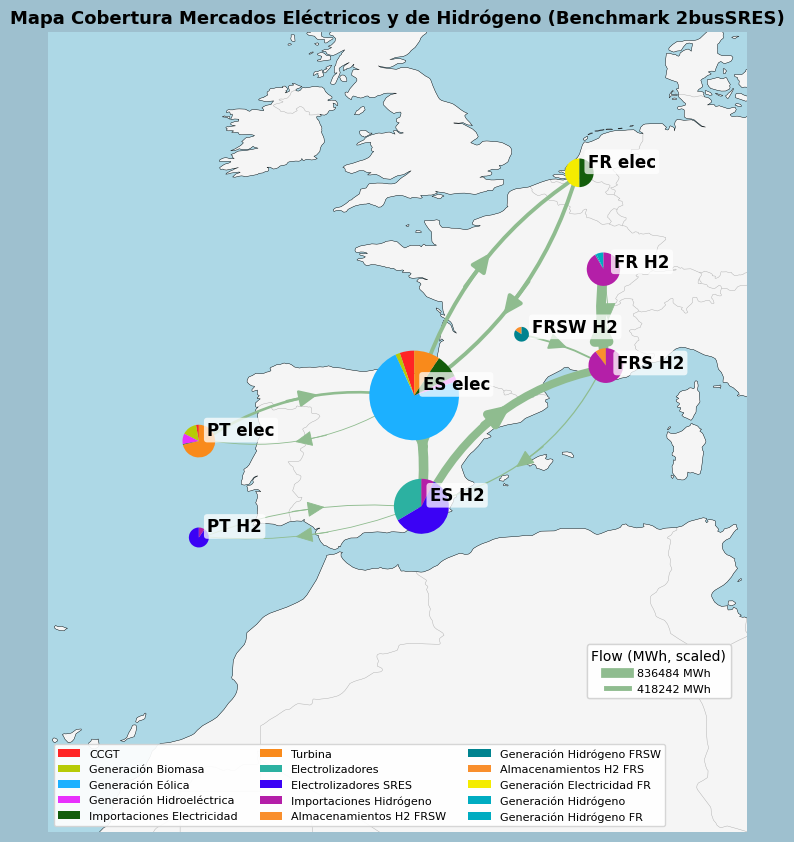

In [268]:
# ============================================================
# MAPA "IMAGEN 1" — PIES = COBERTURA DEMANDA (BENCHMARK 2busSRES)
# VERSIÓN ACTUALIZADA:
# - FR con 3 nodos H2: FR_hydrogen_bus, FRS_hydrogen_bus, FRSW_hydrogen_bus
# - Nuevos generadores:
#       FRS_hydrogen_storage
#       FRSW_hydrogen_storage
# - Se elimina el cómputo de storage_units como cobertura
# - Se corrige clasificación para evitar hidro falsa en FRS/FRSW
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.patches import FancyArrowPatch
from matplotlib.path import Path

n = network

# -------------------------------------------------
# Helpers API robusta PyPSA
# -------------------------------------------------
def get_static_df(component):
    if hasattr(component, "static"):
        return component.static.copy()
    if hasattr(component, "df"):
        return component.df.copy()
    return component.copy()

buses_df = get_static_df(n.buses)
links_df = get_static_df(n.links) if hasattr(n, "links") else pd.DataFrame()
generators_df = get_static_df(n.generators) if hasattr(n, "generators") else pd.DataFrame()
carriers_df = get_static_df(n.carriers) if hasattr(n, "carriers") else pd.DataFrame()

# -------------------------------------------------
# 0) Ajustes visuales
# -------------------------------------------------
extent_system = (-17.5, 11.5, 24.3, 57.5)
bus_size_factor = 1.9e6

# -------------------------------------------------
# 1) Buses objetivo
# -------------------------------------------------
b_e_es = "ES_electricity_market_bus"
b_h_es = "ES_hydrogen_bus"

b_e_pt = "PT_electricity_market_bus"
b_h_pt = "PT_hydrogen_bus"

b_e_fr = "FR_electricity_market_bus"
fr_h2_buses = [
    "FR_hydrogen_bus",
    "FRS_hydrogen_bus",
    "FRSW_hydrogen_bus",
]

b_h_ma = "MA_hydrogen_bus"

wanted_buses = [
    b_e_es, b_h_es,
    b_e_pt, b_h_pt,
    b_e_fr,
    *fr_h2_buses,
    b_h_ma
]
wanted_buses = [b for b in wanted_buses if b in buses_df.index]
wanted_bus_set = set(wanted_buses)

print("Buses dibujados:", wanted_buses)

# -------------------------------------------------
# 2) Links a dibujar
# -------------------------------------------------
L = links_df.copy() if len(links_df) else pd.DataFrame(columns=["bus0", "bus1"])

links_cross_exact = [
    "ES_PT_interconexion_electricidad",
    "PT_ES_interconexion_electricidad",
    "ES_PT_interconexion_hidrogeno",
    "PT_ES_interconexion_hidrogeno",
    "ES_FR_interconexion_electricidad",
    "FR_ES_interconexion_electricidad",
    "MA_ES_interconexion_hidrogeno",
    "FR_ES_interconexion_hidrogeno_BarMar",
    "ES_FR_interconexion_hidrogeno_BarMar",
]

links_cross_pattern = [
    name for name in L.index
    if (
        "es_fr_interconexion_hidrogeno" in str(name).lower()
        or "fr_es_interconexion_hidrogeno" in str(name).lower()
        or "fr_fr_interconexion_hidrogeno" in str(name).lower()
        or "barmar" in str(name).lower()
    )
]

links_cross = [l for l in links_cross_exact if l in L.index] + links_cross_pattern
links_cross = list(dict.fromkeys(links_cross))

def find_internal(prefix):
    if len(L) == 0:
        return []

    if prefix == "MA":
        return []

    be = f"{prefix}_electricity_market_bus"

    if prefix == "FR":
        bh_list = [b for b in fr_h2_buses if b in buses_df.index]
        mask = (
            ((L["bus0"] == be) & (L["bus1"].isin(bh_list))) |
            ((L["bus1"] == be) & (L["bus0"].isin(bh_list)))
        )
    else:
        bh = f"{prefix}_hydrogen_bus"
        mask = (
            ((L["bus0"] == be) & (L["bus1"] == bh)) |
            ((L["bus1"] == be) & (L["bus0"] == bh))
        )

    return list(L.index[mask])

es_internal_links = find_internal("ES")
pt_internal_links = find_internal("PT")
fr_internal_links = find_internal("FR")
ma_internal_links = find_internal("MA")

wanted_links = list(dict.fromkeys(
    links_cross + es_internal_links + pt_internal_links + fr_internal_links + ma_internal_links
))

if len(wanted_links):
    Lsel = L.loc[wanted_links, ["bus0", "bus1"]]
    wanted_links = [
        l for l in wanted_links
        if (
            (Lsel.loc[l, "bus0"] in wanted_bus_set)
            or
            (Lsel.loc[l, "bus1"] in wanted_bus_set)
        )
    ]

print("Links dibujados:", wanted_links)
print("ES elec<->ES H2 detectado:", es_internal_links)
print("PT elec<->PT H2 detectado:", pt_internal_links)
print("FR elec<->FR H2 detectado:", fr_internal_links)
print("MA elec<->MA H2 detectado:", ma_internal_links)
print("FR H2 buses detectados:", [b for b in fr_h2_buses if b in buses_df.index])

# -------------------------------------------------
# 3) Reposicionar buses
# -------------------------------------------------
orig_xy = buses_df.loc[wanted_buses, ["x", "y"]].copy()

base = orig_xy.copy()
new_xy = base.copy()

def set_xy(bus, x, y):
    if bus in new_xy.index:
        new_xy.loc[bus, ["x", "y"]] = [x, y]

def get_xy(bus, default_x, default_y):
    if bus in base.index:
        return float(base.loc[bus, "x"]), float(base.loc[bus, "y"])
    return default_x, default_y

x_es, y_es = get_xy(b_e_es, -3.5, 40.0)
x_pt, y_pt = get_xy(b_e_pt, -8.0, 39.5)
x_fr, y_fr = get_xy(b_e_fr, 2.0, 46.0)
x_ma, y_ma = get_xy(b_h_ma, -6.0, 31.5)

set_xy(b_e_es, x_es + 1.4, y_es + 2.0)
set_xy(b_h_es, x_es + 1.7, y_es - 2.6)

set_xy(b_e_pt, x_pt - 2.1, y_pt + 1.8)
set_xy(b_h_pt, x_pt - 2.1, y_pt - 2.2)

set_xy(b_e_fr, x_fr + 2.2, y_fr + 2.8)
set_xy("FR_hydrogen_bus",   x_fr + 3.2, y_fr - 1.2)
set_xy("FRS_hydrogen_bus",  x_fr + 3.3, y_fr - 5.2)
set_xy("FRSW_hydrogen_bus", x_fr - 0.2, y_fr - 3.9)

set_xy(b_h_ma, x_ma - 0.6, y_ma - 2.4)

if hasattr(n.buses, "static"):
    n.buses.static.loc[wanted_buses, ["x", "y"]] = new_xy
elif hasattr(n.buses, "df"):
    n.buses.df.loc[wanted_buses, ["x", "y"]] = new_xy
else:
    n.buses.loc[wanted_buses, ["x", "y"]] = new_xy

# -------------------------------------------------
# 4) Helpers de tecnologías
# -------------------------------------------------
def tech_from_generator(name, carrier, bus):
    nl = str(name).strip().lower()
    cl = str(carrier).strip().lower()
    bl = str(bus).strip().lower()

    # excluir shedding
    if "load_shedding" in nl or "shedding" in nl or "load_shedding" in cl or "shedding" in cl:
        return None

    # -------- Generadores fijos explícitos FR/FRS/FRSW --------
    if nl == "fr_electricity_generator":
        return "Generación Electricidad FR"

    if nl == "fr_hydrogen_generator_frh2":
        return "Generación Hidrógeno FR"

    if nl == "fr_hydrogen_generator_frsw":
        return "Generación Hidrógeno FRSW"

    if nl == "frs_hydrogen_storage":
        return "Almacenamientos H2 FRS"

    if nl == "frsw_hydrogen_storage":
        return "Almacenamientos H2 FRSW"

    # -------- Marruecos --------
    if "h2highband" in nl:
        return "Hydrogen High Band"
    if "h2lowband" in nl:
        return "Hydrogen Low Band"

    # -------- SRES --------
    if "sres" in nl and "solar" in cl:
        return "Generación Solar SRES"
    if "sres" in nl and "wind" in cl:
        return "Generación Eólica SRES"

    # -------- Renovables normales --------
    if cl == "solar":
        return "Generación Solar"
    if cl == "wind":
        return "Generación Eólica"

    # Muy importante:
    # no clasificar automáticamente FRS/FRSW como hidro/hydrogen por carrier genérico
    # si no coincide con un nombre explícito.
    if "frs_" in nl or "frsw_" in nl or bl.startswith("frs_") or bl.startswith("frsw_"):
        if cl == "hydrogen":
            return "Generación Hidrógeno"
        return None

    if cl in ("water", "hydro", "hydraulic"):
        return "Generación Hidroeléctrica"
    if cl == "biomass":
        return "Generación Biomasa"
    if cl == "nuclear":
        return "Generación Nuclear"
    if cl in ("gas", "ccgt"):
        return "CCGT"
    if cl == "hydrogen":
        return "Generación Hidrógeno"

    return None

def tech_from_link(name, bus0, bus1):
    nl = str(name).strip().lower()

    if "load_shedding" in nl or "shedding" in nl:
        return None

    if "interconexion" in nl and "electricidad" in nl:
        return "Importaciones Electricidad"

    if "interconexion" in nl and "hidrogeno" in nl:
        return "Importaciones Hidrógeno"

    if "ccgt" in nl:
        return "CCGT"

    if "turbina" in nl or "turbine" in nl:
        return "Turbina"

    if "sres" in nl and "exced" in nl:
        return "SRES_EXCEDENTES_SPLIT_ME"

    if "sres" in nl and "electrolyzer" in nl:
        return "Electrolizadores SRES"

    if "electrolyzer" in nl or "electrol" in nl:
        return "Electrolizadores"

    if "pump" in nl:
        return "Bomba/Pump"

    return None

# -------------------------------------------------
# 5) dt para MW -> MWh
# -------------------------------------------------
T = n.snapshots
dt_h = (T[1] - T[0]).total_seconds() / 3600.0 if len(T) > 1 else 1.0

# -------------------------------------------------
# 6) PIES = COBERTURA (MWh en horizonte)
# -------------------------------------------------
rows = []

def add_mwh(bus, tech, series_mw):
    if bus not in wanted_bus_set:
        return
    if tech is None or series_mw is None:
        return

    s = pd.Series(series_mw, index=T).reindex(T).fillna(0.0)
    mwh = float((s * dt_h).sum())

    if mwh > 1e-6:
        rows.append((bus, tech, mwh))

def split_sres_excedentes_to_solar_wind(n, link_name, aporte_mw):
    links_static = get_static_df(n.links)
    gens_static = get_static_df(n.generators)

    if link_name not in links_static.index:
        zero = aporte_mw * 0.0
        return zero, zero

    sres_bus = links_static.loc[link_name, "bus0"]

    gens_sres = gens_static.index[gens_static["bus"] == sres_bus]

    if len(gens_sres) == 0:
        zero = aporte_mw * 0.0
        return zero, zero

    carriers = gens_static.loc[gens_sres, "carrier"].astype(str).str.lower()
    gens_solar = list(gens_sres[carriers == "solar"])
    gens_wind = list(gens_sres[carriers == "wind"])

    p = n.generators_t.p.reindex(T).fillna(0.0)

    solar = p[gens_solar].sum(axis=1) if len(gens_solar) else pd.Series(0.0, index=T)
    wind = p[gens_wind].sum(axis=1) if len(gens_wind) else pd.Series(0.0, index=T)
    total = solar + wind

    share_solar = solar.div(total.where(total > 0.0, np.nan)).fillna(0.0)
    share_wind = wind.div(total.where(total > 0.0, np.nan)).fillna(0.0)

    return aporte_mw * share_solar, aporte_mw * share_wind

# -----------------------------
# 6A) Generadores en buses eléctricos
# -----------------------------
if len(generators_df) and hasattr(n, "generators_t") and hasattr(n.generators_t, "p"):
    g_elec = generators_df.copy()
    g_elec = g_elec[g_elec["bus"].isin([b_e_es, b_e_pt, b_e_fr])]

    for name, row in g_elec.iterrows():
        if name not in n.generators_t.p.columns:
            continue

        tech = tech_from_generator(name, row["carrier"], row["bus"])
        add_mwh(row["bus"], tech, n.generators_t.p[name].clip(lower=0))

# -----------------------------
# 6B) Generadores en buses H2
# -----------------------------
if len(generators_df) and hasattr(n, "generators_t") and hasattr(n.generators_t, "p"):
    g_h2 = generators_df.copy()
    g_h2 = g_h2[g_h2["bus"].isin([b_h_es, b_h_pt, *fr_h2_buses, b_h_ma])]

    for name, row in g_h2.iterrows():
        if name not in n.generators_t.p.columns:
            continue

        tech = tech_from_generator(name, row["carrier"], row["bus"])
        add_mwh(row["bus"], tech, n.generators_t.p[name].clip(lower=0))

# -----------------------------
# 6C) Links que aportan a buses eléctricos
# -----------------------------
if len(links_df) and hasattr(n, "links_t") and hasattr(n.links_t, "p1"):
    Lin_e = links_df[links_df["bus1"].isin([b_e_es, b_e_pt, b_e_fr])]

    for name, row in Lin_e.iterrows():
        if name not in n.links_t.p1.columns:
            continue

        tech = tech_from_link(name, row["bus0"], row["bus1"])
        aporte = (-n.links_t.p1[name].clip(upper=0))

        if tech == "SRES_EXCEDENTES_SPLIT_ME":
            aporte_solar, aporte_wind = split_sres_excedentes_to_solar_wind(n, name, aporte)
            add_mwh(row["bus1"], "Generación Solar SRES", aporte_solar)
            add_mwh(row["bus1"], "Generación Eólica SRES", aporte_wind)
        else:
            add_mwh(row["bus1"], tech, aporte)

# -----------------------------
# 6D) Links que aportan a buses H2
# -----------------------------
if len(links_df) and hasattr(n, "links_t") and hasattr(n.links_t, "p1"):
    Lin_h2 = links_df[links_df["bus1"].isin([b_h_es, b_h_pt, *fr_h2_buses, b_h_ma])]

    for name, row in Lin_h2.iterrows():
        if name not in n.links_t.p1.columns:
            continue

        tech = tech_from_link(name, row["bus0"], row["bus1"])
        aporte_h2 = (-n.links_t.p1[name].clip(upper=0))
        add_mwh(row["bus1"], tech, aporte_h2)

# -----------------------------
# 6E) NO contar storage_units
# -----------------------------
# Eliminado a propósito:
# - Storage eléctricos
# - Storage H2
# Porque ahora quieres que la cobertura venga de generadores + links,
# no de storage.

if len(rows):
    eb = pd.Series(
        data=[r[2] for r in rows],
        index=pd.MultiIndex.from_tuples([(r[0], r[1]) for r in rows], names=["bus", "tech"])
    ).groupby(["bus", "tech"]).sum()

    eb_plot = eb.copy()
    eb_plot.index = eb_plot.index.set_names(["bus", "carrier"])
else:
    eb_plot = pd.Series(dtype=float)

print("\nCobertura agregada por bus y tecnología:")
print(eb_plot.sort_index() if len(eb_plot) else "Vacío")

# -------------------------------------------------
# 7) Colores por tech
# -------------------------------------------------
techs = list(eb_plot.index.get_level_values("carrier").unique()) if len(eb_plot) else []

tech_color = {}
for t in techs:
    tl = str(t).lower()

    if tl == "electrolizadores":
        tech_color[t] = "#2CB1A1"
    elif tl == "electrolizadores sres":
        tech_color[t] = "#3B02F5"
    elif tl == "importaciones hidrógeno":
        tech_color[t] = "#B41FA8"
    elif tl == "hydrogen high band":
        tech_color[t] = "#1565C0"
    elif tl == "hydrogen low band":
        tech_color[t] = "#4FC3F7"
    elif tl == "generación eólica":
        tech_color[t] = "#1CB0FF"
    elif tl == "generación solar":
        tech_color[t] = "#FAE739"
    elif tl == "generación hidroeléctrica":
        tech_color[t] = "#E830FC"
    elif tl == "generación biomasa":
        tech_color[t] = "#B7CB07"
    elif tl == "generación nuclear":
        tech_color[t] = "#9C6ADE"
    elif tl == "ccgt" or "gas" in tl:
        tech_color[t] = "#FF2525"
    elif tl == "turbina":
        tech_color[t] = "#F98A1B"
    elif tl == "importaciones electricidad":
        tech_color[t] = "#145D0C"
    elif tl == "generación solar sres":
        tech_color[t] = "#FDBE00"
    elif tl == "generación eólica sres":
        tech_color[t] = "#6ECCFF"
    elif tl == "bomba/pump":
        tech_color[t] = "#8BC34A"
    elif tl == "generación hidrógeno":
        tech_color[t] = "#00ACC1"
    elif tl == "generación electricidad fr":
        tech_color[t] = "#F4EC00"
    elif tl == "generación hidrógeno fr":
        tech_color[t] = "#00ACC1"
    elif tl == "generación hidrógeno frs":
        tech_color[t] = "#26C6DA"
    elif tl == "generación hidrógeno frsw":
        tech_color[t] = "#00838F"
    elif tl == "almacenamientos h2 frsw":
        tech_color[t] = "#F98F2D"
    elif tl == "almacenamientos h2 frs":
        tech_color[t] = "#F98F2D" 
    else:
        tech_color[t] = "#BAB0AC"

if len(carriers_df):
    if "color" not in carriers_df.columns:
        if hasattr(n.carriers, "static"):
            n.carriers.static["color"] = pd.NA
        elif hasattr(n.carriers, "df"):
            n.carriers.df["color"] = pd.NA
        else:
            n.carriers["color"] = pd.NA

    carriers_df = get_static_df(n.carriers)
    carriers_df["color"] = carriers_df["color"].replace("", pd.NA)

    for t in techs:
        if t not in carriers_df.index:
            n.add("Carrier", t)

    carriers_df = get_static_df(n.carriers)
    for t in techs:
        carriers_df.loc[t, "color"] = tech_color[t]

    if hasattr(n.carriers, "static"):
        n.carriers.static.loc[carriers_df.index, "color"] = carriers_df["color"]
    elif hasattr(n.carriers, "df"):
        n.carriers.df.loc[carriers_df.index, "color"] = carriers_df["color"]
    else:
        n.carriers.loc[carriers_df.index, "color"] = carriers_df["color"]

# -------------------------------------------------
# 8) Plot base + pies
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_position([0, 0, 1, 1])
fig.patch.set_facecolor("#9ec0cf")

empty_link_widths = pd.Series(0.0, index=links_df.index) if len(links_df) else None

n.plot(
    ax=ax,
    geomap_color=True,
    bus_sizes=(eb_plot / bus_size_factor) if len(eb_plot) else None,
    bus_split_circle=False,
    link_widths=empty_link_widths,
)

ax.set_extent(extent_system, crs=ccrs.PlateCarree())
ax.set_title(
    "Mapa Cobertura Mercados Eléctricos y de Hidrógeno (Benchmark 2busSRES)",
    fontweight="bold",
    fontsize=13
)

# -------------------------------------------------
# 9) Links curvos
# -------------------------------------------------
Ldf = links_df.copy()

if len(wanted_links):
    p0 = n.links_t.p0[wanted_links].reindex(T).fillna(0.0)
    e_fwd = (p0.clip(lower=0) * dt_h).sum(axis=0)
    e_rev = ((-p0.clip(upper=0)) * dt_h).sum(axis=0)
else:
    e_fwd = pd.Series(dtype=float)
    e_rev = pd.Series(dtype=float)

RAD = {
    ("ES_PT_interconexion_electricidad", "fwd"): +0.20,
    ("ES_PT_interconexion_electricidad", "rev"): -0.20,
    ("PT_ES_interconexion_electricidad", "fwd"): +0.20,
    ("PT_ES_interconexion_electricidad", "rev"): -0.20,

    ("ES_PT_interconexion_hidrogeno", "fwd"): +0.12,
    ("ES_PT_interconexion_hidrogeno", "rev"): -0.12,
    ("PT_ES_interconexion_hidrogeno", "fwd"): +0.12,
    ("PT_ES_interconexion_hidrogeno", "rev"): -0.12,

    ("ES_FR_interconexion_electricidad", "fwd"): +0.18,
    ("ES_FR_interconexion_electricidad", "rev"): -0.18,
    ("FR_ES_interconexion_electricidad", "fwd"): +0.18,
    ("FR_ES_interconexion_electricidad", "rev"): -0.18,

    ("MA_ES_interconexion_hidrogeno", "fwd"): +0.14,
    ("MA_ES_interconexion_hidrogeno", "rev"): -0.14,

    ("FR_ES_interconexion_hidrogeno_BarMar", "fwd"): +0.24,
    ("FR_ES_interconexion_hidrogeno_BarMar", "rev"): -0.24,
    ("ES_FR_interconexion_hidrogeno_BarMar", "fwd"): +0.24,
    ("ES_FR_interconexion_hidrogeno_BarMar", "rev"): -0.24,
}

for l in wanted_links:
    ll = str(l).lower()
    if "es_fr_interconexion_hidrogeno" in ll or "fr_es_interconexion_hidrogeno" in ll:
        RAD.setdefault((l, "fwd"), +0.10)
        RAD.setdefault((l, "rev"), -0.10)
    if "fr_fr_interconexion_hidrogeno" in ll:
        RAD.setdefault((l, "fwd"), +0.08)
        RAD.setdefault((l, "rev"), -0.08)

for l in (es_internal_links + pt_internal_links + fr_internal_links + ma_internal_links):
    RAD.setdefault((l, "fwd"), +0.10)
    RAD.setdefault((l, "rev"), -0.10)

maxE = float(pd.concat([e_fwd, e_rev]).max()) if (len(e_fwd) or len(e_rev)) else 1.0
if maxE <= 0:
    maxE = 1.0

def lw(E):
    return max(0.6, 7.0 * (float(E) / maxE))

def shrink_endpoints(x0, y0, x1, y1, shrink_deg=0.25):
    dx_ = x1 - x0
    dy_ = y1 - y0
    dist = float(np.hypot(dx_, dy_))
    if dist < 1e-9:
        return x0, y0, x1, y1
    ux, uy = dx_ / dist, dy_ / dist
    return (
        x0 + shrink_deg * ux,
        y0 + shrink_deg * uy,
        x1 - shrink_deg * ux,
        y1 - shrink_deg * uy
    )

def draw_curved_mid_arrow(ax, x0, y0, x1, y1, rad, width, color,
                          alpha=0.95, arrow_len_frac=0.18, shrink_deg=0.25):
    x0, y0, x1, y1 = shrink_endpoints(x0, y0, x1, y1, shrink_deg=shrink_deg)

    dx_ = x1 - x0
    dy_ = y1 - y0
    dist = float(np.hypot(dx_, dy_))
    if dist < 1e-9:
        return

    nx, ny = -dy_ / dist, dx_ / dist
    mx, my = 0.5 * (x0 + x1), 0.5 * (y0 + y1)
    cx, cy = mx + rad * dist * nx, my + rad * dist * ny

    path = Path(
        [(x0, y0), (cx, cy), (x1, y1)],
        [Path.MOVETO, Path.CURVE3, Path.CURVE3]
    )

    curve = FancyArrowPatch(
        path=path,
        arrowstyle='-',
        linewidth=width,
        color=color,
        alpha=1,
        transform=ccrs.PlateCarree(),
        zorder=3
    )
    ax.add_patch(curve)

    t = 0.5
    xm = (1 - t) ** 2 * x0 + 2 * (1 - t) * t * cx + t ** 2 * x1
    ym = (1 - t) ** 2 * y0 + 2 * (1 - t) * t * cy + t ** 2 * y1

    tx = 2 * (1 - t) * (cx - x0) + 2 * t * (x1 - cx)
    ty = 2 * (1 - t) * (cy - y0) + 2 * t * (y1 - cy)
    norm = float(np.hypot(tx, ty))
    if norm < 1e-9:
        return
    tx, ty = tx / norm, ty / norm

    arrow_len = arrow_len_frac * dist
    xa0, ya0 = xm - 0.5 * arrow_len * tx, ym - 0.5 * arrow_len * ty
    xa1, ya1 = xm + 0.5 * arrow_len * tx, ym + 0.5 * arrow_len * ty

    arrow = FancyArrowPatch(
        (xa0, ya0), (xa1, ya1),
        arrowstyle="-|>,head_length=11,head_width=5",
        linewidth=width,
        color=color,
        alpha=1,
        mutation_scale=1,
        transform=ccrs.PlateCarree(),
        zorder=3
    )
    ax.add_patch(arrow)

for l in wanted_links:
    b0 = Ldf.at[l, "bus0"]
    b1 = Ldf.at[l, "bus1"]

    current_buses_df = get_static_df(n.buses)
    x0, y0 = current_buses_df.loc[b0, ["x", "y"]]
    x1, y1 = current_buses_df.loc[b1, ["x", "y"]]

    is_internal = (str(b0)[:2] == str(b1)[:2])
    _shrink = 0.10 if is_internal else 0.25
    _alen = 0.12 if is_internal else 0.18

    Ef = float(e_fwd.get(l, 0.0))
    if Ef > 1e-6:
        draw_curved_mid_arrow(
            ax, x0, y0, x1, y1,
            rad=RAD.get((l, "fwd"), +0.15),
            width=lw(Ef),
            color="darkseagreen",
            alpha=0.95,
            arrow_len_frac=_alen,
            shrink_deg=_shrink
        )

    Er = float(e_rev.get(l, 0.0))
    if Er > 1e-6:
        draw_curved_mid_arrow(
            ax, x1, y1, x0, y0,
            rad=RAD.get((l, "rev"), -0.15),
            width=lw(Er),
            color="darkseagreen",
            alpha=0.95,
            arrow_len_frac=_alen,
            shrink_deg=_shrink
        )

# -------------------------------------------------
# 10) Etiquetas buses
# -------------------------------------------------
label_map = {
    b_e_es: "ES elec",
    b_h_es: "ES H2",
    b_e_pt: "PT elec",
    b_h_pt: "PT H2",
    b_e_fr: "FR elec",
    "FR_hydrogen_bus": "FR H2",
    "FRS_hydrogen_bus": "FRS H2",
    "FRSW_hydrogen_bus": "FRSW H2",
    b_h_ma: "MA H2",
}

label_offsets = {
    b_e_es: (0.35, 0.25),
    b_h_es: (0.35, 0.25),
    b_e_pt: (0.35, 0.25),
    b_h_pt: (0.35, 0.25),
    b_e_fr: (0.35, 0.25),
    "FR_hydrogen_bus": (0.45, 0.10),
    "FRS_hydrogen_bus": (0.45, -0.10),
    "FRSW_hydrogen_bus": (0.45, 0.10),
    b_h_ma: (0.30, 0.20),
}

current_buses_df = get_static_df(n.buses)
for b in wanted_buses:
    x, y = current_buses_df.loc[b, ["x", "y"]]
    dx_lab, dy_lab = label_offsets.get(b, (0.20, 0.15))
    ax.text(
        x + dx_lab, y + dy_lab, label_map.get(b, b),
        transform=ccrs.PlateCarree(),
        fontsize=12,
        fontweight="bold",
        zorder=10,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.75),
    )

# -------------------------------------------------
# 11) Leyendas
# -------------------------------------------------
if len(techs):
    handles_patches = [
        plt.matplotlib.patches.Patch(facecolor=tech_color[t], edgecolor='none', label=str(t))
        for t in techs
    ]
    leg_tech = ax.legend(
        handles=handles_patches,
        loc="lower left",
        bbox_to_anchor=(0.0, 0.0),
        bbox_transform=ax.transAxes,
        ncol=3,
        frameon=True,
        fontsize=8,
        facecolor="white",
        edgecolor="lightgray",
        framealpha=0.92
    )
    ax.add_artist(leg_tech)

if (len(e_fwd) or len(e_rev)):
    maxf = max(
        float(e_fwd.max() if len(e_fwd) else 0.0),
        float(e_rev.max() if len(e_rev) else 0.0)
    )
    if maxf > 0:
        handles_lines = [
            plt.matplotlib.lines.Line2D([0], [0], color="darkseagreen", lw=lw(maxf)),
            plt.matplotlib.lines.Line2D([0], [0], color="darkseagreen", lw=lw(0.5 * maxf)),
        ]
        labels_lines = [f"{maxf:.0f} MWh", f"{0.5 * maxf:.0f} MWh"]

        leg_flow = ax.legend(
            handles=handles_lines,
            labels=labels_lines,
            loc="lower right",
            bbox_to_anchor=(0.985, 0.16),
            bbox_transform=ax.transAxes,
            frameon=True,
            facecolor="white",
            edgecolor="lightgray",
            framealpha=0.92,
            title="Flow (MWh, scaled)",
            fontsize=8,
            title_fontsize=10
        )
        ax.add_artist(leg_flow)

# -------------------------------------------------
# 12) Final
# -------------------------------------------------
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()

# -------------------------------------------------
# 13) Restaurar coords originales
# -------------------------------------------------
if hasattr(n.buses, "static"):
    n.buses.static.loc[wanted_buses, ["x", "y"]] = orig_xy
elif hasattr(n.buses, "df"):
    n.buses.df.loc[wanted_buses, ["x", "y"]] = orig_xy
else:
    n.buses.loc[wanted_buses, ["x", "y"]] = orig_xy

Mapa Capacidad Instalada

Buses dibujados: ['ES_electricity_market_bus', 'ES_hydrogen_bus', 'PT_electricity_market_bus', 'PT_hydrogen_bus', 'FR_electricity_market_bus', 'FR_hydrogen_bus', 'FRS_hydrogen_bus', 'FRSW_hydrogen_bus']
Links dibujados: ['ES_electrolyzer', 'PT_electrolyzer', 'ES_PT_interconexion_electricidad', 'ES_PT_interconexion_hidrogeno', 'PT_ES_interconexion_electricidad', 'PT_ES_interconexion_hidrogeno', 'ES_FR_interconexion_electricidad', 'FR_ES_interconexion_electricidad', 'ES_FR_interconexion_hidrogeno_IrunLarrau', 'ES_FR_interconexion_hidrogeno_BarMar', 'FR_FR_interconexion_hidrogeno_SWtoS', 'FR_FR_interconexion_hidrogeno_StoFRh2', 'FR_FR_interconexion_hidrogeno_FRh2toS']

Capacidad agregada por bus y tecnología:
bus                        carrier                   
ES_electricity_market_bus  CCGT                          28766.678000
                           Generación Biomasa             2462.660000
                           Generación Eólica             91799.794460
                    

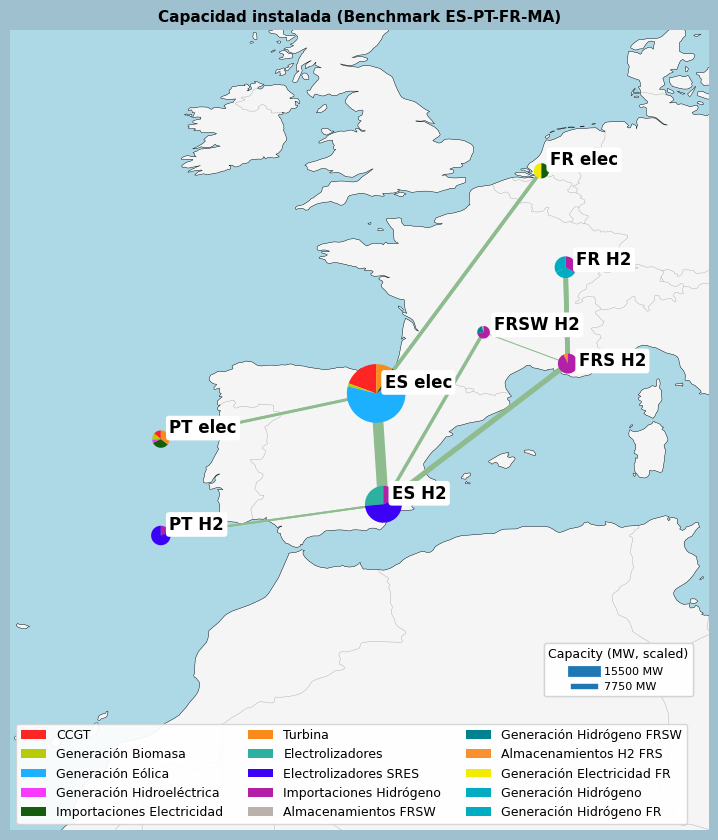

In [269]:
# ============================================================
# MAPA "CAPACIDAD INSTALADA" — BENCHMARK ES-PT-FR-MA
# VERSIÓN ACTUALIZADA
# - API robusta PyPSA (.static / .df / DataFrame)
# - FR con 3 nodos H2
# - MA con nodo H2
# - Añade:
#     * FRS_hydrogen_storage
#     * FRSW_hydrogen_storage
# - Quita storage_units del pie de capacidad
# - Evita clasificaciones erróneas en FRS/FRSW
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import cartopy.crs as ccrs

n = network

# -------------------------------------------------
# Helpers API robusta
# -------------------------------------------------
def get_static_df(component):
    if hasattr(component, "static"):
        return component.static.copy()
    if hasattr(component, "df"):
        return component.df.copy()
    return component.copy()

def set_xy_in_network(network, buses, xy_df):
    if hasattr(network.buses, "static"):
        network.buses.static.loc[buses, ["x", "y"]] = xy_df
    elif hasattr(network.buses, "df"):
        network.buses.df.loc[buses, ["x", "y"]] = xy_df
    else:
        network.buses.loc[buses, ["x", "y"]] = xy_df

buses_df = get_static_df(n.buses)
links_df = get_static_df(n.links) if hasattr(n, "links") else pd.DataFrame(columns=["bus0", "bus1"])
generators_df = get_static_df(n.generators) if hasattr(n, "generators") else pd.DataFrame()
carriers_df = get_static_df(n.carriers) if hasattr(n, "carriers") else pd.DataFrame()

# -------------------------------------------------
# 0) Ajustes visuales
# -------------------------------------------------
extent_system = (-17.5, 11.5, 24.3, 57.5)
bus_size_factor = 1.0e5
branch_width_factor = 2.0e3

# -------------------------------------------------
# 1) Buses objetivo
# -------------------------------------------------
b_e_es = "ES_electricity_market_bus"
b_h_es = "ES_hydrogen_bus"

b_e_pt = "PT_electricity_market_bus"
b_h_pt = "PT_hydrogen_bus"

b_e_fr = "FR_electricity_market_bus"

fr_h2_buses = [
    "FR_hydrogen_bus",
    "FRS_hydrogen_bus",
    "FRSW_hydrogen_bus",
]

b_h_ma = "MA_hydrogen_bus"

wanted_buses = [
    b_e_es, b_h_es,
    b_e_pt, b_h_pt,
    b_e_fr,
    *fr_h2_buses,
    b_h_ma,
]
wanted_buses = [b for b in wanted_buses if b in buses_df.index]
wanted_bus_set = set(wanted_buses)

print("Buses dibujados:", wanted_buses)

# -------------------------------------------------
# 2) Links a dibujar
# -------------------------------------------------
requested_links = [
    "ES_electrolyzer",
    "PT_electrolyzer",
    "FR_electrolyzer",
    "FR_electrolyzerSW",
    "ES_PT_interconexion_electricidad",
    "ES_PT_interconexion_hidrogeno",
    "PT_ES_interconexion_electricidad",
    "PT_ES_interconexion_hidrogeno",
    "ES_FR_interconexion_electricidad",
    "FR_ES_interconexion_electricidad",
    "ES_FR_interconexion_hidrogeno_IrunLarrau",
    "ES_FR_interconexion_hidrogeno_BarMar",
    "FR_FR_interconexion_hidrogeno_SWtoS",
    "FR_FR_interconexion_hidrogeno_StoSW",
    "FR_FR_interconexion_hidrogeno_StoFRh2",
    "FR_FR_interconexion_hidrogeno_FRh2toS",
    "MA_ES_interconexion_hidrogeno",
]

wanted_links = [l for l in requested_links if l in links_df.index]

if len(wanted_links):
    Lsel = links_df.loc[wanted_links, ["bus0", "bus1"]]
    wanted_links = [
        l for l in wanted_links
        if (Lsel.loc[l, "bus0"] in wanted_bus_set) and (Lsel.loc[l, "bus1"] in wanted_bus_set)
    ]

print("Links dibujados:", wanted_links)

# -------------------------------------------------
# 3) Reposicionar buses
# -------------------------------------------------
orig_xy = buses_df.loc[wanted_buses, ["x", "y"]].copy()

base = orig_xy.copy()
new_xy = base.copy()

def set_xy(bus, x, y):
    if bus in new_xy.index:
        new_xy.loc[bus, ["x", "y"]] = [x, y]

def get_xy(bus, default_x, default_y):
    if bus in base.index:
        return float(base.loc[bus, "x"]), float(base.loc[bus, "y"])
    return default_x, default_y

x_es, y_es = get_xy(b_e_es, -3.5, 40.0)
x_pt, y_pt = get_xy(b_e_pt, -8.0, 39.5)
x_fr, y_fr = get_xy(b_e_fr, 2.0, 46.0)
x_ma, y_ma = get_xy(b_h_ma, -6.0, 31.5)

set_xy(b_e_es, x_es + 1.4, y_es + 2.0)
set_xy(b_h_es, x_es + 1.7, y_es - 2.6)

set_xy(b_e_pt, x_pt - 2.1, y_pt + 1.8)
set_xy(b_h_pt, x_pt - 2.1, y_pt - 2.2)

set_xy(b_e_fr, x_fr + 2.2, y_fr + 2.8)
set_xy("FR_hydrogen_bus",   x_fr + 3.2, y_fr - 1.2)
set_xy("FRS_hydrogen_bus",  x_fr + 3.3, y_fr - 5.2)
set_xy("FRSW_hydrogen_bus", x_fr - 0.2, y_fr - 3.9)

set_xy(b_h_ma, x_ma - 0.6, y_ma - 2.4)

set_xy_in_network(n, wanted_buses, new_xy)

# -------------------------------------------------
# 4) Helpers de tecnologías
# -------------------------------------------------
def tech_from_generator(name, carrier, bus):
    nl = str(name).strip().lower()
    cl = str(carrier).strip().lower()
    bl = str(bus).strip().lower()

    if "load_shedding" in nl or "shedding" in nl or "load_shedding" in cl or "shedding" in cl:
        return None

    # -------- Generadores explícitos FR/FRS/FRSW --------
    if nl == "fr_electricity_generator":
        return "Generación Electricidad FR"

    if nl == "fr_hydrogen_generator_frh2":
        return "Generación Hidrógeno FR"

    if nl == "fr_hydrogen_generator_frsw":
        return "Generación Hidrógeno FRSW"

    if nl == "frs_hydrogen_storage":
        return "Almacenamientos H2 FRS"

    if nl == "frsw_hydrogen_storage":
        return "Almacenamientos FRSW"

    # -------- Marruecos --------
    if "h2highband" in nl or "h2highband" in cl or "high_band" in cl or "high band" in nl:
        return "Hydrogen High Band"

    if "h2lowband" in nl or "h2lowband" in cl or "low_band" in cl or "low band" in nl:
        return "Hydrogen Low Band"

    # -------- SRES --------
    if "sres" in nl and cl == "solar":
        return "Generación Solar SRES"
    if "sres" in nl and cl == "wind":
        return "Generación Eólica SRES"

    # -------- Renovables normales --------
    if cl == "solar":
        return "Generación Solar"
    if cl == "wind":
        return "Generación Eólica"

    # Bloqueo específico para que FRS/FRSW no hereden cosas raras
    if "frs_" in nl or "frsw_" in nl or bl.startswith("frs_") or bl.startswith("frsw_"):
        if cl == "hydrogen":
            return "Generación Hidrógeno"
        return None

    if cl in ("water", "hydro", "hydraulic"):
        return "Generación Hidroeléctrica"
    if cl == "biomass":
        return "Generación Biomasa"
    if cl == "nuclear":
        return "Generación Nuclear"
    if cl in ("gas", "ccgt"):
        return "CCGT"
    if cl == "hydrogen":
        return "Generación Hidrógeno"

    return None

def tech_from_link(name, bus0, bus1):
    nl = str(name).strip().lower()

    if "load_shedding" in nl or "shedding" in nl:
        return None
    if "interconexion" in nl and "electricidad" in nl:
        return "Importaciones Electricidad"
    if "interconexion" in nl and "hidrogeno" in nl:
        return "Importaciones Hidrógeno"
    if "ccgt" in nl:
        return "CCGT"
    if "turbina" in nl or "turbine" in nl:
        return "Turbina"

    if "sres" in nl and "exced" in nl:
        return "SRES_EXCEDENTES_SPLIT_ME"

    if "sres" in nl and "electrolyzer" in nl:
        return "Electrolizadores SRES"
    if "electrolyzer" in nl or "electrol" in nl:
        return "Electrolizadores"
    if "pump" in nl:
        return "Bomba/Pump"

    return None

def p_nom_like(df, name):
    if "p_nom_opt" in df.columns and pd.notna(df.loc[name, "p_nom_opt"]):
        return float(df.loc[name, "p_nom_opt"])
    return float(df.loc[name, "p_nom"])

# -------------------------------------------------
# 5) Construir PIES = CAPACIDAD INSTALADA (MW)
# -------------------------------------------------
rows = []

def add_cap(bus, tech, cap_mw):
    if bus not in wanted_bus_set:
        return
    if tech is None:
        return

    cap_mw = float(cap_mw)
    if cap_mw > 1e-6:
        rows.append((bus, tech, cap_mw))

def split_sres_excedentes_cap_to_solar_wind(n, link_name, cap_mw):
    links_static = get_static_df(n.links)
    gens_static = get_static_df(n.generators)

    if link_name not in links_static.index:
        return 0.0, 0.0

    sres_bus = links_static.loc[link_name, "bus0"]
    gens_sres = gens_static.index[gens_static["bus"] == sres_bus]

    if len(gens_sres) == 0:
        return 0.0, 0.0

    carriers = gens_static.loc[gens_sres, "carrier"].astype(str).str.lower()
    gens_solar = list(gens_sres[carriers == "solar"])
    gens_wind = list(gens_sres[carriers == "wind"])

    solar_cap = sum(p_nom_like(gens_static, g) for g in gens_solar) if len(gens_solar) else 0.0
    wind_cap = sum(p_nom_like(gens_static, g) for g in gens_wind) if len(gens_wind) else 0.0

    total = solar_cap + wind_cap
    if total <= 0:
        return 0.0, 0.0

    return cap_mw * (solar_cap / total), cap_mw * (wind_cap / total)

electric_buses = [b for b in [b_e_es, b_e_pt, b_e_fr] if b in wanted_bus_set]
hydrogen_buses = [b for b in [b_h_es, b_h_pt, *fr_h2_buses, b_h_ma] if b in wanted_bus_set]

# -----------------------------
# 5A) Generadores
# -----------------------------
if len(generators_df):
    Gsel = generators_df[generators_df["bus"].isin(electric_buses + hydrogen_buses)]

    for name, r in Gsel.iterrows():
        tech = tech_from_generator(name, r["carrier"], r["bus"])
        cap = p_nom_like(generators_df, name)
        add_cap(r["bus"], tech, cap)

# -----------------------------
# 5B) NO contar StorageUnits
# -----------------------------
# Eliminado a propósito. Ya no quieres que el storage aparezca
# como capacidad instalada en el pie del mapa.

# -----------------------------
# 5C) Links hacia electricidad
# -----------------------------
if len(links_df):
    L_e = links_df[links_df["bus1"].isin(electric_buses)]

    for name, r in L_e.iterrows():
        tech = tech_from_link(name, r["bus0"], r["bus1"])
        cap = p_nom_like(links_df, name)

        if tech == "SRES_EXCEDENTES_SPLIT_ME":
            cap_solar, cap_wind = split_sres_excedentes_cap_to_solar_wind(n, name, cap)
            add_cap(r["bus1"], "Generación Solar SRES", cap_solar)
            add_cap(r["bus1"], "Generación Eólica SRES", cap_wind)
        else:
            add_cap(r["bus1"], tech, cap)

# -----------------------------
# 5D) Links hacia H2
# -----------------------------
if len(links_df):
    L_h2 = links_df[links_df["bus1"].isin(hydrogen_buses)]

    for name, r in L_h2.iterrows():
        tech = tech_from_link(name, r["bus0"], r["bus1"])
        pnom = p_nom_like(links_df, name)

        eff = (
            float(links_df.loc[name, "efficiency"])
            if "efficiency" in links_df.columns and pd.notna(links_df.loc[name, "efficiency"])
            else 1.0
        )

        cap = pnom * eff if tech in ["Electrolizadores", "Electrolizadores SRES"] else pnom
        add_cap(r["bus1"], tech, cap)

# -----------------------------
# 5E) Serie final
# -----------------------------
if len(rows):
    eb = pd.Series(
        data=[r[2] for r in rows],
        index=pd.MultiIndex.from_tuples([(r[0], r[1]) for r in rows], names=["bus", "tech"])
    ).groupby(["bus", "tech"]).sum()

    eb_plot = eb.copy()
    eb_plot.index = eb_plot.index.set_names(["bus", "carrier"])
else:
    eb_plot = pd.Series(dtype=float)

print("\nCapacidad agregada por bus y tecnología:")
print(eb_plot.sort_index() if len(eb_plot) else "Vacío")

# -------------------------------------------------
# 6) Colores
# -------------------------------------------------
techs = list(eb_plot.index.get_level_values("carrier").unique()) if len(eb_plot) else []

tech_color = {}
for t in techs:
    tl = str(t).lower()

    if tl == "electrolizadores":
        tech_color[t] = "#2CB1A1"
    elif tl == "electrolizadores sres":
        tech_color[t] = "#3B02F5"
    elif tl == "importaciones hidrógeno":
        tech_color[t] = "#B41FA8"
    elif tl == "hydrogen high band":
        tech_color[t] = "#1565C0"
    elif tl == "hydrogen low band":
        tech_color[t] = "#4FC3F7"
    elif tl == "generación eólica":
        tech_color[t] = "#1CB0FF"
    elif tl == "generación solar":
        tech_color[t] = "#FAE739"
    elif tl == "generación hidroeléctrica":
        tech_color[t] = "#F839FF"
    elif tl == "generación biomasa":
        tech_color[t] = "#B7CB07"
    elif tl == "generación nuclear":
        tech_color[t] = "#9C6ADE"
    elif tl == "ccgt" or "gas" in tl:
        tech_color[t] = "#FF2525"
    elif tl == "turbina":
        tech_color[t] = "#F98A1B"
    elif tl == "importaciones electricidad":
        tech_color[t] = "#145D0C"
    elif tl == "generación solar sres":
        tech_color[t] = "#FDBE00"
    elif tl == "generación eólica sres":
        tech_color[t] = "#6EE2FF"
    elif tl == "bomba/pump":
        tech_color[t] = "#8BC34A"
    elif tl == "generación hidrógeno":
        tech_color[t] = "#00ACC1"
    elif tl == "generación electricidad fr":
        tech_color[t] = "#F4EC00"
    elif tl == "generación hidrógeno fr":
        tech_color[t] = "#00ACC1"
    elif tl == "generación hidrógeno frs":
        tech_color[t] = "#26C6DA"
    elif tl == "generación hidrógeno frsw":
        tech_color[t] = "#00838F"
    elif tl == "almacenamientos h2 frs":
        tech_color[t] = "#F98F2D"
    elif tl == "almacenamientos h2 frsw":
        tech_color[t] = "#F98F2D" 
    else:
        tech_color[t] = "#BAB0AC"



if hasattr(n, "carriers"):
    current_carriers = get_static_df(n.carriers)

    if "color" not in current_carriers.columns:
        if hasattr(n.carriers, "static"):
            n.carriers.static["color"] = pd.NA
        elif hasattr(n.carriers, "df"):
            n.carriers.df["color"] = pd.NA
        else:
            n.carriers["color"] = pd.NA

    current_carriers = get_static_df(n.carriers)
    current_carriers["color"] = current_carriers["color"].replace("", pd.NA)

    for t in techs:
        if t not in current_carriers.index:
            n.add("Carrier", t)

    current_carriers = get_static_df(n.carriers)
    for t in techs:
        current_carriers.loc[t, "color"] = tech_color[t]

    if hasattr(n.carriers, "static"):
        n.carriers.static.loc[current_carriers.index, "color"] = current_carriers["color"]
    elif hasattr(n.carriers, "df"):
        n.carriers.df.loc[current_carriers.index, "color"] = current_carriers["color"]
    else:
        n.carriers.loc[current_carriers.index, "color"] = current_carriers["color"]

# -------------------------------------------------
# 7) Link widths = capacidad instalada
# -------------------------------------------------
link_cap = pd.Series(dtype=float)
if len(wanted_links):
    if "p_nom_opt" in links_df.columns:
        link_cap = links_df.loc[wanted_links, "p_nom_opt"].fillna(
            links_df.loc[wanted_links, "p_nom"]
        ).astype(float)
    else:
        link_cap = links_df.loc[wanted_links, "p_nom"].astype(float)

# -------------------------------------------------
# 8) Plot
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.PlateCarree()})

ax.set_position([0, 0, 1, 1])
fig.patch.set_facecolor("#9ec0cf")

plot_kwargs = dict(
    ax=ax,
    geomap_color=True,
)

if len(eb_plot):
    plot_kwargs["bus_sizes"] = eb_plot / bus_size_factor

if len(link_cap):
    plot_kwargs["link_widths"] = link_cap / branch_width_factor
else:
    plot_kwargs["link_widths"] = pd.Series(0.0, index=links_df.index)

n.plot(**plot_kwargs)

ax.set_extent(extent_system, crs=ccrs.PlateCarree())
ax.set_title(
    "Capacidad instalada (Benchmark ES-PT-FR-MA)",
    fontweight="bold",
    fontsize=11
)

# -------------------------------------------------
# 9) Etiquetas buses
# -------------------------------------------------
label_map = {
    b_e_es: "ES elec",
    b_h_es: "ES H2",
    b_e_pt: "PT elec",
    b_h_pt: "PT H2",
    b_e_fr: "FR elec",
    "FR_hydrogen_bus": "FR H2",
    "FRS_hydrogen_bus": "FRS H2",
    "FRSW_hydrogen_bus": "FRSW H2",
    b_h_ma: "MA H2",
}

label_offsets = {
    b_e_es: (0.35, 0.25),
    b_h_es: (0.35, 0.25),
    b_e_pt: (0.35, 0.25),
    b_h_pt: (0.35, 0.25),
    b_e_fr: (0.35, 0.25),
    "FR_hydrogen_bus": (0.45, 0.10),
    "FRS_hydrogen_bus": (0.45, -0.10),
    "FRSW_hydrogen_bus": (0.45, 0.10),
    b_h_ma: (0.30, 0.20),
}

current_buses_df = get_static_df(n.buses)

for b in wanted_buses:
    x, y = current_buses_df.loc[b, ["x", "y"]]
    dx_lab, dy_lab = label_offsets.get(b, (0.20, 0.15))
    ax.text(
        x + dx_lab,
        y + dy_lab,
        label_map.get(b, b),
        transform=ccrs.PlateCarree(),
        fontsize=12,
        fontweight="bold",
        zorder=10,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=1),
    )

# -------------------------------------------------
# 10) Leyendas
# -------------------------------------------------
if len(techs):
    handles_patches = [
        mpatches.Patch(facecolor=tech_color[t], edgecolor="none", label=str(t))
        for t in techs
    ]
    leg_tech = ax.legend(
        handles=handles_patches,
        loc="lower left",
        bbox_to_anchor=(0.0, 0.000),
        bbox_transform=ax.transAxes,
        ncol=3,
        frameon=True,
        fontsize=9,
        facecolor="white",
        edgecolor="lightgray",
        framealpha=0.92
    )
    ax.add_artist(leg_tech)

if len(link_cap):
    maxc = float(link_cap.max())
    if maxc > 0:
        handles_lines = [
            mlines.Line2D([0], [0], color="#1f77b4", lw=maxc / branch_width_factor),
            mlines.Line2D([0], [0], color="#1f77b4", lw=(0.5 * maxc) / branch_width_factor),
        ]
        labels_lines = [f"{maxc:.0f} MW", f"{0.5 * maxc:.0f} MW"]

        leg_cap = ax.legend(
            handles=handles_lines,
            labels=labels_lines,
            loc="lower right",
            bbox_to_anchor=(0.985, 0.16),
            bbox_transform=ax.transAxes,
            frameon=True,
            facecolor="white",
            edgecolor="lightgray",
            framealpha=0.92,
            title="Capacity (MW, scaled)",
            fontsize=8,
            title_fontsize=9
        )
        ax.add_artist(leg_cap)

# -------------------------------------------------
# 11) Final
# -------------------------------------------------
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()

# -------------------------------------------------
# 12) Restaurar coords
# -------------------------------------------------
set_xy_in_network(n, wanted_buses, orig_xy)

Gráfica Generación Eléctrica

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\1878655617.py:18: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\1878655617.py:19: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\1878655617.py:34: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\1878655617.py:37: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.



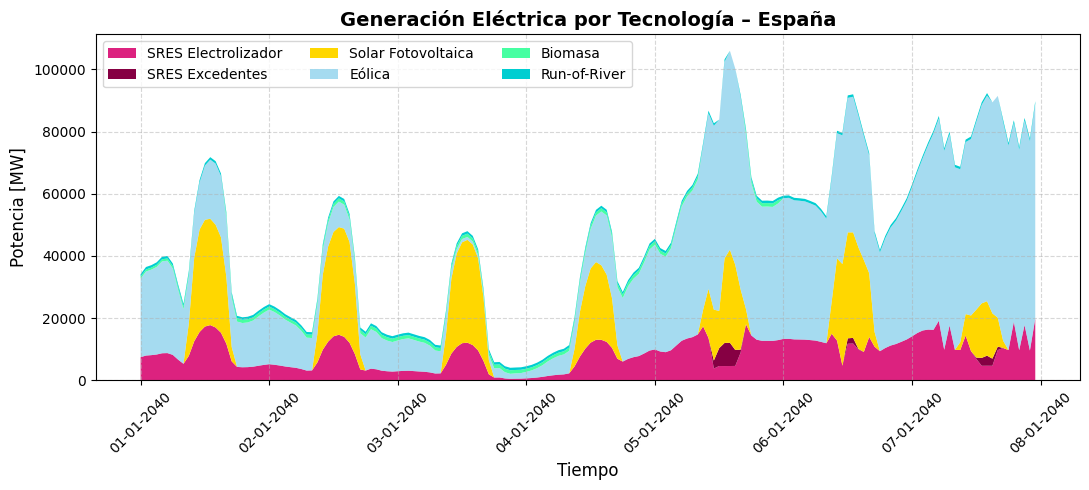

In [270]:
# ============================================================
# GENERACIÓN ELÉCTRICA EN ESPAÑA (MW) — FORMATO "FOTO 2"
#  - Stackplot por tecnología (no por generador individual)
#  - Solo activos conectados a buses ES_ (o nombre ES_)
#  - Sin load shedding
# ============================================================

def plot_generacion_es_formato_foto2(network, start="2025-01-01", end="2025-01-07 23:00"):
    n = network

    # --- snapshots / rango ---
    hours = pd.date_range(start=start, end=end, freq="h")
    # si tus snapshots ya son exactamente ese rango, esto igual te da igual
    times = hours

    # --- DF de generadores y buses (compatibilidad) ---
    try:
        gen_df = n.components["Generator"].df
        buses_df = n.components["Bus"].df
    except Exception:
        gen_df = n.generators if hasattr(n, "generators") else n.generators.df
        buses_df = n.buses if hasattr(n, "buses") else n.buses.df

    # --- Buses ES_ ---
    es_buses = set(buses_df.index.to_series().astype(str)[buses_df.index.to_series().astype(str).str.startswith("ES_")])

    # --- Generadores en buses ES_ (fallback por nombre ES_) ---
    if "bus" in gen_df.columns:
        gens_es = list(gen_df.index[gen_df["bus"].isin(es_buses)])
    else:
        gens_es = list(gen_df.index[gen_df.index.to_series().astype(str).str.startswith("ES_")])

    # --- Generación temporal ---
    if not hasattr(n, "generators_t") or not hasattr(n.generators_t, "p"):
        raise ValueError("No existe network.generators_t.p (¿has corrido el modelo?).")

    p = n.generators_t.p

    # solo columnas disponibles
    gens_es = [g for g in gens_es if g in p.columns]
    if len(gens_es) == 0:
        print("No se encontraron generadores ES_* en network.generators_t.p")
        return

    # --- Clasificación por tecnología (ajusta aquí si tus nombres difieren) ---
    def tech_from_gen_name(gname, carrier=None):
        s = str(gname).lower()
        c = str(carrier).lower() if carrier is not None else ""

        # quitar load shedding
        if "load_shedding" in s or "shedding" in s or "load shedding" in c:
            return None

        # normal
        if "es_sres_excedentes" in s: return "SRES Excedentes"
        if "es_sres_electrolyzer" in s: return "SRES Electrolizador"
        if "solar_pv" in s or "solar" in c: return "Solar Fotovoltaica"
        if "solar_csp" in s: return "Solar Térmica CSP"
        if "solar_rooftop" in s or "solar_rooftop" in c: return "Solar PV Rooftop"
        if "wind"  in s or "eolic" in s or "wind" in c: return "Eólica"
        if "biomass" in s or "biomasa" in s or "biomass" in c: return "Biomasa"
        if "water" in s or "hydro" in s or "river" in s or "water" in c or "hydro" in c:
            return "Run-of-River"
 
        return None

    # --- Construir series agregadas (MW) ---
    series = {}
    for g in gens_es:
        carrier = gen_df.loc[g, "carrier"] if "carrier" in gen_df.columns and g in gen_df.index else None
        tech = tech_from_gen_name(g, carrier)
        if tech is None:
            continue
        series.setdefault(tech, 0.0)
        series[tech] = series[tech] + p[g].reindex(times).fillna(0.0)

    if len(series) == 0:
        print("Tras filtrar load shedding, no queda nada que pintar.")
        return

    # --- Orden de tecnologías (estilo foto 2: pocas y claras) ---
    preferred_order = [
        "SRES Electrolizador","SRES Excedentes", "Solar Fotovoltaica", "Solar Térmica CSP", "Solar PV Rooftop", "Eólica", "SRES Wind", "Biomasa", "Run-of-River"
    ]
    techs = [t for t in preferred_order if t in series] + [t for t in series if t not in preferred_order]

    df_plot = pd.DataFrame({t: series[t] for t in techs}, index=times)

    # --- Colores (como tu foto 2 / tu paleta) ---
    colors = {
        "Solar Fotovoltaica": "#FFD700",
        "Solar Térmica CSP": "#FFA500",
        "Solar PV Rooftop": "#FF8C00",
        "Eólica": "#87CFEBBE",
        "Biomasa": "#46FFA2",
        "Run-of-River": "#00CED1",
        "Turbina": "#8B4513",  # marrón
        "SRES Electrolizador": "#DC227F",
        "SRES Excedentes": "#860043",  # verde
          # verde
    }
    color_list = [colors.get(t, "#BAB0AC") for t in techs]

    # ============================================================
    # PLOT (stackplot tipo foto 2)
    # ============================================================
    plt.figure(figsize=(11,5))

    plt.stackplot(
        df_plot.index,
        [df_plot[t].values for t in techs],
        labels=techs,
        colors=color_list,
        linewidth=0.0
    )

    plt.title("Generación Eléctrica por Tecnología – España", fontsize=14, fontweight="bold")
    plt.xlabel("Tiempo", fontsize=12)
    plt.ylabel("Potencia [MW]", fontsize=12)

    plt.xticks(rotation=45)
    plt.grid(True, linestyle="--", alpha=0.5)

    # Leyenda compacta como foto 2
    plt.legend(loc="upper left", fontsize=10, ncol=3)

    # Formato eje X como foto 2 (día-mes)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%m-2040"))
    
    plt.tight_layout()
    plt.show()


# Ejecuta:
plot_generacion_es_formato_foto2(network, start="2025-01-01", end="2025-01-07 23:00")

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\28780374.py:21: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\28780374.py:22: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\28780374.py:41: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\28780374.py:44: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.



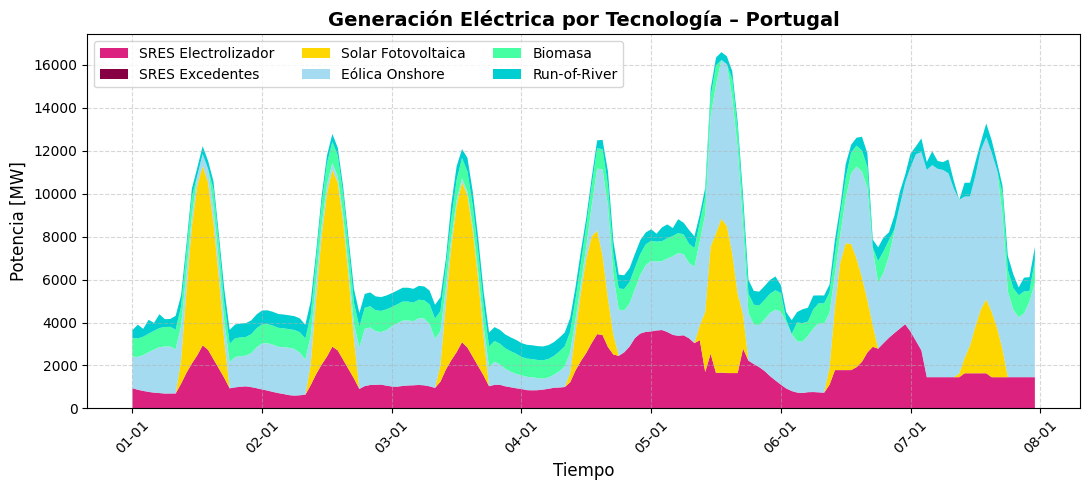

In [271]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ============================================================
# GENERACIÓN ELÉCTRICA EN PORTUGAL (MW) — FORMATO "FOTO 2"
#  - Stackplot por tecnología (no por generador individual)
#  - Solo activos conectados a buses PT_ (o nombre PT_)
#  - Sin load shedding
# ============================================================

def plot_generacion_pt_formato_foto2(network, start="2025-01-01", end="2025-01-07 23:00"):
    n = network

    # --- rango temporal ---
    times = pd.date_range(start=start, end=end, freq="h")

    # --- DF de generadores y buses (compatibilidad) ---
    try:
        gen_df = n.components["Generator"].df
        buses_df = n.components["Bus"].df
    except Exception:
        gen_df = n.generators if hasattr(n, "generators") else n.generators.df
        buses_df = n.buses if hasattr(n, "buses") else n.buses.df

    # --- Buses PT_ ---
    pt_buses = set(
        buses_df.index.to_series().astype(str)[
            buses_df.index.to_series().astype(str).str.startswith("PT_")
        ]
    )

    # --- Generadores en buses PT_ (fallback por nombre PT_) ---
    if "bus" in gen_df.columns:
        gens_pt = list(gen_df.index[gen_df["bus"].isin(pt_buses)])
    else:
        gens_pt = list(gen_df.index[gen_df.index.to_series().astype(str).str.startswith("PT_")])

    # --- Generación temporal ---
    if not hasattr(n, "generators_t") or not hasattr(n.generators_t, "p"):
        raise ValueError("No existe network.generators_t.p (¿has corrido el modelo?).")

    p = n.generators_t.p

    # solo columnas disponibles
    gens_pt = [g for g in gens_pt if g in p.columns]
    if len(gens_pt) == 0:
        print("No se encontraron generadores PT_* en network.generators_t.p")
        return

    # --- Clasificación por tecnología ---
    def tech_from_gen_name(gname, carrier=None):
        s = str(gname).lower()
        c = str(carrier).lower() if carrier is not None else ""

        # quitar load shedding
        if "load_shedding" in s or "shedding" in s or "load shedding" in c:
            return None

     

        # normal
        if "pt_sres_excedentes" in s: return "SRES Excedentes"
        if "pt_sres_electrolyzer" in s: return "SRES Electrolizador"
        if "solar_pv" in s or "solar" in c: return "Solar Fotovoltaica"
        if "solar_rooftop" in s or "solar_rooftop" in c: return "Solar PV Rooftop"
        if "wind_onshore" in s or "eolic" in s or "wind" in c: return "Eólica Onshore"
        if "wind_offshore" in s or "eolic" in s or "wind" in c: return "Eólica Offshore"
        if "biomass" in s or "biomasa" in s or "biomass" in c: return "Biomasa"
        if "water" in s or "hydro" in s or "river" in s or "water" in c or "hydro" in c:
            return "Run-of-River"
        return None

    # --- Construir series agregadas (MW) ---
    series = {}
    for g in gens_pt:
        carrier = gen_df.loc[g, "carrier"] if ("carrier" in gen_df.columns and g in gen_df.index) else None
        tech = tech_from_gen_name(g, carrier)
        if tech is None:
            continue
        series.setdefault(tech, 0.0)
        series[tech] = series[tech] + p[g].reindex(times).fillna(0.0)

    if len(series) == 0:
        print("Tras filtrar load shedding, no queda nada que pintar.")
        return

    # --- Orden de tecnologías ---
    preferred_order = [
        "SRES Electrolizador","SRES Excedentes", "Solar Fotovoltaica", "Solar PV Rooftop", "Eólica Onshore", "Eólica Offshore", "Biomasa", "Run-of-River"
    ]
    techs = [t for t in preferred_order if t in series] + [t for t in series if t not in preferred_order]

    df_plot = pd.DataFrame({t: series[t] for t in techs}, index=times)

    # --- Colores (misma lógica que España; ajusta si quieres) ---
    colors = {
        "Solar Fotovoltaica": "#FFD700",
        "Solar PV Rooftop": "#FF8C00",
        "Eólica Onshore": "#87CFEBBE",
        "Eólica Offshore": "#87CFEBDC",
        "Biomasa": "#46FFA2",
        "Run-of-River": "#00CED1",    
        "SRES Electrolizador": "#DC227F",
        "SRES Excedentes": "#860043",  # verde
        
    }
    color_list = [colors.get(t, "#BAB0AC") for t in techs]

    # --- Plot (stackplot tipo foto 2) ---
    plt.figure(figsize=(11,5))
    plt.stackplot(
        df_plot.index,
        [df_plot[t].values for t in techs],
        labels=techs,
        colors=color_list,
        linewidth=0.0
    )

    plt.title("Generación Eléctrica por Tecnología – Portugal", fontsize=14, fontweight="bold")
    plt.xlabel("Tiempo", fontsize=12) 
    plt.ylabel("Potencia [MW]", fontsize=12)

    plt.xticks(rotation=45)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(loc="upper left", fontsize=10, ncol=3)

    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%m"))
    plt.tight_layout()
    plt.show()


# Ejecuta:
plot_generacion_pt_formato_foto2(network, start="2025-01-01", end="2025-01-07 23:00")

Generador encontrado: FR_electricity_generator
Primeras filas:
snapshot
2025-01-01 00:00:00    5000.000000
2025-01-01 01:00:00    5000.000000
2025-01-01 02:00:00    4348.928857
2025-01-01 03:00:00    3919.745505
2025-01-01 04:00:00    3345.017000
Freq: h, Name: FR_electricity_generator, dtype: float64
Máximo: 5000.0
Suma: 335269.5871879978


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\2554029871.py:9: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\2554029871.py:12: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\2554029871.py:15: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.



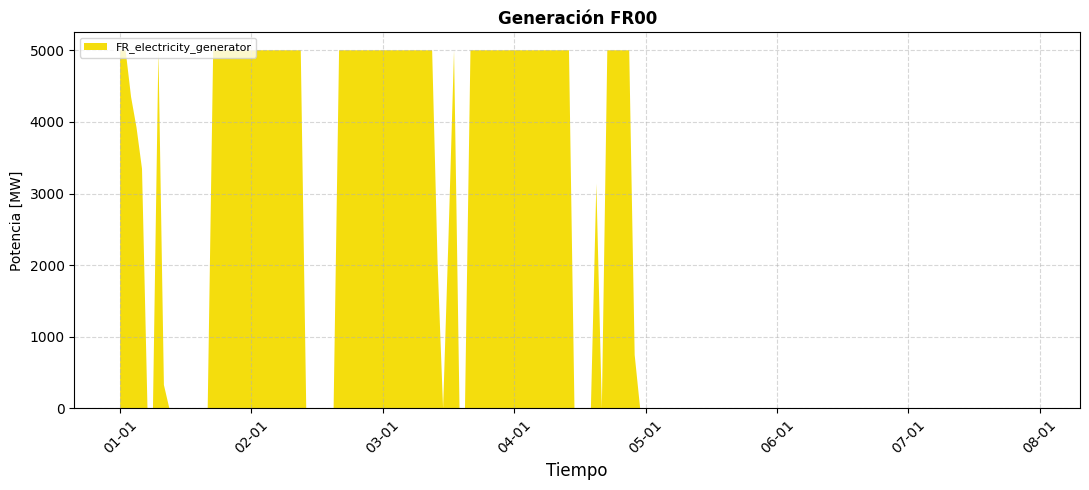

In [272]:
# ============================================================
# GENERACIÓN FR00 — SOLO FR_electricity_generator
# ============================================================

def plot_fr00_solo_generador(network, start="2025-01-01", end="2025-01-07 23:00"):
    n = network
    gen_name = "FR_electricity_generator"

    if not hasattr(n, "generators_t") or not hasattr(n.generators_t, "p"):
        raise ValueError("No existe network.generators_t.p (¿has corrido la optimización?).")

    if gen_name not in n.generators_t.p.columns:
        raise ValueError(f"No existe '{gen_name}' en network.generators_t.p.columns")

    s = n.generators_t.p[gen_name].copy()
    s = s.loc[(s.index >= pd.Timestamp(start)) & (s.index <= pd.Timestamp(end))]
    s = s.fillna(0.0).clip(lower=0.0)

    print("Generador encontrado:", gen_name)
    print("Primeras filas:")
    print(s.head())
    print("Máximo:", s.max())
    print("Suma:", s.sum())

    if s.empty:
        print("La serie está vacía en ese rango temporal.")
        return

    if s.sum() <= 1e-6:
        print("La serie existe, pero toda la generación es cero en ese rango.")
        return

    plt.figure(figsize=(11, 5))

    plt.stackplot(
        s.index,
        s.values,
        labels=[gen_name],
        colors=["#F4DC00"],
        alpha=0.95
    )

    plt.title("Generación FR00", fontsize=12, fontweight="bold")
    plt.xlabel("Tiempo", fontsize=12)
    plt.ylabel("Potencia [MW]", fontsize=10)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(loc="upper left", fontsize=8)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%m"))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Ejecuta:
plot_fr00_solo_generador(network, start="2025-01-01", end="2025-01-07 23:00")

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\601005083.py:1: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.



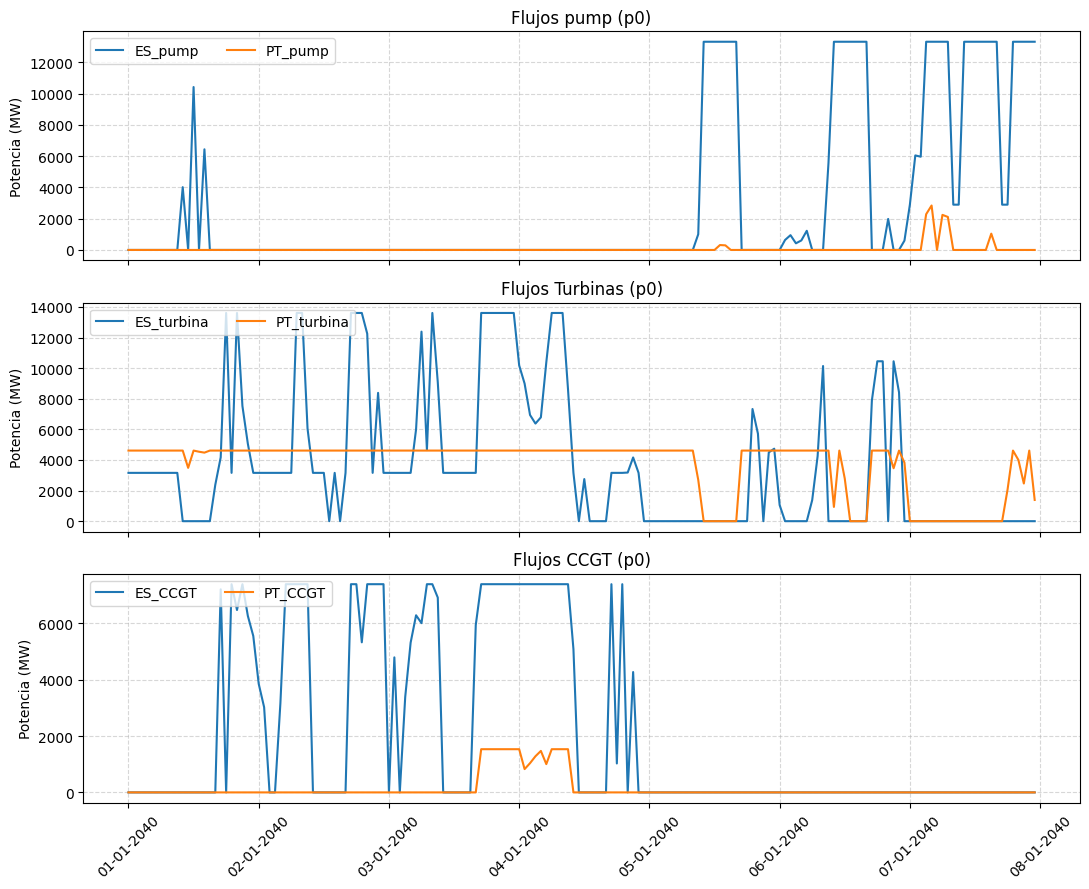

In [273]:
p0 = network.links_t.p0

links_pump = [
    "ES_pump",
    "PT_pump",
    
    ]

links_turbina = [
    "ES_turbina",
    "PT_turbina",
    

]

links_CCGT = [
    "ES_CCGT",
    "PT_CCGT",
    
    ] 


fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

# --- GRAFICO ESPAÑA ---
labels_es = []
for link in links_pump:
    if link in p0.columns:
        axes[0].plot(network.snapshots, p0[link], label=link)
        labels_es.append(link)

axes[0].set_title("Flujos pump (p0)")
axes[0].set_ylabel("Potencia (MW)")
axes[0].grid(True, linestyle="--", alpha=0.5)
if labels_es:
    axes[0].legend(loc="upper left", ncol=3)

# --- GRAFICO PORTUGAL ---
labels_pt = []
for link in links_turbina:
    if link in p0.columns:
        axes[1].plot(network.snapshots, p0[link], label=link)
        labels_pt.append(link)

axes[1].set_title("Flujos Turbinas (p0)")
axes[1].set_ylabel("Potencia (MW)")
axes[1].grid(True, linestyle="--", alpha=0.5)
if labels_pt:
    axes[1].legend(loc="upper left", ncol=3)

# --- GRAFICO CCGT ---
labels_ccgt = []
for link in links_CCGT:
    if link in p0.columns:
        axes[2].plot(network.snapshots, p0[link], label=link)
        labels_ccgt.append(link)

axes[2].set_title("Flujos CCGT (p0)")
axes[2].set_ylabel("Potencia (MW)")
axes[2].grid(True, linestyle="--", alpha=0.5)
if labels_ccgt:
    axes[2].legend(loc="upper left", ncol=3)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-2040'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\2822313421.py:4: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.



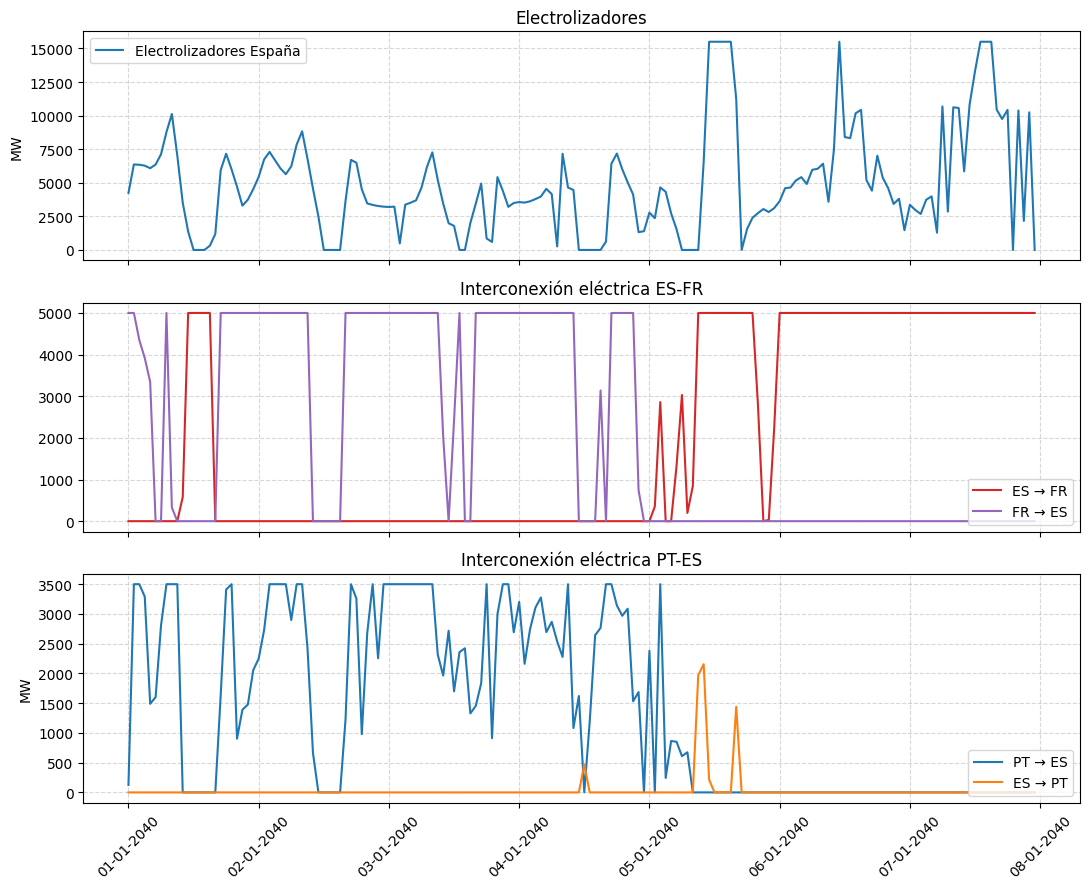

In [274]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

p0 = network.links_t.p0

# 👉 4 subplots (2x2)
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
axes = axes.flatten()

# Colores
colors_electro = ["#1f77b4", "#ff7f0e", "#2ECC71"]
colors_inter = ["#d62728", "#9467bd"]

# =========================================================
# 🔵 1. ELECTROLIZADORES
# =========================================================
links_electro = [
    "ES_electrolyzer",
    "FR_electrolyzer",
    "FR_electrolyzerSW"
]

labels_map_electro = {
    "ES_electrolyzer": "Electrolizadores España",
    "FR_electrolyzer": "Electrolizadores FR",
    "FR_electrolyzerSW": "Electrolizadores Francia (SW)"
}

for i, link in enumerate(links_electro):
    if link in p0.columns:
        axes[0].plot(
            network.snapshots,
            p0[link],
            label=labels_map_electro[link],
            color=colors_electro[i]
        )

axes[0].set_title("Electrolizadores")
axes[0].set_ylabel("MW")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend(loc="upper left",  ncol=3)

# =========================================================
# 🔴 2. INTERCONEXIÓN ES-FR
# =========================================================
links_inter = [
    "ES_FR_interconexion_electricidad",
    "FR_ES_interconexion_electricidad",
]

labels_map_inter = {
    "ES_FR_interconexion_electricidad": "ES → FR",
    "FR_ES_interconexion_electricidad": "FR → ES"
}

for i, link in enumerate(links_inter):
    if link in p0.columns:
        axes[1].plot(
            network.snapshots,
            p0[link],
            label=labels_map_inter[link],
            color=colors_inter[i]
        )

axes[1].set_title("Interconexión eléctrica ES-FR")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend(loc="lower right")

# 👉 FORMATO SOLO EN ESTE SUBPLOT (como pediste)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-2040'))

# =========================================================
# 🟢 3. INTERCONEXIÓN PT-ES
# =========================================================
links_pt = [
    "PT_ES_interconexion_electricidad",
    "ES_PT_interconexion_electricidad",
]

labels_map_portugal = {
    "PT_ES_interconexion_electricidad": "PT → ES",
    "ES_PT_interconexion_electricidad": "ES → PT",
}

for i, link in enumerate(links_pt):
    if link in p0.columns:
        axes[2].plot(
            network.snapshots,
            p0[link],
            label=labels_map_portugal[link],
            color=colors_electro[i % len(colors_electro)]
        )

axes[2].set_title("Interconexión eléctrica PT-ES")
axes[2].set_ylabel("MW")
axes[2].grid(True, linestyle="--", alpha=0.5)
axes[2].legend(loc="lower right")



# =========================================================
# FORMATO GLOBAL
# =========================================================
for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\671287203.py:26: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\671287203.py:29: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\671287203.py:39: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\671287203.py:46: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.li

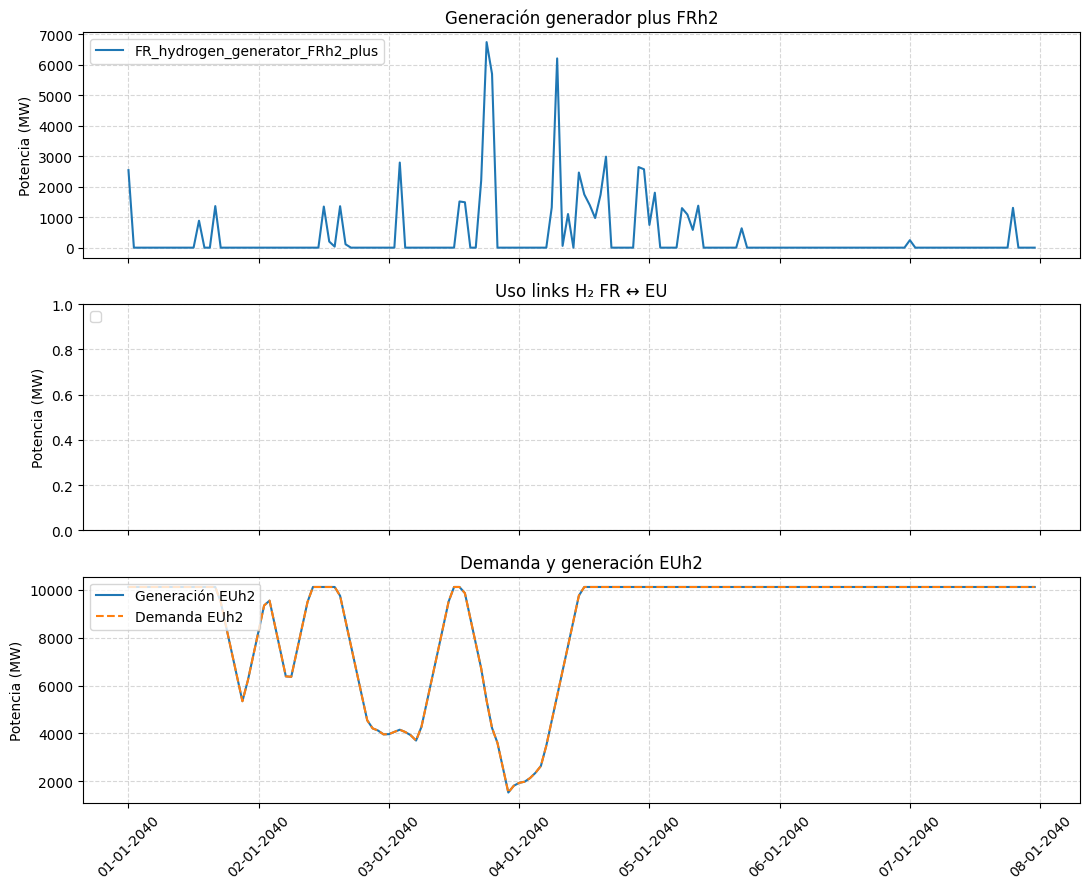

In [275]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# =========================================================
# SERIES
# =========================================================
times = network.snapshots

# Generador plus FRh2
gen_plus_name = "FR_hydrogen_generator_FRh2_plus"

# Links FR <-> EU
link_fr_to_eu = "FR_EU_interconexion_hidrogeno"
link_eu_to_fr = "EU_FR_interconexion_hidrogeno"

# Generador y demanda EUh2
gen_eu_name = "EU_hydrogen_generator"
load_eu_name = "EU_hydrogen_demand"

# =========================================================
# PLOT
# =========================================================
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

# --- 1) GENERACIÓN PLUS FRh2 ---
if gen_plus_name in network.generators_t.p.columns:
    axes[0].plot(
        times,
        network.generators_t.p[gen_plus_name],
        label=gen_plus_name
    )

axes[0].set_title("Generación generador plus FRh2")
axes[0].set_ylabel("Potencia (MW)")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend(loc="upper left")

# --- 2) LINKS FR <-> EU ---
if link_fr_to_eu in network.links_t.p0.columns:
    axes[1].plot(
        times,
        network.links_t.p0[link_fr_to_eu],
        label=f"{link_fr_to_eu} p0"
    )

if link_eu_to_fr in network.links_t.p0.columns:
    axes[1].plot(
        times,
        network.links_t.p0[link_eu_to_fr],
        label=f"{link_eu_to_fr} p0"
    )

axes[1].set_title("Uso links H₂ FR ↔ EU")
axes[1].set_ylabel("Potencia (MW)")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend(loc="upper left")

# --- 3) DEMANDA Y GENERACIÓN EUh2 ---
if gen_eu_name in network.generators_t.p.columns:
    axes[2].plot(
        times,
        network.generators_t.p[gen_eu_name],
        label="Generación EUh2"
    )

if load_eu_name in network.loads_t.p_set.columns:
    axes[2].plot(
        times,
        network.loads_t.p_set[load_eu_name],
        label="Demanda EUh2",
        linestyle="--"
    )

axes[2].set_title("Demanda y generación EUh2")
axes[2].set_ylabel("Potencia (MW)")
axes[2].grid(True, linestyle="--", alpha=0.5)
axes[2].legend(loc="upper left")

# Formato eje X
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%m-2040"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\3978445609.py:4: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\3978445609.py:117: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



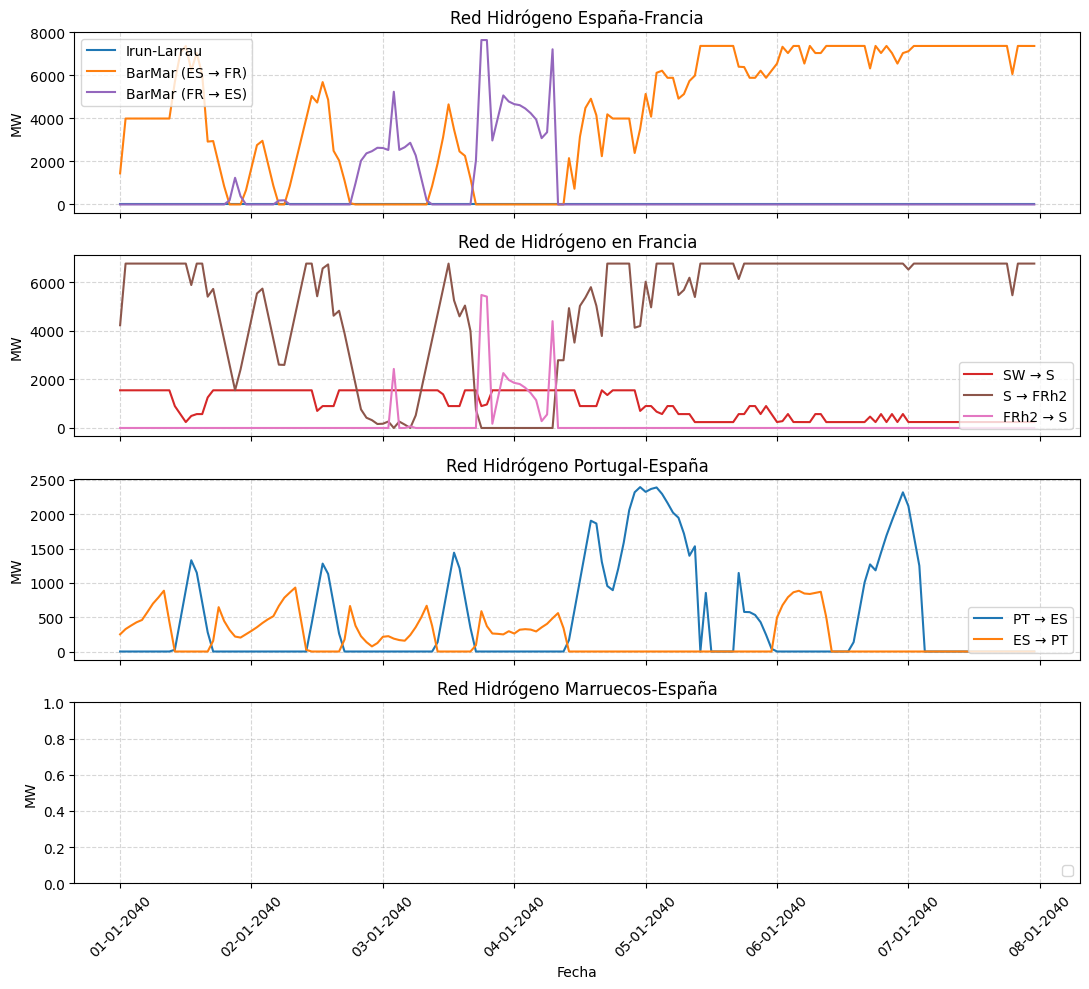

In [276]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

p0 = network.links_t.p0

# 👉 4 subplots en vertical
fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=True)

# Colores
colors_electro = ["#1f77b4", "#ff7f0e", "#9467bd"]
colors_inter = ["#d62728", "#9467bd", "#8c564b", "#e377c2"]

# =========================================================
# 🔵 1. ES-FR HIDRÓGENO
# =========================================================
links_es_fr = [
    "ES_FR_interconexion_hidrogeno_IrunLarrau",
    "ES_FR_interconexion_hidrogeno_BarMar",
    "FR_ES_interconexion_hidrogeno_BarMar",
]

labels_es_fr = {
    "ES_FR_interconexion_hidrogeno_IrunLarrau": "Irun-Larrau",
    "ES_FR_interconexion_hidrogeno_BarMar": "BarMar (ES → FR)",
    "FR_ES_interconexion_hidrogeno_BarMar": "BarMar (FR → ES)",
}

for i, link in enumerate(links_es_fr):
    if link in p0.columns:
        axes[0].plot(
            network.snapshots,
            p0[link],
            label=labels_es_fr[link],
            color=colors_electro[i]
        )

axes[0].set_title("Red Hidrógeno España-Francia")
axes[0].set_ylabel("MW")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend(loc="upper left")

# =========================================================
# 🔴 2. RED INTERNA FRANCIA
# =========================================================
links_fr = [
    "FR_FR_interconexion_hidrogeno_SWtoS",
    "FR_FR_interconexion_hidrogeno_StoSW",
    "FR_FR_interconexion_hidrogeno_StoFRh2",
    "FR_FR_interconexion_hidrogeno_FRh2toS",
]

labels_fr = {
    "FR_FR_interconexion_hidrogeno_SWtoS": "SW → S",
    "FR_FR_interconexion_hidrogeno_StoSW": "S → SW",
    "FR_FR_interconexion_hidrogeno_StoFRh2": "S → FRh2",
    "FR_FR_interconexion_hidrogeno_FRh2toS": "FRh2 → S",
}

for i, link in enumerate(links_fr):
    if link in p0.columns:
        axes[1].plot(
            network.snapshots,
            p0[link],
            label=labels_fr[link],
            color=colors_inter[i]
        )

axes[1].set_title("Red de Hidrógeno en Francia")
axes[1].set_ylabel("MW")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend(loc="lower right")

# =========================================================
# 🟢 3. PT-ES HIDRÓGENO
# =========================================================
links_pt_es = [
    "PT_ES_interconexion_hidrogeno",
    "ES_PT_interconexion_hidrogeno",
]

labels_pt_es = {
    "PT_ES_interconexion_hidrogeno": "PT → ES",
    "ES_PT_interconexion_hidrogeno": "ES → PT",
}

for i, link in enumerate(links_pt_es):
    if link in p0.columns:
        axes[2].plot(
            network.snapshots,
            p0[link],
            label=labels_pt_es[link],
            color=colors_electro[i % len(colors_electro)]
        )

axes[2].set_title("Red Hidrógeno Portugal-España")
axes[2].set_ylabel("MW")
axes[2].grid(True, linestyle="--", alpha=0.5)
axes[2].legend(loc="lower right")

# =========================================================
# 🟣 4. MA-ES HIDRÓGENO
# =========================================================
link_ma_es = "MA_ES_interconexion_hidrogeno"

if link_ma_es in p0.columns:
    axes[3].plot(
        network.snapshots,
        p0[link_ma_es],
        label="MA → ES",
        color="#2ECC71"
    )

axes[3].set_title("Red Hidrógeno Marruecos-España")
axes[3].set_xlabel("Fecha")
axes[3].set_ylabel("MW")
axes[3].grid(True, linestyle="--", alpha=0.5)
axes[3].legend(loc="lower right")

# =========================================================
# FORMATO FINAL
# =========================================================
axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-2040'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\3077616740.py:39: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\3077616740.py:41: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\3077616740.py:39: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\3077616740.py:41: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more informat

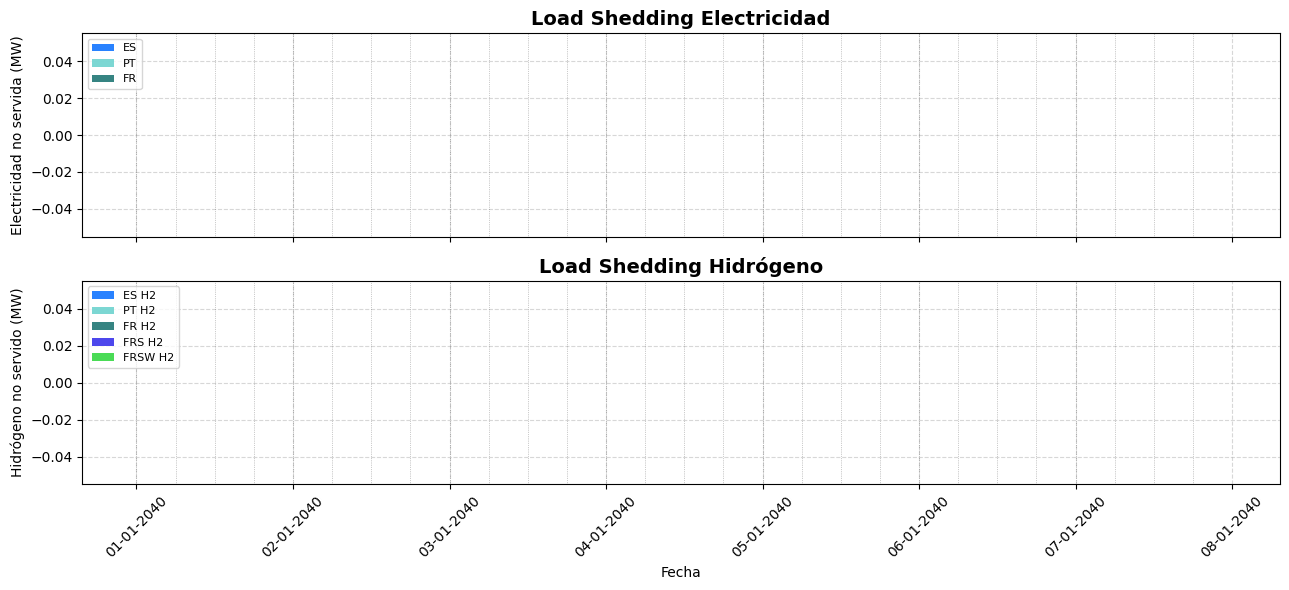

In [277]:
# ---------------------------------------------------------------------
plt.style.use("default")
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

color_map = {
    "ES_load_shedding": "#1275FF",
    "PT_load_shedding": "#6ED3CF",
    "FR_load_shedding": "#207774",
    "ES_load_shedding_h2": "#1275FF",
    "PT_load_shedding_h2": "#6ED3CF",
    "FR_load_shedding_h2": "#207774",
    "FRS_load_shedding_h2": "#3A33EA",
    "FRSW_load_shedding_h2": "#36D744",
}

label_map = {
    "ES_load_shedding": "ES",
    "PT_load_shedding": "PT",
    "FR_load_shedding": "FR",
    "ES_load_shedding_h2": "ES H2",
    "PT_load_shedding_h2": "PT H2",
    "FR_load_shedding_h2": "FR H2",
    "FRS_load_shedding_h2": "FRS H2",
    "FRSW_load_shedding_h2": "FRSW H2",
}

# ===================== (1) ELECTRICIDAD =====================
generadores_elec = [
    "ES_load_shedding",
    "PT_load_shedding",
    "FR_load_shedding",
]

series = []
labels = []
colors = []

for gen in generadores_elec:
    if gen in network.generators_t.p.columns:
        s = (
            network.generators_t.p[gen]
            .reindex(hours)
            .fillna(0.0)
            .clip(lower=0)
            .values
        )
        series.append(s)
        labels.append(label_map.get(gen, gen))
        colors.append(color_map.get(gen, "#999999"))

if series:
    axes[0].stackplot(hours, series, labels=labels, colors=colors, alpha=0.9)
else:
    axes[0].text(
        0.5, 0.5, "Sin load shedding eléctrico",
        transform=axes[0].transAxes, ha="center", va="center"
    )

axes[0].set_title("Load Shedding Electricidad", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Electricidad no servida (MW)")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend(loc="upper left", fontsize=8)

# ===================== (2) HIDRÓGENO =====================
generadores_h2 = [
    "ES_load_shedding_h2",
    "PT_load_shedding_h2",
    "FR_load_shedding_h2",
    "FRS_load_shedding_h2",
    "FRSW_load_shedding_h2",
]

series = []
labels = []
colors = []

for gen in generadores_h2:
    if gen in network.generators_t.p.columns:
        s = (
            network.generators_t.p[gen]
            .reindex(hours)
            .fillna(0.0)
            .clip(lower=0)
            .values
        )
        series.append(s)
        labels.append(label_map.get(gen, gen))
        colors.append(color_map.get(gen, "#999999"))

if series:
    axes[1].stackplot(hours, series, labels=labels, colors=colors, alpha=0.9)
else:
    axes[1].text(
        0.5, 0.5, "Sin load shedding de hidrógeno",
        transform=axes[1].transAxes, ha="center", va="center"
    )

axes[1].set_title("Load Shedding Hidrógeno", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("Hidrógeno no servido (MW)")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend(loc="upper left", fontsize=8)

# ===================== FORMATO COMÚN =====================
for ax in axes:
    for day in pd.date_range("2025-01-01", "2025-01-07"):
        for hour_mark in [0, 6, 12, 18]:
            timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour_mark)
            ax.axvline(x=timestamp, color="black", linestyle=":", linewidth=0.5, alpha=0.4)

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%m-2040"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# ---------------------------------------------------------------------

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\253163138.py:11: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\253163138.py:12: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\253163138.py:13: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\253163138.py:16: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_152

                                          bus0                       bus1
name                                                                     
ES_SRES_electrolyzer  ES_SRES_electrolyzer_bus            ES_hydrogen_bus
ES_SRES_excedentes      ES_SRES_excedentes_bus  ES_electricity_market_bus
name                 ES_SRES_electrolyzer  ES_SRES_excedentes
snapshot                                                     
2025-01-01 00:00:00            7423.16644                -0.0
2025-01-01 01:00:00            7943.70507                -0.0
2025-01-01 02:00:00            8079.23839                -0.0
2025-01-01 03:00:00            8282.01439                -0.0
2025-01-01 04:00:00            8682.46007                -0.0
name                 ES_SRES_electrolyzer  ES_SRES_excedentes
snapshot                                                     
2025-01-01 00:00:00           -7423.16644                 0.0
2025-01-01 01:00:00           -7943.70507                 0.0
2025-01-01 02:00:00   

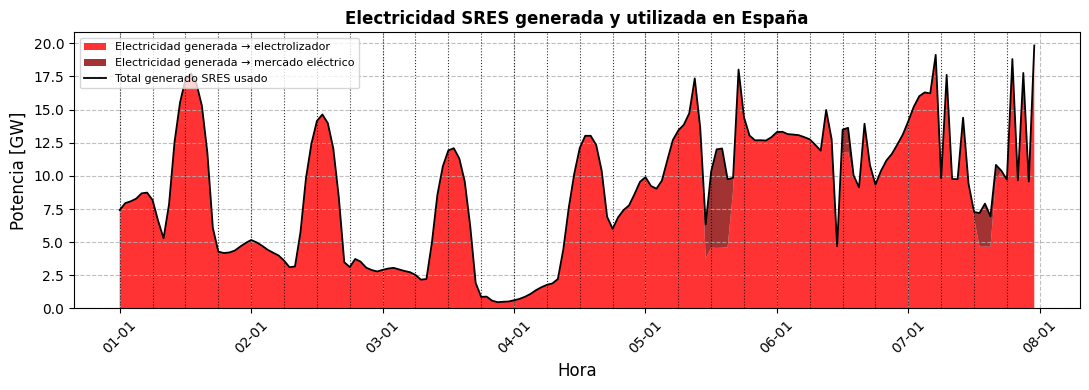

In [278]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h")

link_ely = "ES_SRES_electrolyzer"
link_exc = "ES_SRES_excedentes"

# Inspección de signos
print(network.links.df.loc[[link_ely, link_exc], ["bus0", "bus1"]])
print(network.links_t.p0[[link_ely, link_exc]].head())
print(network.links_t.p1[[link_ely, link_exc]].head())

# Opción habitual: flujo útil saliendo de bus0
ely = network.links_t.p0[link_ely]
exc = network.links_t.p0[link_exc]

# Si tus flujos útiles salen negativos, cambia estas dos líneas por:
# ely = -network.links_t.p0[link_ely]
# exc = -network.links_t.p0[link_exc]

ely = ely.clip(lower=0) / 1e3
exc = exc.clip(lower=0) / 1e3

ely_w = ely.loc[hours]
exc_w = exc.loc[hours]

plt.figure(figsize=(11,4))
plt.style.use("default")

plt.stackplot(
    hours,
    ely_w,
    exc_w,
    labels=[
        "Electricidad generada → electrolizador",
        "Electricidad generada → mercado eléctrico"
    ],
    colors=["red", "darkred"],
    alpha=0.8
)

plt.plot(
    hours,
    ely_w + exc_w,
    color="black",
    linewidth=1.3,
    label="Total generado SRES usado"
)

plt.title("Electricidad SRES generada y utilizada en España", fontsize=12, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Potencia [GW]", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.8)
plt.legend(loc="upper left", fontsize=8)

for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hh in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hh)
        plt.axvline(x=timestamp, color="black", linestyle=":", linewidth=0.8, alpha=0.8)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%m"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\625770400.py:11: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\625770400.py:12: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\625770400.py:13: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\625770400.py:16: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_152

                                          bus0                       bus1
name                                                                     
PT_SRES_electrolyzer  PT_SRES_electrolyzer_bus            PT_hydrogen_bus
PT_SRES_excedentes      PT_SRES_excedentes_bus  PT_electricity_market_bus
name                 PT_SRES_electrolyzer  PT_SRES_excedentes
snapshot                                                     
2025-01-01 00:00:00            944.335317                -0.0
2025-01-01 01:00:00            867.675414                -0.0
2025-01-01 02:00:00            816.855529                -0.0
2025-01-01 03:00:00            769.258529                -0.0
2025-01-01 04:00:00            735.283256                -0.0
name                 PT_SRES_electrolyzer  PT_SRES_excedentes
snapshot                                                     
2025-01-01 00:00:00           -944.335317                 0.0
2025-01-01 01:00:00           -867.675414                 0.0
2025-01-01 02:00:00   

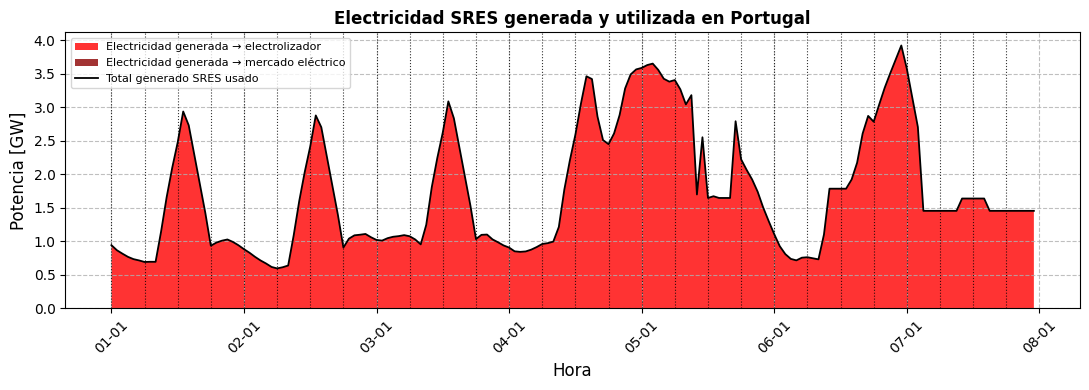

In [279]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h")

link_ely = "PT_SRES_electrolyzer"
link_exc = "PT_SRES_excedentes"

# Inspección de signos
print(network.links.df.loc[[link_ely, link_exc], ["bus0", "bus1"]])
print(network.links_t.p0[[link_ely, link_exc]].head())
print(network.links_t.p1[[link_ely, link_exc]].head())

# Opción habitual: flujo útil saliendo de bus0
ely = network.links_t.p0[link_ely]
exc = network.links_t.p0[link_exc]

# Si tus flujos útiles salen negativos, cambia estas dos líneas por:
# ely = -network.links_t.p0[link_ely]
# exc = -network.links_t.p0[link_exc]

ely = ely.clip(lower=0) / 1e3
exc = exc.clip(lower=0) / 1e3

ely_w = ely.loc[hours]
exc_w = exc.loc[hours]

plt.figure(figsize=(11,4))
plt.style.use("default")

plt.stackplot(
    hours,
    ely_w,
    exc_w,
    labels=[
        "Electricidad generada → electrolizador",
        "Electricidad generada → mercado eléctrico"
    ],
    colors=["red", "darkred"],
    alpha=0.8
)

plt.plot(
    hours,
    ely_w + exc_w,
    color="black",
    linewidth=1.3,
    label="Total generado SRES usado"
)

plt.title("Electricidad SRES generada y utilizada en Portugal", fontsize=12, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Potencia [GW]", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.8)
plt.legend(loc="upper left", fontsize=8)

for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hh in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hh)
        plt.axvline(x=timestamp, color="black", linestyle=":", linewidth=0.8, alpha=0.8)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%m"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

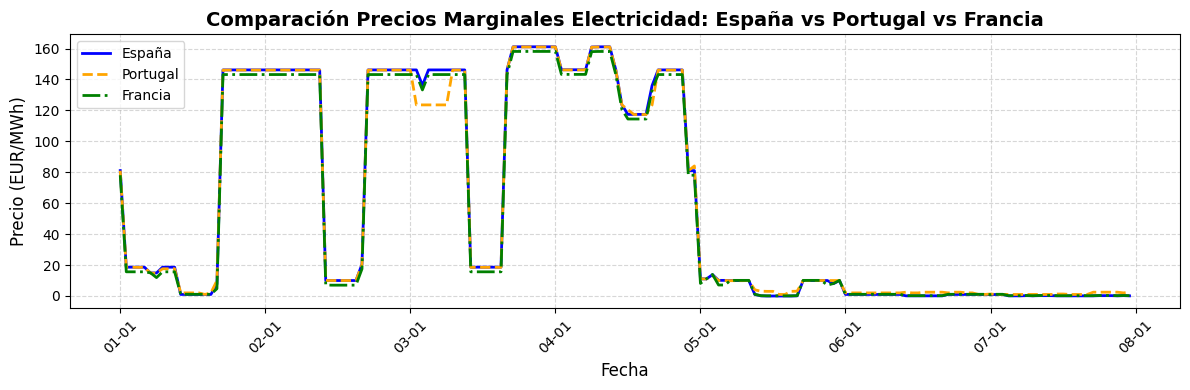

In [280]:
# Filtrar precios marginales para buses eléctricos
marginal_prices = network.buses.dynamic["marginal_price"]

# Seleccionar columnas específicas
cols_electricity = ["ES_electricity_market_bus", "PT_electricity_market_bus", "FR_electricity_market_bus"]

# Verificar que existen en el DataFrame
available_cols = [col for col in cols_electricity if col in marginal_prices.columns]

# Graficar con estilos diferentes
plt.figure(figsize=(12,4))

if "ES_electricity_market_bus" in available_cols:
    plt.plot(network.snapshots, marginal_prices["ES_electricity_market_bus"],
             label="España", color="blue", linestyle="-", linewidth=2)  # Línea continua

if "PT_electricity_market_bus" in available_cols:
    plt.plot(network.snapshots, marginal_prices["PT_electricity_market_bus"],
             label="Portugal", color="orange", linestyle="--", linewidth=2)  # Línea discontinua

if "FR_electricity_market_bus" in available_cols:
    plt.plot(network.snapshots, marginal_prices["FR_electricity_market_bus"],
             label="Francia", color="green", linestyle="-.", linewidth=2)  # Línea de puntos

# Personalización
plt.title("Comparación Precios Marginales Electricidad: España vs Portugal vs Francia", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Precio (EUR/MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%m"))
plt.tight_layout()
plt.show()

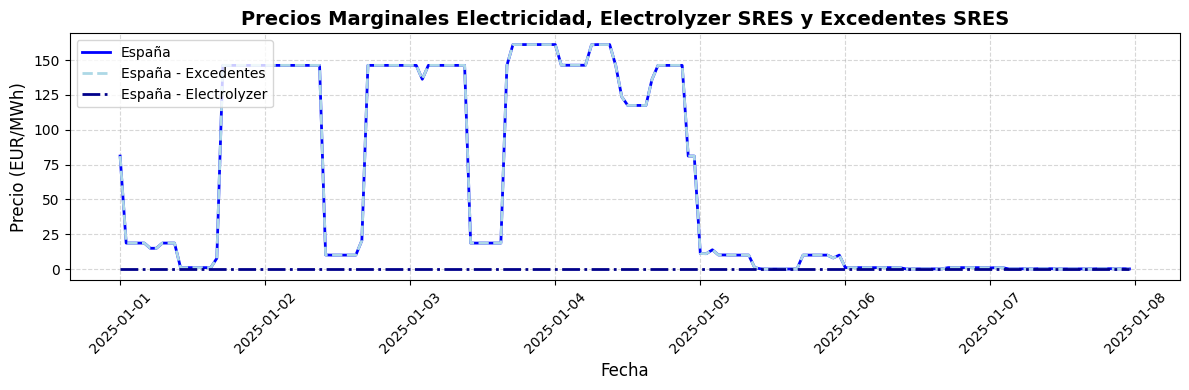

In [281]:
# Filtrar precios marginales para buses eléctricos
marginal_prices = network.buses.dynamic["marginal_price"]

# Seleccionar columnas específicas
cols_electricity = ["ES_electricity_market_bus", "ES_SRES_excedentes_bus", "ES_SRES_electrolyzer_bus"]

# Verificar que existen en el DataFrame
available_cols = [col for col in cols_electricity if col in marginal_prices.columns]

# Graficar con estilos diferentes
plt.figure(figsize=(12,4))

if "ES_electricity_market_bus" in available_cols:
    plt.plot(network.snapshots, marginal_prices["ES_electricity_market_bus"],
             label="España", color="blue", linestyle="-", linewidth=2)  # Línea continua

if "ES_SRES_excedentes_bus" in available_cols:
    plt.plot(network.snapshots, marginal_prices["ES_SRES_excedentes_bus"],
             label="España - Excedentes", color="lightblue", linestyle="--", linewidth=2)  # Línea discontinua

if "ES_SRES_electrolyzer_bus" in available_cols:
    plt.plot(network.snapshots, marginal_prices["ES_SRES_electrolyzer_bus"],
             label="España - Electrolyzer", color="darkblue", linestyle="-.", linewidth=2)  # Línea de puntos

# Personalización
plt.title("Precios Marginales Electricidad, Electrolyzer SRES y Excedentes SRES", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Precio (EUR/MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()

plt.show()

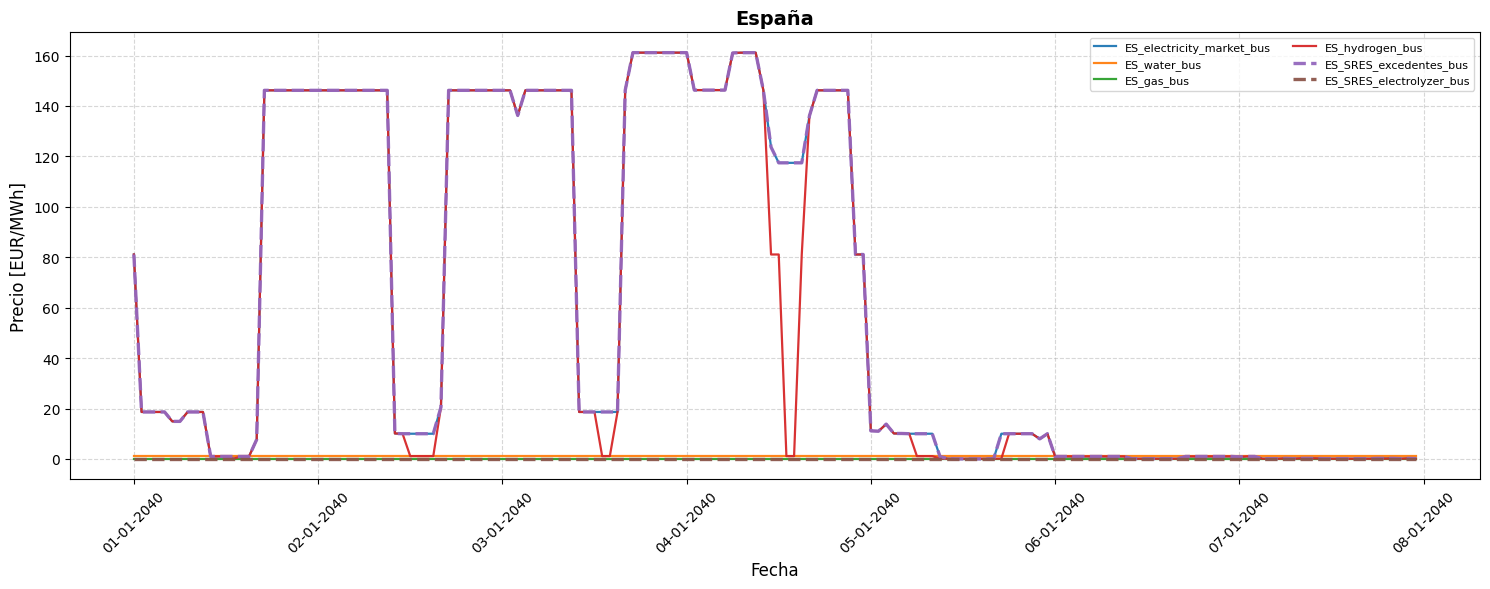

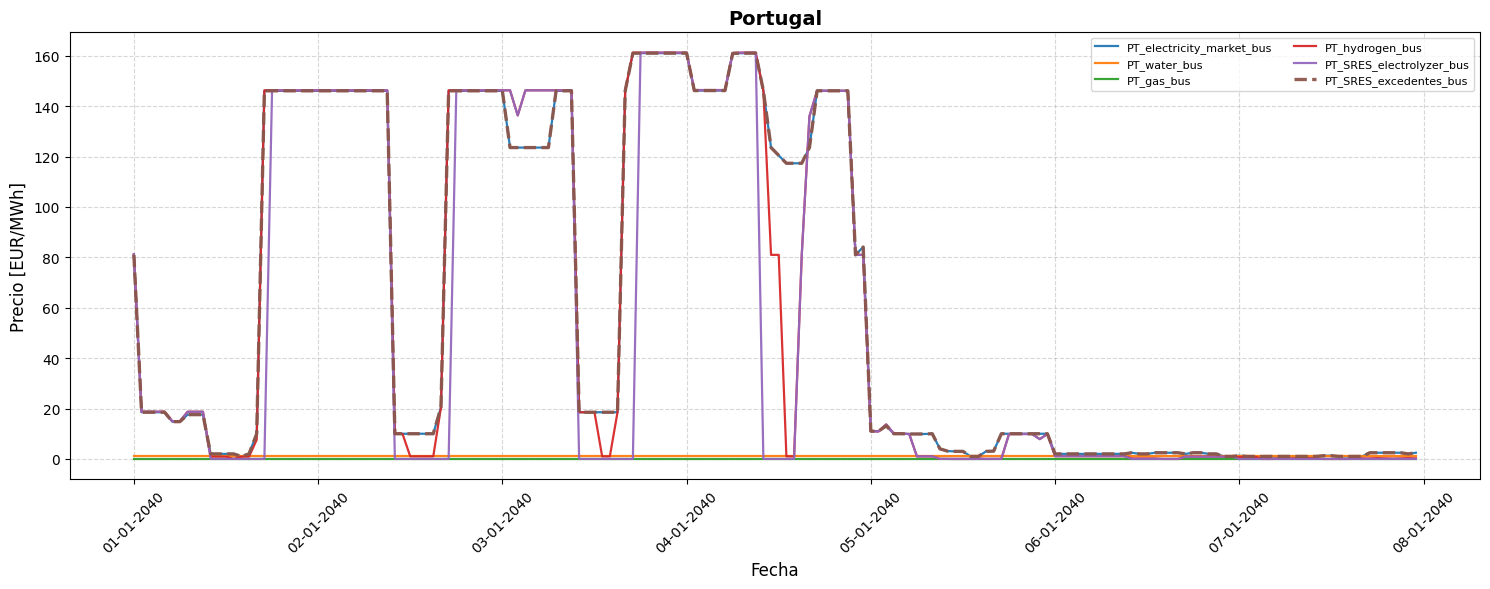

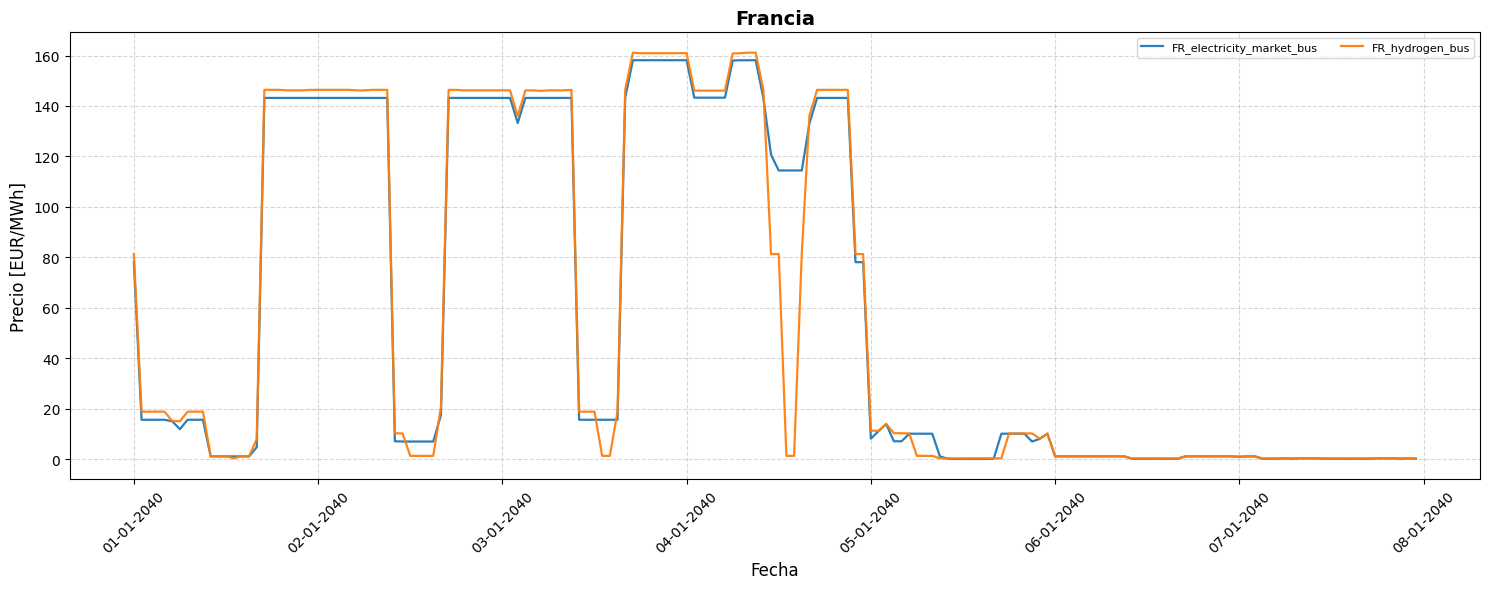

In [282]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ---------- helpers robustos PyPSA ----------
def get_bus_index(n):
    if hasattr(n.buses, "static"):   # API nueva
        return n.buses.static.index
    return n.buses.index             # API vieja

def get_marginal_prices(n):
    if hasattr(n.buses, "dynamic") and "marginal_price" in n.buses.dynamic:  # API nueva
        return n.buses.dynamic["marginal_price"]
    if hasattr(n, "buses_t") and hasattr(n.buses_t, "marginal_price"):       # API vieja
        return n.buses_t.marginal_price
    raise AttributeError("No encuentro marginal_price (¿has optimizado ya?).")

# ---------- agrupar series idénticas (o casi) ----------
def group_identical_columns(df, tol=1e-6, decimals=6):
    """
    Agrupa columnas con series idénticas (tras redondeo).
    tol no se usa aquí porque agrupamos por redondeo; ajusta decimals si quieres más/menos sensibilidad.
    """
    groups = {}
    for col in df.columns:
        key = tuple(np.round(df[col].to_numpy(dtype=float), decimals))
        groups.setdefault(key, []).append(col)
    return list(groups.values())

def plot_country_prices(network, prefix="ES_", title=None, decimals=6):
    bus_index = get_bus_index(network)
    mp = get_marginal_prices(network)

    buses = [b for b in bus_index if str(b).startswith(prefix)]
    if not buses:
        raise ValueError(f"No hay buses que empiecen por {prefix}")

    df = mp[buses].reindex(network.snapshots).fillna(0.0)

    # grupos de líneas coincidentes
    groups = group_identical_columns(df, decimals=decimals)

    # estilos dentro de cada grupo
    style_cycle = ["-", "--", ":", "-."]

    plt.figure(figsize=(15, 6))

    # 1) pinta primero los "representantes" (continuas) para que queden debajo
    for g in groups:
        b0 = g[0]
        plt.plot(network.snapshots, df[b0], linestyle="-", linewidth=1.6, alpha=0.95, label=b0, zorder=2)

    # 2) pinta después los duplicados con discontinua/punteada para que se vean encima
    for g in groups:
        for i, b in enumerate(g[1:], start=1):
            ls = style_cycle[min(i, len(style_cycle)-1)]
            plt.plot(network.snapshots, df[b], linestyle=ls, linewidth=2.4, alpha=0.95, label=b, zorder=4)

    plt.title(title or f"Precios marginales ({prefix.rstrip('_')})", fontsize=14, fontweight="bold")
    plt.xlabel("Fecha", fontsize=12)
    plt.ylabel("Precio [EUR/MWh]", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(loc="upper right", fontsize=8, ncol=2)
    plt.tight_layout()
    
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-2040'))
    plt.show()

# --- usarlo ---
plot_country_prices(network, "ES_", title="España", decimals=6)
plot_country_prices(network, "PT_", title="Portugal", decimals=6)
plot_country_prices(network, "FR_", title="Francia", decimals=6)

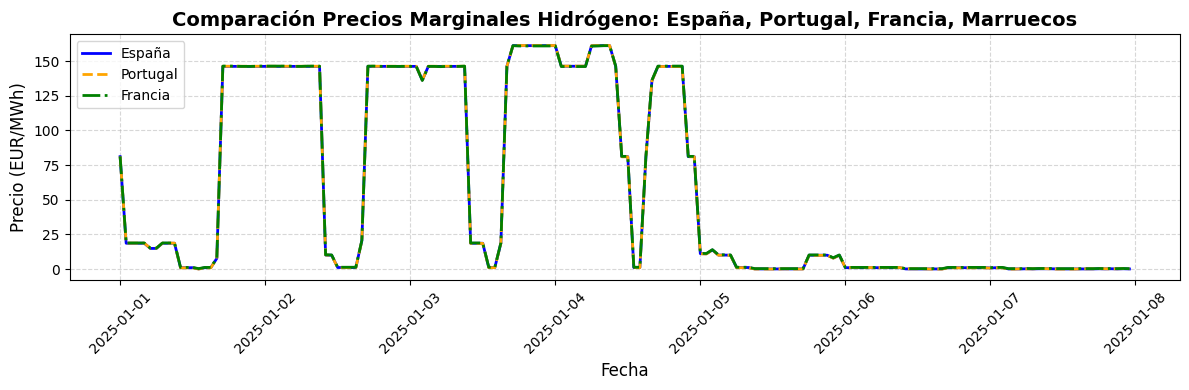

In [283]:
# Filtrar precios marginales para buses eléctricos
marginal_prices = network.buses.dynamic["marginal_price"]

# Seleccionar columnas específicas
cols_electricity = ["ES_hydrogen_bus", "PT_hydrogen_bus", "FR_hydrogen_bus", "MA_hydrogen_bus"]

# Verificar que existen en el DataFrame
available_cols = [col for col in cols_electricity if col in marginal_prices.columns]

# Graficar con estilos diferentes
plt.figure(figsize=(12,4))

if "ES_hydrogen_bus" in available_cols:
    plt.plot(network.snapshots, marginal_prices["ES_hydrogen_bus"],
             label="España", color="blue", linestyle="-", linewidth=2)  # Línea continua

if "PT_hydrogen_bus" in available_cols:
    plt.plot(network.snapshots, marginal_prices["PT_hydrogen_bus"],
             label="Portugal", color="orange", linestyle="--", linewidth=2)  # Línea discontinua

if "FR_hydrogen_bus" in available_cols:
    plt.plot(network.snapshots, marginal_prices["FR_hydrogen_bus"],
             label="Francia", color="green", linestyle="-.", linewidth=2)  # Línea de puntos

if "MA_hydrogen_bus" in available_cols:
    plt.plot(network.snapshots, marginal_prices["MA_hydrogen_bus"],
             label="Marruecos", color="red", linestyle=":", linewidth=2)  # Línea de puntos


# Personalización
plt.title("Comparación Precios Marginales Hidrógeno: España, Portugal, Francia, Marruecos", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Precio (EUR/MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\3449600336.py:16: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\3449600336.py:45: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\3449600336.py:50: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\3449600336.py:45: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dy

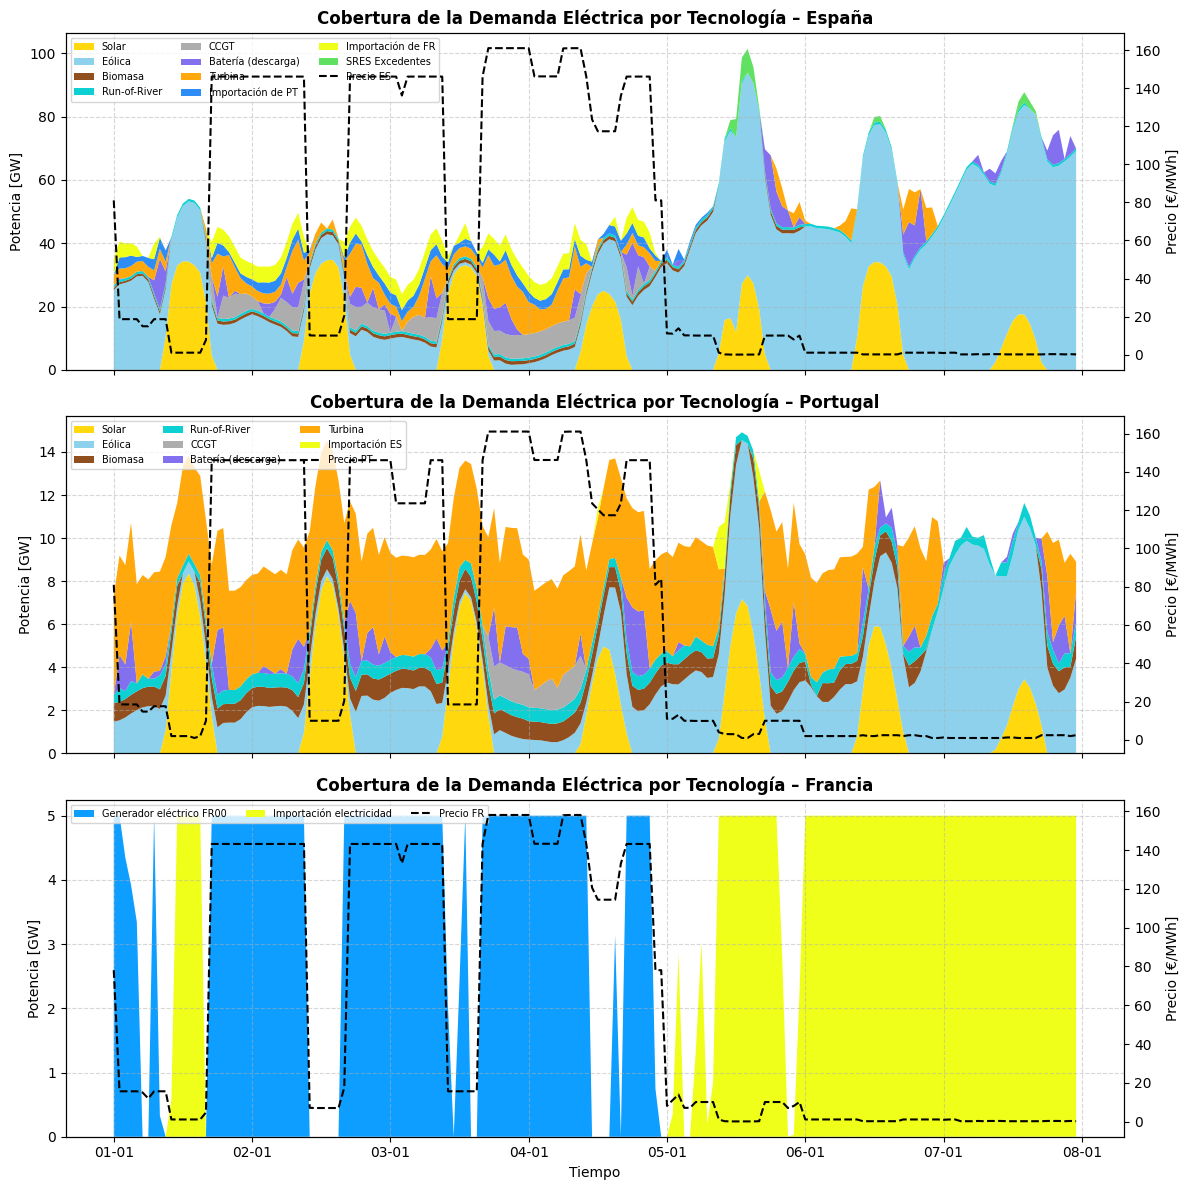

In [284]:
# ============================================================
# ESPAÑA, PORTUGAL Y FRANCIA — COBERTURA + PRECIO
# 3 subplots con colores y leyendas
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

n = network
times = n.snapshots

# ============================================================
# ESPAÑA
# ============================================================
gen = n.generators_t.p.copy()
gen_names = gen.columns.str.lower()

def sum_generators_by_contains(gen_df, patterns, times):
    cols = gen_df.columns.astype(str)
    cols_lower = cols.str.lower()

    mask = pd.Series(False, index=cols)
    for p in patterns:
        mask = mask | cols_lower.str.contains(p.lower(), regex=False)

    selected = list(cols[mask.values])

    if len(selected) == 0:
        return pd.Series(0.0, index=times), []

    return gen_df[selected].sum(axis=1).reindex(times).fillna(0.0), selected


def inflow_to_bus_from_links(n, link_names, target_bus, times):
    out = pd.Series(0.0, index=times, dtype=float)

    for link in link_names:
        if link not in n.links.static.index:
            continue

        bus0 = n.links.static.loc[link, "bus0"]
        bus1 = n.links.static.loc[link, "bus1"]

        if link not in n.links_t.p0.columns or link not in n.links_t.p1.columns:
            continue

        if bus1 == target_bus:
            out = out.add(
                (-n.links_t.p1[link]).clip(lower=0).reindex(times).fillna(0.0),
                fill_value=0.0
            )
        elif bus0 == target_bus:
            out = out.add(
                (-n.links_t.p0[link]).clip(lower=0).reindex(times).fillna(0.0),
                fill_value=0.0
            )

    return out


renew_specs_ES = {
    "ES_Solar": ["es_solar"],
    "ES_Eólica": ["es_wind"],
    "ES_Biomasa": ["es_biomass"],
    "ES_Run-of-River": ["es_water"],
    "ES_load_shedding": ["es_load_shedding"],
}

renew_series_ES = {}
for label, patterns in renew_specs_ES.items():
    s, found = sum_generators_by_contains(gen, patterns, times)
    renew_series_ES[label] = s

target_bus_ES = "ES_electricity_market_bus"

ccgt_links_ES = [name for name in n.links.static.index if "es_ccgt" in name.lower()]
CCGT_ES = inflow_to_bus_from_links(n, ccgt_links_ES, target_bus_ES, times)

turb_links_ES = [name for name in n.links.static.index if "es_turbina" in name.lower()]
turb_ES = inflow_to_bus_from_links(n, turb_links_ES, target_bus_ES, times)

import_pt_es = inflow_to_bus_from_links(n, ["PT_ES_interconexion_electricidad"], target_bus_ES, times)
import_fr_es = inflow_to_bus_from_links(n, ["FR_ES_interconexion_electricidad"], target_bus_ES, times)
sres_excedentes_ES = inflow_to_bus_from_links(n, ["ES_SRES_excedentes"], target_bus_ES, times)

battery_sus_ES = [
    name for name in n.storage_units.static.index
    if "es_electricity_market_battery" in name.lower()
]

bat_net_ES = (
    n.storage_units_t.p[battery_sus_ES].sum(axis=1).reindex(times).fillna(0.0)
    if len(battery_sus_ES) else pd.Series(0.0, index=times)
)

battery_discharge_ES = bat_net_ES.clip(lower=0)

df_plot_ES = pd.DataFrame({
    "ES_Solar": renew_series_ES["ES_Solar"] / 1e3,
    "ES_Eólica": renew_series_ES["ES_Eólica"] / 1e3,
    "ES_Biomasa": renew_series_ES["ES_Biomasa"] / 1e3,
    "ES_Run-of-River": renew_series_ES["ES_Run-of-River"] / 1e3,
    "ES_CCGT": CCGT_ES / 1e3,
    "ES_electricity_market_battery": battery_discharge_ES / 1e3,
    "ES_turbina": turb_ES / 1e3,
    "PT_ES_interconexion_electricidad": import_pt_es / 1e3,
    "FR_ES_interconexion_electricidad": import_fr_es / 1e3,
    "ES_sres_excedentes": sres_excedentes_ES / 1e3,
    "ES_load_shedding": renew_series_ES["ES_load_shedding"] / 1e3,
}, index=times)

df_plot_ES = df_plot_ES.loc[:, (df_plot_ES.abs().sum(axis=0) > 1e-12)]
price_es = n.buses_t.marginal_price["ES_electricity_market_bus"].reindex(times)

colors_ES = {
    "ES_Solar": "#FFD700",
    "ES_Eólica": "#87CFEBBE",
    "ES_Biomasa": "#8B4513",
    "ES_Run-of-River": "#00CED1",
    "ES_CCGT": "#A9A9A9",
    "ES_electricity_market_battery": "#7B68EE",
    "ES_turbina": "#FFA500",
    "PT_ES_interconexion_electricidad": "#2386F7B2",
    "FR_ES_interconexion_electricidad": "#EFFF0DB1",
    "ES_sres_excedentes": "#58E058",
    "ES_load_shedding": "#FF0000",
}

label_map_ES = {
    "ES_Solar": "Solar",
    "ES_Eólica": "Eólica",
    "ES_Biomasa": "Biomasa",
    "ES_Run-of-River": "Run-of-River",
    "ES_CCGT": "CCGT",
    "ES_electricity_market_battery": "Batería (descarga)",
    "ES_turbina": "Turbina",
    "PT_ES_interconexion_electricidad": "Importación de PT",
    "FR_ES_interconexion_electricidad": "Importación de FR",
    "ES_sres_excedentes": "SRES Excedentes",
    "ES_load_shedding": "Load shedding",
}

# ============================================================
# PORTUGAL
# ============================================================
gen = n.generators_t.p
gen_names = gen.columns.str.lower()

renew_map_PT = {
    "PT_Solar": "pt_solar",
    "PT_Eólica": "pt_wind",
    "PT_Biomasa": "pt_biomass",
    "PT_Water": "pt_water",
    "PT_load_shedding": "pt_load_shedding",
}

renew_series_PT = {}
for label, key in renew_map_PT.items():
    gens = gen.columns[gen_names.str.contains(key)]
    if len(gens) == 0:
        renew_series_PT[label] = pd.Series(0.0, index=times)
    else:
        renew_series_PT[label] = gen[gens].sum(axis=1).reindex(times).fillna(0.0)

ccgt_name_PT = [name for name in n.links.static.index if "pt_ccgt" in name.lower()]
CCGT_PT = (
    -n.links_t.p1[ccgt_name_PT].sum(axis=1).clip(upper=0).reindex(times).fillna(0.0)
    if len(ccgt_name_PT) else pd.Series(0.0, index=times)
)

turb_name_PT = [name for name in n.links.static.index if "pt_turbina" in name.lower()]
turb_PT = (
    -n.links_t.p1[turb_name_PT].sum(axis=1).clip(upper=0).reindex(times).fillna(0.0)
    if len(turb_name_PT) else pd.Series(0.0, index=times)
)

if "ES_PT_interconexion_electricidad" in n.links_t.p1.columns:
    import_es_pt = -n.links_t.p1["ES_PT_interconexion_electricidad"].clip(upper=0).reindex(times).fillna(0.0)
else:
    import_es_pt = pd.Series(0.0, index=times)

sres_excedentes_name_PT = [
    name for name in n.links.static.index
    if "pt_sres_excedentes" in name.lower()
]

sres_excedentes_PT = (
    -n.links_t.p1[sres_excedentes_name_PT].sum(axis=1).clip(upper=0).reindex(times).fillna(0.0)
    if len(sres_excedentes_name_PT) else pd.Series(0.0, index=times)
)

battery_sus_PT = [
    name for name in n.storage_units.static.index
    if "pt_electricity_market_battery" in name.lower()
]

bat_net_PT = (
    n.storage_units_t.p[battery_sus_PT].sum(axis=1).reindex(times).fillna(0.0)
    if len(battery_sus_PT) else pd.Series(0.0, index=times)
)

battery_discharge_PT = bat_net_PT.clip(lower=0)

df_plot_PT = pd.DataFrame({
    "PT_Solar": renew_series_PT["PT_Solar"] / 1e3,
    "PT_Eólica": renew_series_PT["PT_Eólica"] / 1e3,
    "PT_Biomasa": renew_series_PT["PT_Biomasa"] / 1e3,
    "PT_Run-of-River": renew_series_PT["PT_Water"] / 1e3,
    "PT_CCGT": CCGT_PT / 1e3,
    "PT_electricity_market_battery": battery_discharge_PT / 1e3,
    "PT_turbina": turb_PT / 1e3,
    "ES_PT_interconexion_electricidad": import_es_pt / 1e3,
    "PT_sres_excedentes": sres_excedentes_PT / 1e3,
    "PT_load_shedding": renew_series_PT["PT_load_shedding"] / 1e3,
}, index=times)

df_plot_PT = df_plot_PT.loc[:, (df_plot_PT.abs().sum(axis=0) > 1e-12)]
price_pt = n.buses_t.marginal_price["PT_electricity_market_bus"].reindex(times)

colors_PT = {
    "PT_Solar": "#FFD700",
    "PT_Eólica": "#87CFEBBE",
    "PT_Biomasa": "#8B4513",
    "PT_Run-of-River": "#00CED1",
    "PT_CCGT": "#A9A9A9",
    "PT_electricity_market_battery": "#7B68EE",
    "PT_turbina": "#FFA500",
    "ES_PT_interconexion_electricidad": "#EFFF0DB1",
    "PT_sres_excedentes": "#32CD32",
    "PT_load_shedding": "#FF0000",
}

label_map_PT = {
    "PT_Solar": "Solar",
    "PT_Eólica": "Eólica",
    "PT_Biomasa": "Biomasa",
    "PT_Run-of-River": "Run-of-River",
    "PT_CCGT": "CCGT",
    "PT_electricity_market_battery": "Batería (descarga)",
    "PT_turbina": "Turbina",
    "ES_PT_interconexion_electricidad": "Importación ES",
    "PT_sres_excedentes": "SRES Excedentes",
    "PT_load_shedding": "Load shedding",
}

# ============================================================
# FRANCIA
# ============================================================
gen = n.generators_t.p

if "FR_electricity_generator" in gen.columns:
    fr_electricity_generator = gen["FR_electricity_generator"].reindex(times).fillna(0.0)
else:
    fr_electricity_generator = pd.Series(0.0, index=times)

if "ES_FR_interconexion_electricidad" in n.links_t.p1.columns:
    import_es_fr = -n.links_t.p1["ES_FR_interconexion_electricidad"].clip(upper=0).reindex(times).fillna(0.0)
else:
    import_es_fr = pd.Series(0.0, index=times)

if "FR_load_shedding" in gen.columns:
    fr_load_shedding = gen["FR_load_shedding"].reindex(times).fillna(0.0)
else:
    fr_load_shedding = pd.Series(0.0, index=times)

df_plot_FR = pd.DataFrame({
    "FR_electricity_generator": fr_electricity_generator / 1e3,
    "FR_Importaciones_Electricidad": import_es_fr / 1e3,
    "FR_load_shedding": fr_load_shedding / 1e3,
}, index=times)

df_plot_FR = df_plot_FR.loc[:, (df_plot_FR.abs().sum(axis=0) > 1e-12)]
price_fr = n.buses_t.marginal_price["FR_electricity_market_bus"].reindex(times)

colors_FR = {
    "FR_electricity_generator": "#0099FF",
    "FR_Importaciones_Electricidad": "#EFFF0DB1",
    "FR_load_shedding": "#FF0000",
}

label_map_FR = {
    "FR_electricity_generator": "Generador eléctrico FR00",
    "FR_Importaciones_Electricidad": "Importación electricidad",
    "FR_load_shedding": "Load shedding",
}

# ============================================================
# PLOT FINAL — 3 SUBPLOTS
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

plots = [
    (
        axes[0],
        df_plot_ES,
        price_es,
        colors_ES,
        label_map_ES,
        "Cobertura de la Demanda Eléctrica por Tecnología – España",
        "Precio ES"
    ),
    (
        axes[1],
        df_plot_PT,
        price_pt,
        colors_PT,
        label_map_PT,
        "Cobertura de la Demanda Eléctrica por Tecnología – Portugal",
        "Precio PT"
    ),
    (
        axes[2],
        df_plot_FR,
        price_fr,
        colors_FR,
        label_map_FR,
        "Cobertura de la Demanda Eléctrica por Tecnología – Francia",
        "Precio FR"
    ),
]

for ax1, df_plot_i, price_i, colors_i, label_map_i, title_i, price_label_i in plots:
    plot_order = list(df_plot_i.columns)

    ax1.stackplot(
        df_plot_i.index,
        *[df_plot_i[c] for c in plot_order],
        labels=[label_map_i.get(c, c) for c in plot_order],
        colors=[colors_i.get(c, "#BAB0AC") for c in plot_order],
        linewidth=0.0,
        alpha=0.95
    )

    ax1.set_title(title_i, fontsize=12, fontweight="bold")
    ax1.set_ylabel("Potencia [GW]", fontsize=10)
    ax1.grid(True, linestyle="--", alpha=0.5)

    ax2 = ax1.twinx()
    ax2.plot(
        price_i.index,
        price_i,
        color="black",
        linestyle="--",
        linewidth=1.5,
        label=price_label_i
    )
    ax2.set_ylabel("Precio [€/MWh]", fontsize=10)

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()

    ax1.legend(
        h1 + h2,
        l1 + l2,
        loc="upper left",
        fontsize=7,
        ncol=3
    )

axes[-1].set_xlabel("Tiempo", fontsize=10)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d-%m"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\1437305304.py:6: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\1437305304.py:84: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\1437305304.py:94: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\1437305304.py:84: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dyn

SRES_MODE detectado en la red: 2busSRES


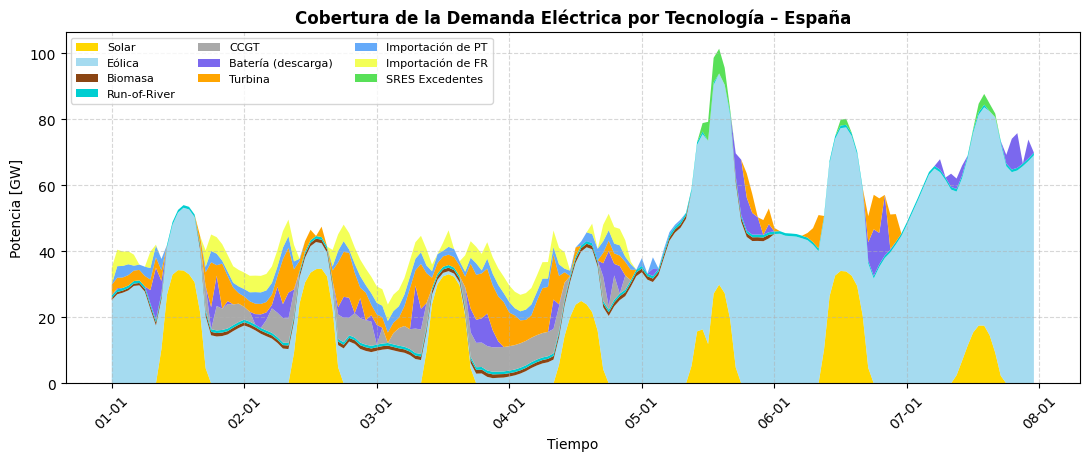

In [285]:
# ESPAÑA — COBERTURA DE LA DEMANDA ELÉCTRICA (compatible con 1busSRES y 2busSRES)


n = network
times = n.snapshots
gen = n.generators_t.p.copy()
gen_names = gen.columns.str.lower()

# ------------------------------------------------------------
# 0) Detectar SRES_MODE desde la topología real de la red
# ------------------------------------------------------------
bus_index = n.buses.static.index.astype(str)

if "ES_SRES_bus" in bus_index:
    detected_sres_mode = "1busSRES"
elif "ES_SRES_excedentes_bus" in bus_index and "ES_SRES_electrolyzer_bus" in bus_index:
    detected_sres_mode = "2busSRES"
else:
    detected_sres_mode = "unknown"

print(f"SRES_MODE detectado en la red: {detected_sres_mode}")

# ------------------------------------------------------------
# 1) Helper para sumar generadores por nombre
# ------------------------------------------------------------
def sum_generators_by_contains(gen_df, patterns, times):
    """
    Suma generadores cuyo nombre contiene cualquiera de los patrones.
    patterns: lista de strings en minúscula
    """
    cols = gen_df.columns.astype(str)
    cols_lower = cols.str.lower()

    mask = pd.Series(False, index=cols)
    for p in patterns:
        mask = mask | cols_lower.str.contains(p.lower(), regex=False)

    selected = list(cols[mask.values])

    if len(selected) == 0:
        return pd.Series(0.0, index=times), []

    return gen_df[selected].sum(axis=1).reindex(times).fillna(0.0), selected

# ------------------------------------------------------------
# 2) Generadores que cubren demanda eléctrica en España
# ------------------------------------------------------------
# Conviene usar patrones algo flexibles para que funcione en ambos modos
renew_specs = {
    "ES_Solar": ["es_solar"],
    "ES_Eólica": ["es_wind"],
    "ES_Biomasa": ["es_biomass"],
    "ES_Run-of-River": ["es_water"],
    "ES_load_shedding": ["es_load_shedding"],
}

renew_series = {}
for label, patterns in renew_specs.items():
    s, found = sum_generators_by_contains(gen, patterns, times)
    if len(found) == 0:
        print(f"No se encontraron generadores para {label} con patrones {patterns}")
    renew_series[label] = s

# ------------------------------------------------------------
# 3) Helper para flujos de links que ENTRAN en ES_electricity_market_bus
# ------------------------------------------------------------
def inflow_to_bus_from_links(n, link_names, target_bus, times):
    """
    Devuelve la potencia positiva que entra en target_bus desde los links indicados.
    Funciona tanto si el bus objetivo es bus0 como bus1 del link.
    """
    if len(link_names) == 0:
        return pd.Series(0.0, index=times)

    out = pd.Series(0.0, index=times, dtype=float)

    for link in link_names:
        if link not in n.links.static.index:
            continue

        bus0 = n.links.static.loc[link, "bus0"]
        bus1 = n.links.static.loc[link, "bus1"]

        if link not in n.links_t.p0.columns or link not in n.links_t.p1.columns:
            continue

        # Convención PyPSA:
        # p0 > 0 => sale de bus0
        # p1 > 0 => sale de bus1
        # Por tanto, entrada a bus1 = max(-p1, 0)
        #             entrada a bus0 = max(-p0, 0)
        if bus1 == target_bus:
            out = out.add(
                (-n.links_t.p1[link]).clip(lower=0).reindex(times).fillna(0.0),
                fill_value=0.0
            )
        elif bus0 == target_bus:
            out = out.add(
                (-n.links_t.p0[link]).clip(lower=0).reindex(times).fillna(0.0),
                fill_value=0.0
            )

    return out

# ------------------------------------------------------------
# 4) Links que cubren demanda eléctrica en España
# ------------------------------------------------------------
target_bus = "ES_electricity_market_bus"

# CCGT
ccgt_links = [name for name in n.links.static.index if "es_ccgt" in name.lower()]
if len(ccgt_links) == 0:
    print("No se encontró ningún link con 'es_ccgt'")
CCGT = inflow_to_bus_from_links(n, ccgt_links, target_bus, times)

# Turbina
turb_links = [name for name in n.links.static.index if "es_turbina" in name.lower()]
if len(turb_links) == 0:
    print("No se encontró ningún link con 'es_turbina'")
turb = inflow_to_bus_from_links(n, turb_links, target_bus, times)

# Importación PT -> ES (electricidad)
import_pt_es_links = [name for name in n.links.static.index if name == "PT_ES_interconexion_electricidad"]
if len(import_pt_es_links) == 0:
    print("No se encontró 'PT_ES_interconexion_electricidad'")
import_pt_es = inflow_to_bus_from_links(n, import_pt_es_links, target_bus, times)

# Importación FR -> ES (electricidad)
import_fr_es_links = [name for name in n.links.static.index if name == "FR_ES_interconexion_electricidad"]
if len(import_fr_es_links) == 0:
    print("No se encontró 'FR_ES_interconexion_electricidad'")
import_fr_es = inflow_to_bus_from_links(n, import_fr_es_links, target_bus, times)

# SRES excedentes -> mercado eléctrico ES
# Compatible con tus nombres reales del Excel:
#   1busSRES: ES_SRES_excedentes (ES_SRES_bus -> ES_electricity_market_bus)
#   2busSRES: ES_SRES_excedentes (ES_SRES_excedentes_bus -> ES_electricity_market_bus)
sres_excedentes_links = [
    name for name in n.links.static.index
    if name.lower() == "es_sres_excedentes"
]

if len(sres_excedentes_links) == 0:
    print("No se encontró 'ES_SRES_excedentes'")

sres_excedentes = inflow_to_bus_from_links(n, sres_excedentes_links, target_bus, times)

# ------------------------------------------------------------
# 5) Storage units: descarga batería ES
# ------------------------------------------------------------
battery_sus = [
    name for name in n.storage_units.static.index
    if "es_electricity_market_battery" in name.lower()
]

if len(battery_sus) == 0:
    print("No se encontró 'ES_electricity_market_battery'")

bat_net = (
    n.storage_units_t.p[battery_sus].sum(axis=1).reindex(times).fillna(0.0)
    if len(battery_sus) else pd.Series(0.0, index=times)
)
battery_discharge = bat_net.clip(lower=0)

# ------------------------------------------------------------
# 6) DataFrame final
# ------------------------------------------------------------
df_plot = pd.DataFrame({
    "ES_Solar": renew_series["ES_Solar"] / 1e3,
    "ES_Eólica": renew_series["ES_Eólica"] / 1e3,
    "ES_Biomasa": renew_series["ES_Biomasa"] / 1e3,
    "ES_Run-of-River": renew_series["ES_Run-of-River"] / 1e3,
    "ES_CCGT": CCGT / 1e3,
    "ES_electricity_market_battery": battery_discharge / 1e3,
    "ES_turbina": turb / 1e3,
    "PT_ES_interconexion_electricidad": import_pt_es / 1e3,
    "FR_ES_interconexion_electricidad": import_fr_es / 1e3,
    "ES_sres_excedentes": sres_excedentes / 1e3,
    "ES_load_shedding": renew_series["ES_load_shedding"] / 1e3,
}, index=times)

# quitar columnas vacías
df_plot = df_plot.loc[:, (df_plot.abs().sum(axis=0) > 1e-12)]

# ------------------------------------------------------------
# 7) Colores y etiquetas
# ------------------------------------------------------------
colors = {
    "ES_Solar": "#FFD700",
    "ES_Eólica": "#87CFEBBE",
    "ES_Biomasa": "#8B4513",
    "ES_Run-of-River": "#00CED1",
    "ES_CCGT": "#A9A9A9",
    "ES_electricity_market_battery": "#7B68EE",
    "ES_turbina": "#FFA500",
    "PT_ES_interconexion_electricidad": "#2386F7B2",
    "FR_ES_interconexion_electricidad": "#EFFF0DB1",
    "ES_sres_excedentes": "#58E058",
    "ES_load_shedding": "#FF0000",
}

label_map = {
    "ES_Solar": "Solar",
    "ES_Eólica": "Eólica",
    "ES_Biomasa": "Biomasa",
    "ES_Run-of-River": "Run-of-River",
    "ES_CCGT": "CCGT",
    "ES_electricity_market_battery": "Batería (descarga)",
    "ES_turbina": "Turbina",
    "PT_ES_interconexion_electricidad": "Importación de PT",
    "FR_ES_interconexion_electricidad": "Importación de FR",
    "ES_sres_excedentes": "SRES Excedentes",
    "ES_load_shedding": "Load shedding",
}

plot_order = list(df_plot.columns)

# ------------------------------------------------------------
# 8) Plot
# ------------------------------------------------------------
plt.figure(figsize=(11,5))
plt.stackplot(
    df_plot.index,
    *[df_plot[c] for c in plot_order],
    labels=[label_map[c] for c in plot_order],
    colors=[colors[c] for c in plot_order],
    linewidth=0.0,
)

plt.title(
    f"Cobertura de la Demanda Eléctrica por Tecnología – España",
    fontsize=12,
    fontweight="bold"
)
plt.xlabel("Tiempo", fontsize=10)
plt.ylabel("Potencia [GW]", fontsize=10)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=8, ncol=3)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%m"))
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\414772235.py:8: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\414772235.py:40: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\414772235.py:49: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\414772235.py:54: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic

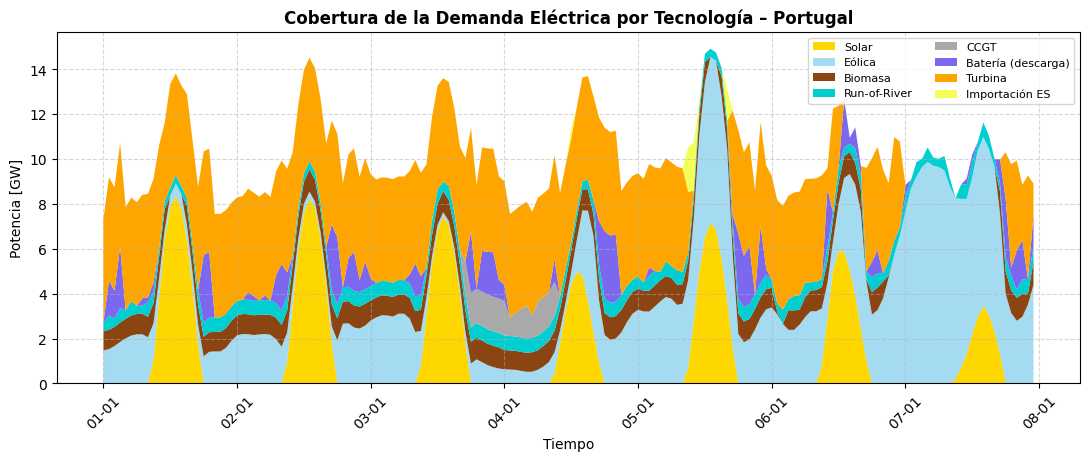

In [286]:
# PORTUGAL — COBERTURA DE LA DEMANDA ELÉCTRICA (CON LOAD SHEDDING)

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

times = network.snapshots
gen = network.generators_t.p
gen_names = gen.columns.str.lower()

# ------------------------------------------------------------------
# GENERADORES QUE CUBREN DEMANDA ELÉCTRICA EN PORTUGAL
# ------------------------------------------------------------------
renew_map = {
    "PT_Solar": "pt_solar",
    "PT_Eólica": "pt_wind",
    "PT_Biomasa": "pt_biomass",
    "PT_Water": "pt_water",
    "PT_load_shedding": "pt_load_shedding",
}

renew_series = {}
for label, key in renew_map.items():
    gens = gen.columns[gen_names.str.contains(key)]
    if len(gens) == 0:
        print(f"No se encontraron generadores con '{key}'")
        renew_series[label] = pd.Series(0.0, index=times)
    else:
        renew_series[label] = gen[gens].sum(axis=1).reindex(times).fillna(0.0)

# ------------------------------------------------------------------
# LINKS UTILIZADOS EN PORTUGAL PARA CUBRIR DEMANDA
# ------------------------------------------------------------------

# CCGT
ccgt_name = [n for n in network.links.static.index if "pt_ccgt" in n.lower()]
if len(ccgt_name) == 0:
    print("No se encontró ningún link con 'pt_ccgt'")
CCGT = (
    -network.links_t.p1[ccgt_name].sum(axis=1).clip(upper=0).reindex(times).fillna(0.0)
    if len(ccgt_name) else pd.Series(0.0, index=times)
)

# turbina
turb_name = [n for n in network.links.static.index if "pt_turbina" in n.lower()]
if len(turb_name) == 0:
    print("No se encontró ningún link con 'pt_turbina'")
turb = (
    -network.links_t.p1[turb_name].sum(axis=1).clip(upper=0).reindex(times).fillna(0.0)
    if len(turb_name) else pd.Series(0.0, index=times)
)

# importación desde España hacia Portugal (electricidad)
if "ES_PT_interconexion_electricidad" in network.links_t.p1.columns:
    import_pt_es = -network.links_t.p1["ES_PT_interconexion_electricidad"].clip(upper=0).reindex(times).fillna(0.0)
else:
    print("No se encontró 'ES_PT_interconexion_electricidad'")
    import_pt_es = pd.Series(0.0, index=times)

# SRES excedentes hacia mercado eléctrico portugués
sres_excedentes_name = [
    n for n in network.links.static.index
    if "pt_sres_excedentes" in n.lower()
]
if len(sres_excedentes_name) == 0:
    print("No se encontró ningún link con 'pt_sres_excedentes'")
sres_excedentes = (
    -network.links_t.p1[sres_excedentes_name].sum(axis=1).clip(upper=0).reindex(times).fillna(0.0)
    if len(sres_excedentes_name) else pd.Series(0.0, index=times)
)

# ------------------------------------------------------------------
# STORAGE UNITS
# ------------------------------------------------------------------
battery_sus = [
    n for n in network.storage_units.static.index
    if "pt_electricity_market_battery" in n.lower()
]

bat_net = (
    network.storage_units_t.p[battery_sus].sum(axis=1).reindex(times).fillna(0.0)
    if len(battery_sus) else pd.Series(0.0, index=times)
)
battery_discharge = bat_net.clip(lower=0)

# ------------------------------------------------------------------
# DATAFRAME
# ------------------------------------------------------------------
df_plot = pd.DataFrame({
    "PT_Solar": renew_series["PT_Solar"] / 1e3,
    "PT_Eólica": renew_series["PT_Eólica"] / 1e3,
    "PT_Biomasa": renew_series["PT_Biomasa"] / 1e3,
    "PT_Run-of-River": renew_series["PT_Water"] / 1e3,
    "PT_CCGT": CCGT / 1e3,
    "PT_electricity_market_battery": battery_discharge / 1e3,
    "PT_turbina": turb / 1e3,
    "ES_PT_interconexion_electricidad": import_pt_es / 1e3,
    "PT_sres_excedentes": sres_excedentes / 1e3,
    "PT_load_shedding": renew_series["PT_load_shedding"] / 1e3,
}, index=times)

# quitar columnas vacías
df_plot = df_plot.loc[:, (df_plot.abs().sum(axis=0) > 1e-12)]

# ------------------------------------------------------------------
# COLORES
# ------------------------------------------------------------------
colors = {
    "PT_Solar": "#FFD700",
    "PT_Eólica": "#87CFEBBE",
    "PT_Biomasa": "#8B4513",
    "PT_Run-of-River": "#00CED1",
    "PT_CCGT": "#A9A9A9",
    "PT_electricity_market_battery": "#7B68EE",
    "PT_turbina": "#FFA500",
    "ES_PT_interconexion_electricidad":"#EFFF0DB1",
    "PT_sres_excedentes": "#32CD32",
    "PT_load_shedding": "#FF0000",
}

label_map = {
    "PT_Solar": "Solar",
    "PT_Eólica": "Eólica",
    "PT_Biomasa": "Biomasa",
    "PT_Run-of-River": "Run-of-River",
    "PT_CCGT": "CCGT",
    "PT_electricity_market_battery": "Batería (descarga)",
    "PT_turbina": "Turbina",
    "ES_PT_interconexion_electricidad": "Importación ES",
    "PT_sres_excedentes": "SRES Excedentes",
    "PT_load_shedding": "Load shedding",
}

plot_order = list(df_plot.columns)

# ------------------------------------------------------------------
# PLOT
# ------------------------------------------------------------------
plt.figure(figsize=(11,5))
plt.stackplot(
    df_plot.index,
    *[df_plot[c] for c in plot_order],
    labels=[label_map[c] for c in plot_order],
    colors=[colors[c] for c in plot_order],
    linewidth=0.0,
)

plt.title("Cobertura de la Demanda Eléctrica por Tecnología – Portugal", fontsize=12, fontweight="bold")
plt.xlabel("Tiempo", fontsize=10)
plt.ylabel("Potencia [GW]", fontsize=10)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper right", fontsize=8, ncol=2)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\4226122280.py:2: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\4226122280.py:14: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\4226122280.py:18: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.



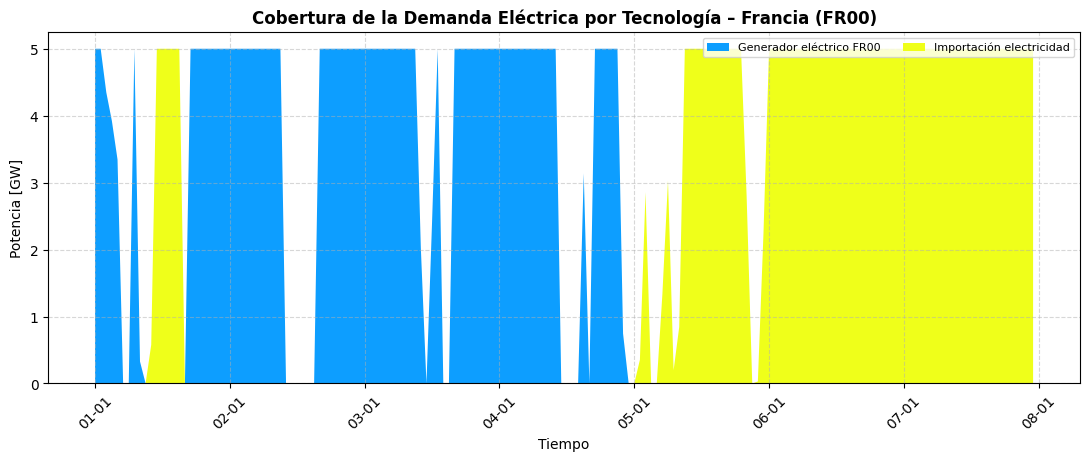

In [287]:
times = network.snapshots
gen = network.generators_t.p

# ------------------------------------------------------------------
# 1) GENERADOR ELÉCTRICO DE FRANCIA
# ------------------------------------------------------------------
if "FR_electricity_generator" in gen.columns:
    fr_electricity_generator = gen["FR_electricity_generator"].reindex(times).fillna(0.0)
else:
    None
# ------------------------------------------------------------------
# 2) IMPORTACIONES ELÉCTRICAS HACIA FRANCIA
# ------------------------------------------------------------------
link_cols_p1 = network.links_t.p1.columns

# ES -> FR
if "ES_FR_interconexion_electricidad" in link_cols_p1:
    import_es_fr = -network.links_t.p1["ES_FR_interconexion_electricidad"].clip(upper=0).reindex(times).fillna(0.0)
else:
    print("No se encontró 'ES_FR_interconexion_electricidad'")
    import_es_fr = pd.Series(0.0, index=times)

importaciones_electricidad = import_es_fr

# ------------------------------------------------------------------
# 4) LOAD SHEDDING ELÉCTRICO
# ------------------------------------------------------------------
if "FR_load_shedding" in gen.columns:
    fr_load_shedding = gen["FR_load_shedding"].reindex(times).fillna(0.0)
else:
    print("No se encontró 'FR_load_shedding'")
    fr_load_shedding = pd.Series(0.0, index=times)

# ------------------------------------------------------------------
# 5) DATAFRAME DE COBERTURA
# ------------------------------------------------------------------
df_plot = pd.DataFrame({
    "FR_electricity_generator": fr_electricity_generator / 1e3,
    "FR_Importaciones_Electricidad": importaciones_electricidad / 1e3,
    "FR_load_shedding": fr_load_shedding / 1e3,
}, index=times)

# opcional: quitar columnas vacías
df_plot = df_plot.loc[:, df_plot.sum(axis=0) > 1e-9]

# ------------------------------------------------------------------
# 6) COLORES
# ------------------------------------------------------------------
colors = {
    "FR_electricity_generator": "#0099FF",
    "FR_Importaciones_Electricidad": "#EFFF0DB1",
    "FR_load_shedding": "#FF0000",
}

label_map = {
    "FR_electricity_generator": "Generador eléctrico FR00",
    "FR_Importaciones_Electricidad": "Importación electricidad",
    "FR_load_shedding": "Load shedding",
}

plot_order = list(df_plot.columns)

# ------------------------------------------------------------------
# 7) PLOT
# ------------------------------------------------------------------
plt.figure(figsize=(11, 5))
plt.stackplot(
    df_plot.index,
    *[df_plot[col] for col in plot_order],
    labels=[label_map.get(col, col) for col in plot_order],
    colors=[colors.get(col, "#BAB0AC") for col in plot_order],
    linewidth=0.0,
    alpha=0.95
)

plt.title("Cobertura de la Demanda Eléctrica por Tecnología – Francia (FR00)", fontsize=12, fontweight="bold")
plt.xlabel("Tiempo", fontsize=10)
plt.ylabel("Potencia [GW]", fontsize=10)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper right", fontsize=8, ncol=2)
plt.tight_layout()

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%m"))
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\1456524293.py:17: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.buses.dynamic` as a drop-in replacement for `n.buses_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\1456524293.py:18: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.buses.dynamic` as a drop-in replacement for `n.buses_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\1456524293.py:23: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\1456524293.py:24: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as 

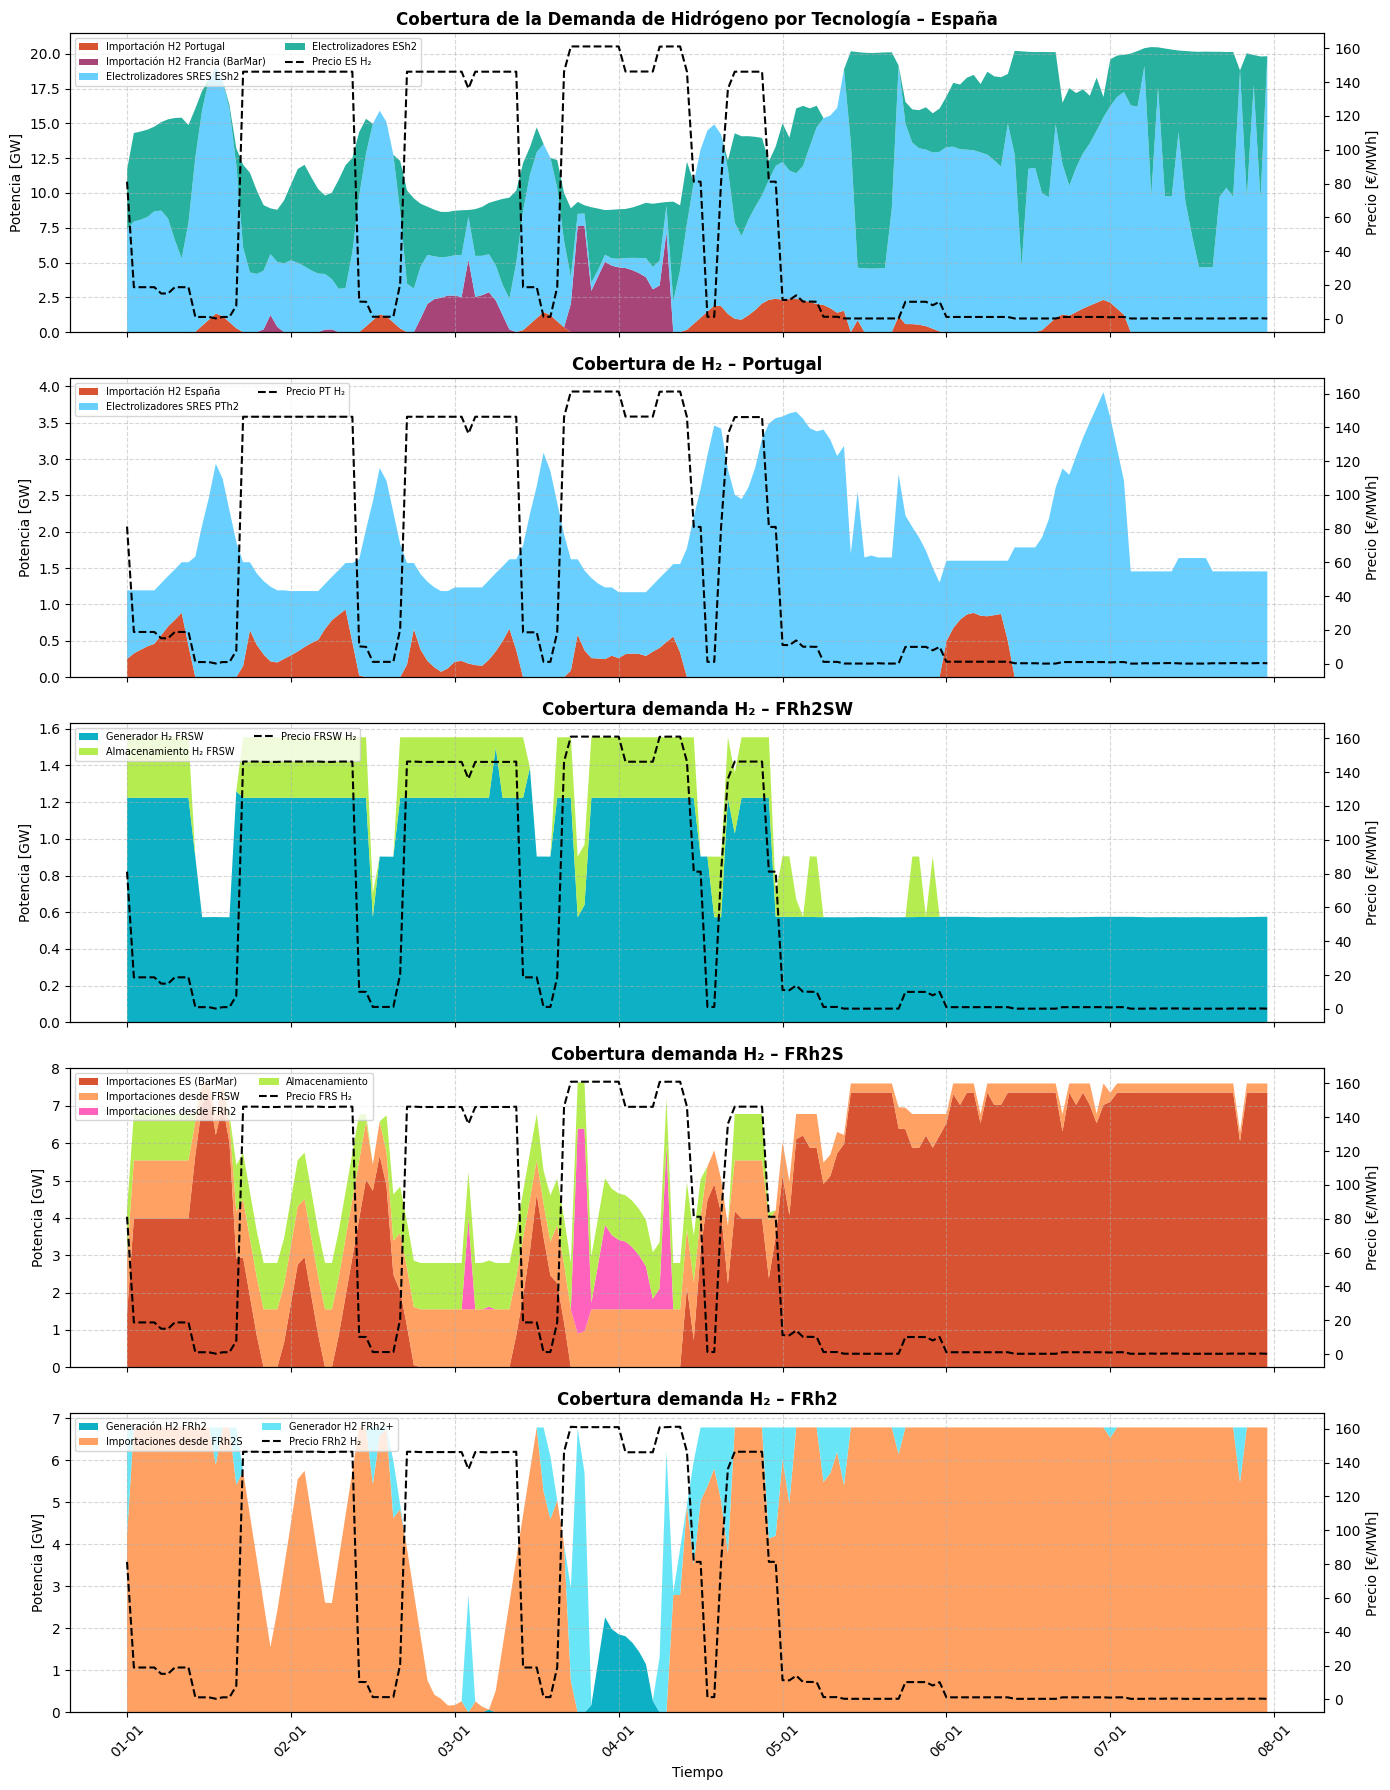

In [288]:
# ============================================================
# HIDRÓGENO — ESPAÑA, PORTUGAL Y FRANCIA
# 5 subplots + precios en negro discontinuo
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

times = network.snapshots

# ============================================================
# FUNCIONES
# ============================================================

def get_bus_price(bus_name):
    if bus_name in network.buses_t.marginal_price.columns:
        return network.buses_t.marginal_price[bus_name].reindex(times).fillna(0.0)
    print(f"No se encontró precio marginal para el bus: {bus_name}")
    return pd.Series(0.0, index=times)

def get_link_p1_positive_consumption(link_name):
    if link_name in network.links_t.p1.columns:
        return -network.links_t.p1[link_name].clip(upper=0).reindex(times).fillna(0.0) / 1e3
    return pd.Series(0.0, index=times)

def get_storage_discharge(storage_name):
    if storage_name in network.storage_units_t.p.columns:
        return network.storage_units_t.p[storage_name].clip(lower=0).reindex(times).fillna(0.0) / 1e3
    return pd.Series(0.0, index=times)

def get_generator_output(generator_name):
    if generator_name in network.generators_t.p.columns:
        return network.generators_t.p[generator_name].clip(lower=0).reindex(times).fillna(0.0) / 1e3
    return pd.Series(0.0, index=times)

# ============================================================
# PRECIOS CORRECTOS SEGÚN TU EXCEL
# ============================================================

price_es_h2 = get_bus_price("ES_hydrogen_bus")
price_pt_h2 = get_bus_price("PT_hydrogen_bus")
price_frsw_h2 = get_bus_price("FRSW_hydrogen_bus")
price_frs_h2 = get_bus_price("FRS_hydrogen_bus")
price_frh2 = get_bus_price("FR_hydrogen_bus")

# ============================================================
# ESPAÑA — H2
# ============================================================

es_electrolyzer = get_link_p1_positive_consumption("ES_electrolyzer")
es_sres_electrolyzer = get_link_p1_positive_consumption("ES_SRES_electrolyzer")
es_hydrogen_storage = get_storage_discharge("ES_hydrogen_storage")
pt_es_h2 = get_link_p1_positive_consumption("PT_ES_interconexion_hidrogeno")
ma_es_h2 = get_link_p1_positive_consumption("MA_ES_interconexion_hidrogeno")
fr_es_barmar = get_link_p1_positive_consumption("FR_ES_interconexion_hidrogeno_BarMar")

df_h2_ES = pd.DataFrame({
    "ES_electrolyzer": es_electrolyzer,
    "ES_SRES_electrolyzer": es_sres_electrolyzer,
    "ES_hydrogen_storage": es_hydrogen_storage,
    "PT_ES_interconexion_hidrogeno": pt_es_h2,
    "MA_ES_interconexion_hidrogeno": ma_es_h2,
    "FR_ES_interconexion_hidrogeno_BarMar": fr_es_barmar,
}, index=times)

df_h2_ES = df_h2_ES.loc[:, (df_h2_ES.abs().sum(axis=0) > 1e-12)]

label_map_ES = {
    "ES_electrolyzer": "Electrolizadores ESh2",
    "ES_SRES_electrolyzer": "Electrolizadores SRES ESh2",
    "ES_hydrogen_storage": "Almacenamientos de Hidrógeno",
    "PT_ES_interconexion_hidrogeno": "Importación H2 Portugal",
    "MA_ES_interconexion_hidrogeno": "Importación H2 Marruecos",
    "FR_ES_interconexion_hidrogeno_BarMar": "Importación H2 Francia (BarMar)",
}

color_map_ES = {
    "ES_electrolyzer": "#1cad9a",
    "ES_SRES_electrolyzer": "#61cdff",
    "ES_hydrogen_storage": "#b1eb45",
    "PT_ES_interconexion_hidrogeno": "#d64a27",
    "MA_ES_interconexion_hidrogeno": "#fc8739",
    "FR_ES_interconexion_hidrogeno_BarMar": "#a23b72",
}

plot_order_ES = [
    "MA_ES_interconexion_hidrogeno",
    "PT_ES_interconexion_hidrogeno",
    "FR_ES_interconexion_hidrogeno_BarMar",
    "ES_SRES_electrolyzer",
    "ES_electrolyzer",
    "ES_hydrogen_storage",
]
plot_order_ES = [c for c in plot_order_ES if c in df_h2_ES.columns]

# ============================================================
# PORTUGAL — H2
# ============================================================

pt_sres_electrolyzer = get_link_p1_positive_consumption("PT_SRES_electrolyzer")
es_pt_h2 = get_link_p1_positive_consumption("ES_PT_interconexion_hidrogeno")

df_h2_PT = pd.DataFrame({
    "PT_SRES_electrolyzer": pt_sres_electrolyzer,
    "ES_PT_interconexion_hidrogeno": es_pt_h2,
}, index=times)

df_h2_PT = df_h2_PT.loc[:, (df_h2_PT.abs().sum(axis=0) > 1e-12)]

label_map_PT = {
    "PT_SRES_electrolyzer": "Electrolizadores SRES PTh2",
    "ES_PT_interconexion_hidrogeno": "Importación H2 España",
}

color_map_PT = {
    "PT_SRES_electrolyzer": "#61cdff",
    "ES_PT_interconexion_hidrogeno": "#d64a27",
}

plot_order_PT = ["ES_PT_interconexion_hidrogeno", "PT_SRES_electrolyzer"]
plot_order_PT = [c for c in plot_order_PT if c in df_h2_PT.columns]

# ============================================================
# FRANCIA — H2
# ============================================================

fr_gen_frh2 = get_generator_output("FR_hydrogen_generator_FRH2")
fr_gen_frsw = get_generator_output("FR_hydrogen_generator_FRSW")

frs_storage = get_generator_output("FRS_hydrogen_storage")
frsw_storage = get_generator_output("FRSW_hydrogen_storage")
fr_storage = get_storage_discharge("FR_hydrogen_storage")

irun = get_link_p1_positive_consumption("ES_FR_interconexion_hidrogeno_IrunLarrau")
barmar = get_link_p1_positive_consumption("ES_FR_interconexion_hidrogeno_BarMar")

sw_to_s = get_link_p1_positive_consumption("FR_FR_interconexion_hidrogeno_SWtoS")
s_to_sw = get_link_p1_positive_consumption("FR_FR_interconexion_hidrogeno_StoSW")
s_to_frh2 = get_link_p1_positive_consumption("FR_FR_interconexion_hidrogeno_StoFRh2")
frh2_to_s = get_link_p1_positive_consumption("FR_FR_interconexion_hidrogeno_FRh2toS")

FRh2_plus = get_generator_output("FR_hydrogen_generator_FRh2_plus")
ls_frsw = get_generator_output("FRSW_load_shedding_h2")
ls_frs = get_generator_output("FRS_load_shedding_h2")
ls_frh2 = get_generator_output("FR_load_shedding_h2")

df_frsw = pd.DataFrame({
    "Importaciones H₂ ES (Irun-Larrau)": irun,
    "Importaciones desde FRh2S": s_to_sw,
    "Generador H₂ FRSW": fr_gen_frsw,
    "Almacenamiento H₂ FRSW": frsw_storage,
    "Load shedding H₂ FRSW": ls_frsw,
}, index=times)

df_frs = pd.DataFrame({
    "Importaciones ES (BarMar)": barmar,
    "Importaciones desde FRSW": sw_to_s,
    "Importaciones desde FRh2": frh2_to_s,
    "Almacenamiento": frs_storage,
    "Load shedding H₂ FRS": ls_frs,
}, index=times)

df_frh2 = pd.DataFrame({
    "Generación H2 FRh2": fr_gen_frh2,
    "Importaciones desde FRh2S": s_to_frh2,
    "Generador H2 FRh2+": FRh2_plus,
    "Almacenamiento": fr_storage,
    "Load shedding H₂ FRh2": ls_frh2,
}, index=times)

df_frsw = df_frsw.loc[:, (df_frsw.abs().sum(axis=0) > 1e-12)]
df_frs = df_frs.loc[:, (df_frs.abs().sum(axis=0) > 1e-12)]
df_frh2 = df_frh2.loc[:, (df_frh2.abs().sum(axis=0) > 1e-12)]

color_map_FR = {
    "Generación H2 FRSW": "#00ACC1",
    "Generador H₂ FRSW": "#00ACC1",
    "Generación H2 FRh2": "#00ACC1",
    "Generador H2 FRh2+": "#60E5F7",

    "Importaciones ES (Irun-Larrau)": "#d64a27",
    "Importaciones H₂ ES (Irun-Larrau)": "#d64a27",
    "Importaciones ES (BarMar)": "#d64a27",

    "Importaciones desde FRSW": "#ff9c5b",
    "Importaciones desde FRh2S": "#ff9c5b",
    "Importaciones desde FRh2": "#ff59ba",

    "Almacenamiento": "#b1eb45",
    "Almacenamiento H₂ FRSW": "#b1eb45",

    "Load shedding H₂ FRSW": "#FF0000",
    "Load shedding H₂ FRS": "#FF0000",
    "Load shedding H₂ FRh2": "#FF0000",
}

# ============================================================
# PLOT FINAL — 5 SUBPLOTS + PRECIO
# ============================================================

fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)

plot_data = [
    (
        axes[0],
        df_h2_ES,
        plot_order_ES,
        label_map_ES,
        color_map_ES,
        "Cobertura de la Demanda de Hidrógeno por Tecnología – España",
        price_es_h2,
        "Precio ES H₂"
    ),
    (
        axes[1],
        df_h2_PT,
        plot_order_PT,
        label_map_PT,
        color_map_PT,
        "Cobertura de H₂ – Portugal",
        price_pt_h2,
        "Precio PT H₂"
    ),
    (
        axes[2],
        df_frsw,
        list(df_frsw.columns),
        {c: c for c in df_frsw.columns},
        color_map_FR,
        "Cobertura demanda H₂ – FRh2SW",
        price_frsw_h2,
        "Precio FRSW H₂"
    ),
    (
        axes[3],
        df_frs,
        list(df_frs.columns),
        {c: c for c in df_frs.columns},
        color_map_FR,
        "Cobertura demanda H₂ – FRh2S",
        price_frs_h2,
        "Precio FRS H₂"
    ),
    (
        axes[4],
        df_frh2,
        list(df_frh2.columns),
        {c: c for c in df_frh2.columns},
        color_map_FR,
        "Cobertura demanda H₂ – FRh2",
        price_frh2,
        "Precio FRh2 H₂"
    ),
]

for ax1, df, order, labels, colors, title, price, price_label in plot_data:
    order = [c for c in order if c in df.columns]

    ax1.stackplot(
        df.index,
        *[df[c] for c in order],
        labels=[labels.get(c, c) for c in order],
        colors=[colors.get(c, "#BAB0AC") for c in order],
        linewidth=0.0,
        alpha=0.95
    )

    ax1.set_title(title, fontsize=12, fontweight="bold")
    ax1.set_ylabel("Potencia [GW]", fontsize=10)
    ax1.grid(True, linestyle="--", alpha=0.5)

    ax2 = ax1.twinx()
    ax2.plot(
        price.index,
        price,
        color="black",
        linestyle="--",
        linewidth=1.5,
        label=price_label
    )
    ax2.set_ylabel("Precio [€/MWh]", fontsize=10)

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()

    ax1.legend(
        h1 + h2,
        l1 + l2,
        loc="upper left",
        fontsize=7,
        ncol=2
    )

axes[-1].set_xlabel("Tiempo", fontsize=10)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d-%m"))

for ax in axes:
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\2838999205.py:12: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\2838999205.py:13: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\2838999205.py:17: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\2838999205.py:18: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as 

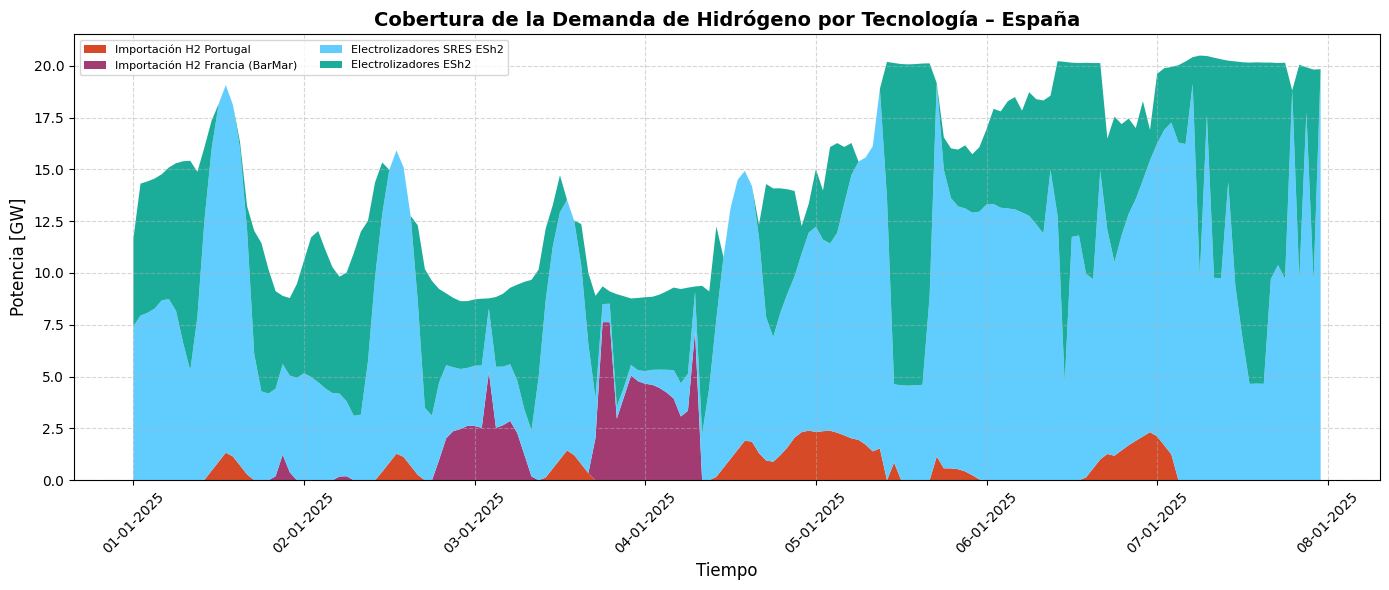

In [289]:
# COBERTURA DE LA DEMANDA DE HIDRÓGENO EN ESPAÑA

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

times = network.snapshots

# -----------------------------
# 1) Series base
# -----------------------------
if "ES_electrolyzer" in network.links_t.p1.columns:
    es_electrolyzer = -network.links_t.p1["ES_electrolyzer"].clip(upper=0).reindex(times).fillna(0.0) / 1e3
else:
    es_electrolyzer = pd.Series(0.0, index=times)

if "ES_SRES_electrolyzer" in network.links_t.p1.columns:
    es_sres_electrolyzer = -network.links_t.p1["ES_SRES_electrolyzer"].clip(upper=0).reindex(times).fillna(0.0) / 1e3
else:
    es_sres_electrolyzer = pd.Series(0.0, index=times)

if "ES_hydrogen_storage" in network.storage_units_t.p.columns:
    es_hydrogen_storage = network.storage_units_t.p["ES_hydrogen_storage"].clip(lower=0).reindex(times).fillna(0.0) / 1e3
else:
    es_hydrogen_storage = pd.Series(0.0, index=times)

if "PT_ES_interconexion_hidrogeno" in network.links_t.p1.columns:
    pt_es_h2 = -network.links_t.p1["PT_ES_interconexion_hidrogeno"].clip(upper=0).reindex(times).fillna(0.0) / 1e3
else:
    pt_es_h2 = pd.Series(0.0, index=times)

if "MA_ES_interconexion_hidrogeno" in network.links_t.p1.columns:
    ma_es_h2 = -network.links_t.p1["MA_ES_interconexion_hidrogeno"].clip(upper=0).reindex(times).fillna(0.0) / 1e3
else:
    ma_es_h2 = pd.Series(0.0, index=times)

# Francia -> España (BarMar)
if "FR_ES_interconexion_hidrogeno_BarMar" in network.links_t.p1.columns:
    fr_es_barmar = -network.links_t.p1["FR_ES_interconexion_hidrogeno_BarMar"].clip(upper=0).reindex(times).fillna(0.0) / 1e3
else:
    fr_es_barmar = pd.Series(0.0, index=times)

# -----------------------------
# 2) DataFrame
# -----------------------------
df_h2_plot = pd.DataFrame({
    "ES_electrolyzer": es_electrolyzer,
    "ES_SRES_electrolyzer": es_sres_electrolyzer,
    "ES_hydrogen_storage": es_hydrogen_storage,
    "PT_ES_interconexion_hidrogeno": pt_es_h2,
    "MA_ES_interconexion_hidrogeno": ma_es_h2,
    "FR_ES_interconexion_hidrogeno_BarMar": fr_es_barmar,
}, index=times)

# quitar columnas vacías
df_h2_plot = df_h2_plot.loc[:, (df_h2_plot.abs().sum(axis=0) > 1e-12)]

# -----------------------------
# 3) Etiquetas y colores
# -----------------------------
label_map = {
    "ES_electrolyzer": "Electrolizadores ESh2",
    "ES_SRES_electrolyzer": "Electrolizadores SRES ESh2",
    "ES_hydrogen_storage": "Almacenamientos de Hidrógeno",
    "PT_ES_interconexion_hidrogeno": "Importación H2 Portugal",
    "MA_ES_interconexion_hidrogeno": "Importación H2 Marruecos",
    "FR_ES_interconexion_hidrogeno_BarMar": "Importación H2 Francia (BarMar)",
}

color_map = {
    "ES_electrolyzer": "#1cad9a",
    "ES_SRES_electrolyzer": "#61cdff",
    "ES_hydrogen_storage": "#b1eb45",
    "PT_ES_interconexion_hidrogeno": "#d64a27",
    "MA_ES_interconexion_hidrogeno": "#fc8739",
    "FR_ES_interconexion_hidrogeno_BarMar": "#a23b72",
}

# orden deseado
plot_order = [
    "MA_ES_interconexion_hidrogeno",
    "PT_ES_interconexion_hidrogeno",
    "FR_ES_interconexion_hidrogeno_BarMar",
    "ES_SRES_electrolyzer",
    "ES_electrolyzer",
    "ES_hydrogen_storage",
]

# quedarnos solo con las columnas existentes
plot_order = [c for c in plot_order if c in df_h2_plot.columns]

# -----------------------------
# 4) Plot
# -----------------------------
plt.figure(figsize=(14, 6))

plt.stackplot(
    df_h2_plot.index,
    *[df_h2_plot[c] for c in plot_order],
    labels=[label_map[c] for c in plot_order],
    colors=[color_map[c] for c in plot_order],
    linewidth=0.0,
)

plt.title("Cobertura de la Demanda de Hidrógeno por Tecnología – España", fontsize=14, fontweight="bold")
plt.xlabel("Tiempo", fontsize=12)
plt.ylabel("Potencia [GW]", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=8, ncol=2)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\4004897877.py:14: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\4004897877.py:15: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\4004897877.py:19: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\4004897877.py:20: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as 

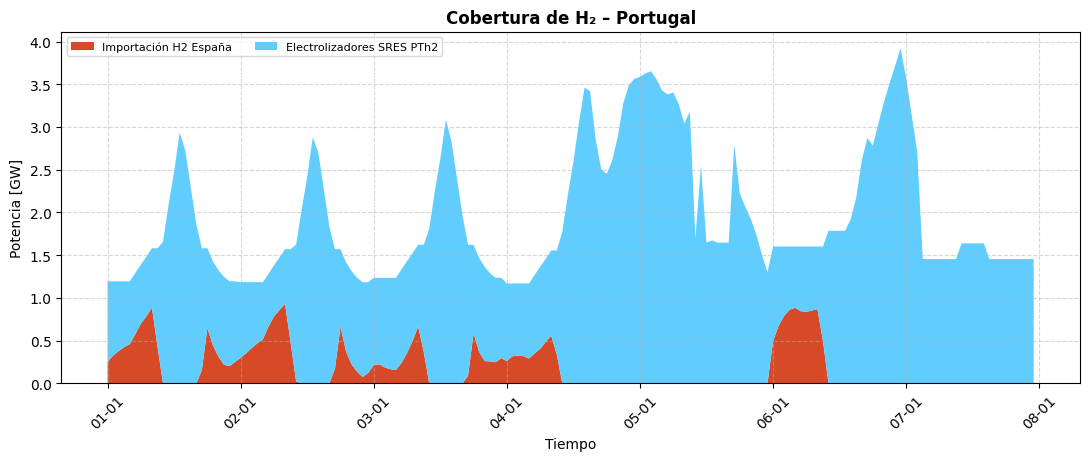

In [290]:
# COBERTURA DE LA DEMANDA DE HIDRÓGENO EN ESPAÑA

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

times = network.snapshots

# -----------------------------
# 1) Series base
# -----------------------------


if "PT_SRES_electrolyzer" in network.links_t.p1.columns:
    es_sres_electrolyzer = -network.links_t.p1["PT_SRES_electrolyzer"].clip(upper=0).reindex(times).fillna(0.0) / 1e3
else:
    es_sres_electrolyzer = pd.Series(0.0, index=times)

if "ES_PT_interconexion_hidrogeno" in network.links_t.p1.columns:
    pt_es_h2 = -network.links_t.p1["ES_PT_interconexion_hidrogeno"].clip(upper=0).reindex(times).fillna(0.0) / 1e3
else:
    pt_es_h2 = pd.Series(0.0, index=times)



# -----------------------------
# 2) DataFrame
# -----------------------------
df_h2_plot = pd.DataFrame({

    "PT_SRES_electrolyzer": es_sres_electrolyzer,

    "ES_PT_interconexion_hidrogeno": pt_es_h2,

}, index=times)

# quitar columnas vacías
df_h2_plot = df_h2_plot.loc[:, (df_h2_plot.abs().sum(axis=0) > 1e-12)]

# -----------------------------
# 3) Etiquetas y colores
# -----------------------------
label_map = {

    "PT_SRES_electrolyzer": "Electrolizadores SRES PTh2",

    "ES_PT_interconexion_hidrogeno": "Importación H2 España",

}

color_map = {

    "PT_SRES_electrolyzer": "#61cdff",

    "ES_PT_interconexion_hidrogeno": "#d64a27",

}
# quiero ordenarlos de esta forma: MA_ES_interconexion_hidrogeno, PT_ES_interconexion_hidrogeno, ES_SRES_electrolyzer, ES_electrolyzer, ES_hydrogen_storage
plot_order = ["ES_PT_interconexion_hidrogeno", "PT_SRES_electrolyzer"]

# -----------------------------
# 4) Plot
# -----------------------------
plt.figure(figsize=(11, 5))

plt.stackplot(
    df_h2_plot.index,
    *[df_h2_plot[c] for c in plot_order],
    labels=[label_map[c] for c in plot_order],
    colors=[color_map[c] for c in plot_order],
    linewidth=0.0,
)

plt.title("Cobertura de H₂ – Portugal", fontsize=12, fontweight="bold")
plt.xlabel("Tiempo", fontsize=10)
plt.ylabel("Potencia [GW]", fontsize=10)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=8, ncol=2)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
plt.show()


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\3173945297.py:30: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\3173945297.py:31: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\3173945297.py:30: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\3173945297.py:31: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more informat

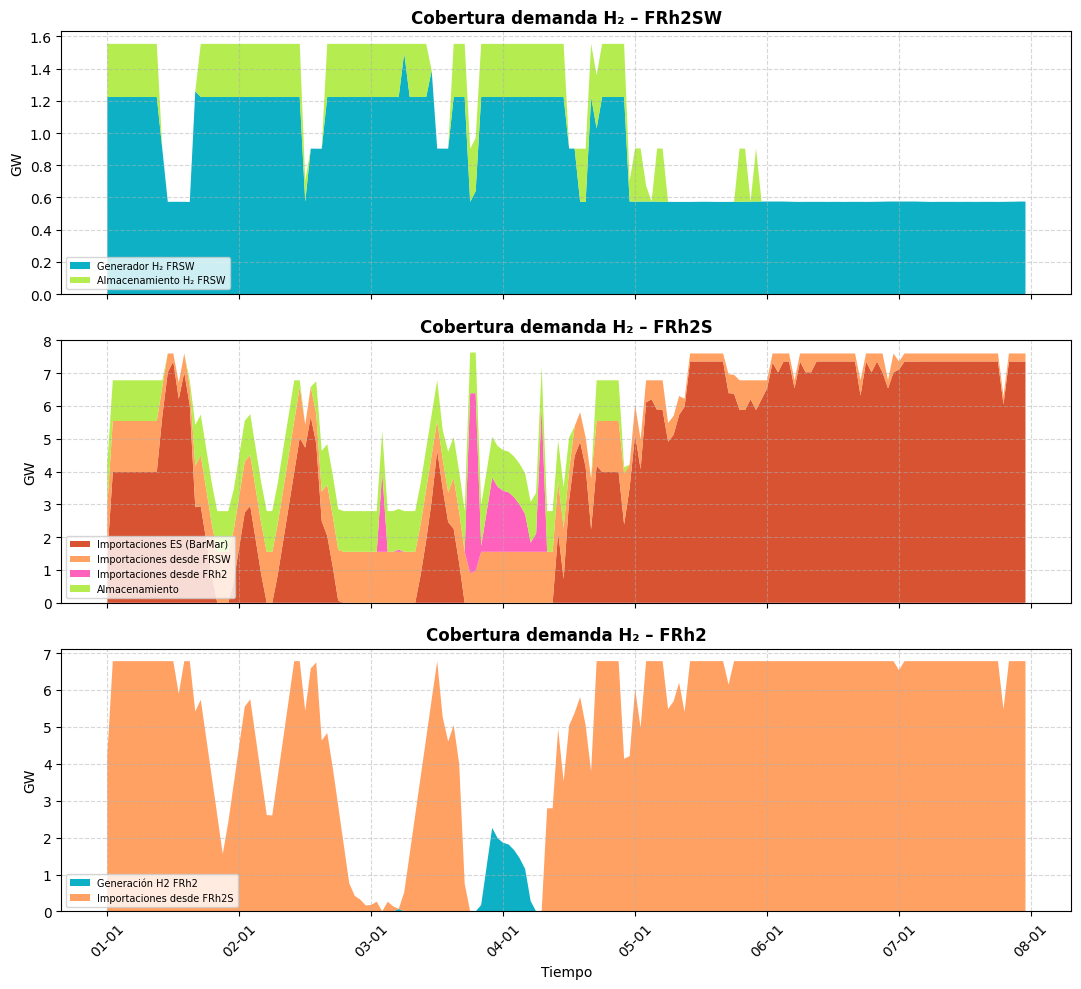

In [291]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

times = network.snapshots

# =========================================================
# FUNCIONES
# =========================================================
def get_link_p1_positive_consumption(link_name):
    """
    Devuelve la entrada al bus1 como serie positiva en GW.
    """
    if link_name in network.links_t.p1.columns:
        return -network.links_t.p1[link_name].clip(upper=0).reindex(times).fillna(0.0) / 1e3
    return pd.Series(0.0, index=times)

def get_storage_discharge(storage_name):
    """
    Solo para storage_units antiguos, en GW.
    """
    if storage_name in network.storage_units_t.p.columns:
        return network.storage_units_t.p[storage_name].clip(lower=0).reindex(times).fillna(0.0) / 1e3
    return pd.Series(0.0, index=times)

def get_generator_output(generator_name):
    """
    Devuelve generación positiva en GW.
    """
    if generator_name in network.generators_t.p.columns:
        return network.generators_t.p[generator_name].clip(lower=0).reindex(times).fillna(0.0) / 1e3
    return pd.Series(0.0, index=times)

# =========================================================
# SERIES
# =========================================================

# 🔵 GENERADORES
fr_gen_frh2 = get_generator_output("FR_hydrogen_generator_FRH2")
fr_gen_frsw = get_generator_output("FR_hydrogen_generator_FRSW")

# 🟢 STORAGE / ALMACENAMIENTO
# En el Excel nuevo, FRS y FRSW storage son generadores, no storage_units
frs_storage = get_generator_output("FRS_hydrogen_storage")
frsw_storage = get_generator_output("FRSW_hydrogen_storage")

# Si aún existiera este storage antiguo en tu modelo, lo mantiene; si no, vale 0
fr_storage = get_storage_discharge("FR_hydrogen_storage")

# 🔴 IMPORTS LINKS
# España
irun = get_link_p1_positive_consumption("ES_FR_interconexion_hidrogeno_IrunLarrau")
barmar = get_link_p1_positive_consumption("ES_FR_interconexion_hidrogeno_BarMar")

# Internos FR
sw_to_s = get_link_p1_positive_consumption("FR_FR_interconexion_hidrogeno_SWtoS")
s_to_sw = get_link_p1_positive_consumption("FR_FR_interconexion_hidrogeno_StoSW")
s_to_frh2 = get_link_p1_positive_consumption("FR_FR_interconexion_hidrogeno_StoFRh2")
frh2_to_s = get_link_p1_positive_consumption("FR_FR_interconexion_hidrogeno_FRh2toS")

# 🔴 LOAD SHEDDING H2
ls_frsw = get_generator_output("FRSW_load_shedding_h2")
ls_frs = get_generator_output("FRS_load_shedding_h2")
ls_frh2 = get_generator_output("FR_load_shedding_h2")

# =========================================================
# DATAFRAMES
# =========================================================

# 🔵 1. FRh2SW — ADAPTADO A TU EXCEL NUEVO
df_frsw = pd.DataFrame({
    "Importaciones H₂ ES (Irun-Larrau)": irun,
    "Importaciones desde FRh2S": s_to_sw,
    "Generador H₂ FRSW": fr_gen_frsw,
    "Almacenamiento H₂ FRSW": frsw_storage,
    "Load shedding H₂ FRSW": ls_frsw,
}, index=times)

# 🔴 2. FRh2S — lo dejo casi como estaba por ahora
df_frs = pd.DataFrame({
    "Importaciones ES (BarMar)": barmar,
    "Importaciones desde FRSW": sw_to_s,
    "Importaciones desde FRh2": frh2_to_s,
    "Almacenamiento": frs_storage,
    "Load shedding H₂ FRS": ls_frs,
}, index=times)

# 🟢 3. FRh2 — lo dejo casi como estaba por ahora
df_frh2 = pd.DataFrame({
    "Generación H2 FRh2": fr_gen_frh2,
    "Importaciones desde FRh2S": s_to_frh2,
    "Almacenamiento": fr_storage,
    "Load shedding H₂ FRh2": ls_frh2,
}, index=times)

# limpiar columnas vacías
df_frsw = df_frsw.loc[:, (df_frsw.abs().sum(axis=0) > 1e-12)]
df_frs = df_frs.loc[:, (df_frs.abs().sum(axis=0) > 1e-12)]
df_frh2 = df_frh2.loc[:, (df_frh2.abs().sum(axis=0) > 1e-12)]

# =========================================================
# COLORES
# =========================================================
color_map = {
    "Generación H2 FRSW": "#00ACC1",
    "Generador H₂ FRSW": "#00ACC1",
    "Generación H2 FRh2": "#00ACC1",

    "Importaciones ES (Irun-Larrau)": "#d64a27",
    "Importaciones H₂ ES (Irun-Larrau)": "#d64a27",
    "Importaciones ES (BarMar)": "#d64a27",

    "Importaciones desde FRSW": "#ff9c5b",
    "Importaciones desde FRh2S": "#ff9c5b",
    "Importaciones desde FRh2": "#ff59ba",

    "Almacenamiento": "#b1eb45",
    "Almacenamiento H₂ FRSW": "#b1eb45",

    "Load shedding H₂ FRSW": "#FF0000",
    "Load shedding H₂ FRS": "#FF0000",
    "Load shedding H₂ FRh2": "#FF0000",
}

# =========================================================
# PLOT
# =========================================================
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

dfs = [df_frsw, df_frs, df_frh2]
titles = [
    "Cobertura demanda H₂ – FRh2SW",
    "Cobertura demanda H₂ – FRh2S",
    "Cobertura demanda H₂ – FRh2",
]

for df, ax, title in zip(dfs, axes, titles):
    order = list(df.columns)

    ax.stackplot(
        df.index,
        *[df[c] for c in order],
        labels=order,
        colors=[color_map.get(c, "#BAB0AC") for c in order],
        linewidth=0,
        alpha=0.95
    )

    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("GW")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="lower left", fontsize=7)

# eje X
axes[-1].set_xlabel("Tiempo")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\1533542799.py:4: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.loads.dynamic` as a drop-in replacement for `n.loads_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\1533542799.py:6: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.loads.dynamic` as a drop-in replacement for `n.loads_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\1533542799.py:22: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\1533542799.py:46: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.link

Links export electricidad ES->PT encontrados: ['ES_PT_interconexion_electricidad']
Links export electricidad ES->FR00 encontrados: ['ES_FR_interconexion_electricidad']
Links electrólizadores ES encontrados: ['ES_electrolyzer', 'ES_SRES_electrolyzer']
Links export H2 ES->PT encontrados: ['ES_PT_interconexion_hidrogeno']
Links export H2 ES->FRSW encontrados: ['ES_FR_interconexion_hidrogeno_IrunLarrau']
Links export H2 ES->FRS encontrados: ['ES_FR_interconexion_hidrogeno_BarMar']


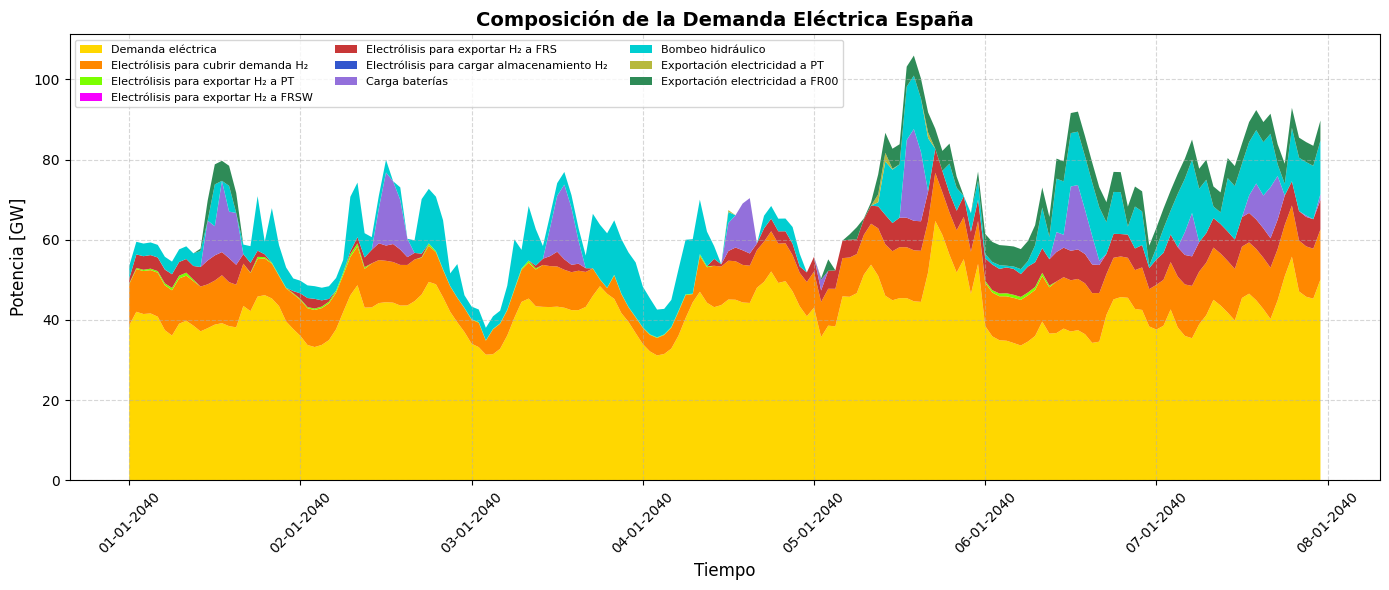

In [292]:
# ----------------------------- DEMANDA ELÉCTRICA (LOAD) -----------------------------
idx = network.snapshots

if "ES_demand_2040" in network.loads_t.p_set.columns:
    national_electricity_demand = (
        network.loads_t.p_set["ES_demand_2040"]
        .reindex(idx)
        .fillna(0.0) / 1e3
    )
else:
    raise ValueError("No encuentro 'ES_demand_2040' en network.loads_t.p_set")

# ----------------------------- ÍNDICES ROBUSTOS -------------------------------------
link_index = network.links.static.index
su_index = network.storage_units.static.index

# ----------------------------- STORAGE UNITS ----------------------------------------
battery_sus = [n for n in su_index if "es_electricity_market_battery" in n.lower()]
h2_sus = [n for n in su_index if "es_hydrogen_storage" in n.lower()]

battery_charge = (
    network.storage_units_t.p[battery_sus]
    .clip(upper=0)
    .sum(axis=1)
    .abs()
    .reindex(idx)
    .fillna(0.0) / 1e3
) if len(battery_sus) else pd.Series(0.0, index=idx)

h2_charge = (
    network.storage_units_t.p[h2_sus]
    .clip(upper=0)
    .sum(axis=1)
    .abs()
    .reindex(idx)
    .fillna(0.0) / 1e3
) if len(h2_sus) else pd.Series(0.0, index=idx)

# ----------------------------- BOMBEO HIDRÁULICO ------------------------------------
pumped_links = [
    l for l in link_index
    if ("es_pump" in l.lower()) or ("es_turbina" in l.lower())
]

pumping_demand = (
    network.links_t.p0[pumped_links]
    .clip(lower=0)
    .sum(axis=1)
    .reindex(idx)
    .fillna(0.0) / 1e3
) if len(pumped_links) else pd.Series(0.0, index=idx)

# ----------------------------- EXPORT ELECTRICIDAD ES -> PT -------------------------
exportelectricity_pt_links = [
    l for l in link_index
    if "es_pt_interconexion_electricidad" in l.lower()
]

exportelectricity_pt_demand = (
    network.links_t.p0[exportelectricity_pt_links]
    .clip(lower=0)
    .sum(axis=1)
    .reindex(idx)
    .fillna(0.0) / 1e3
) if len(exportelectricity_pt_links) else pd.Series(0.0, index=idx)

# ----------------------------- EXPORT ELECTRICIDAD ES -> FR00 -----------------------
exportelectricity_fr_links = [
    l for l in link_index
    if (
        "es_fr00_interconexion_electricidad" in l.lower()
        or "es_fr_interconexion_electricidad" in l.lower()
        or ("es" in l.lower() and "fr00" in l.lower() and "electricidad" in l.lower())
    )
]

exportelectricity_fr_demand = (
    network.links_t.p0[exportelectricity_fr_links]
    .clip(lower=0)
    .sum(axis=1)
    .reindex(idx)
    .fillna(0.0) / 1e3
) if len(exportelectricity_fr_links) else pd.Series(0.0, index=idx)

# ----------------------------- ELECTROLIZADORES (ELECTRICIDAD CONSUMIDA) -----------
electrolyzer_links = [
    l for l in network.links.static.index
    if (
        network.links.static.loc[l, "bus0"].startswith("ES")
        and "electrolyzer" in l.lower()
    )
]

electrolyzer_electricity = (
    network.links_t.p0[electrolyzer_links]
    .clip(lower=0)
    .sum(axis=1)
    .reindex(idx)
    .fillna(0.0) / 1e3
) if len(electrolyzer_links) else pd.Series(0.0, index=idx)

# ========================= DESTINOS DEL H2 PRODUCIDO EN ES ==========================
# 1) Demanda H2 nacional
h2_load_names = [
    n for n in network.loads_t.p_set.columns
    if "es_hydrogen_demand" in n.lower()
]

h2_demand = (
    network.loads_t.p_set[h2_load_names]
    .sum(axis=1)
    .reindex(idx)
    .fillna(0.0) / 1e3
) if len(h2_load_names) else pd.Series(0.0, index=idx)

# 2) Export H2 ES -> PT
export_h2_pt_links = [
    l for l in link_index
    if "es_pt_interconexion_hidrogeno" in l.lower()
]

export_h2_pt = (
    network.links_t.p0[export_h2_pt_links]
    .clip(lower=0)
    .sum(axis=1)
    .reindex(idx)
    .fillna(0.0) / 1e3
) if len(export_h2_pt_links) else pd.Series(0.0, index=idx)

# 3) Export H2 ES -> FRSW (Irun/Larrau)
export_h2_frsw_links = [
    l for l in link_index
    if "es_fr_interconexion_hidrogeno_irunlarrau" in l.lower()
]

export_h2_frsw = (
    network.links_t.p0[export_h2_frsw_links]
    .clip(lower=0)
    .sum(axis=1)
    .reindex(idx)
    .fillna(0.0) / 1e3
) if len(export_h2_frsw_links) else pd.Series(0.0, index=idx)

# 4) Export H2 ES -> FRS (BarMar)
export_h2_frs_links = [
    l for l in link_index
    if "es_fr_interconexion_hidrogeno_barmar" in l.lower()
]

export_h2_frs = (
    network.links_t.p0[export_h2_frs_links]
    .clip(lower=0)
    .sum(axis=1)
    .reindex(idx)
    .fillna(0.0) / 1e3
) if len(export_h2_frs_links) else pd.Series(0.0, index=idx)

# 5) Carga almacenamiento H2 = h2_charge

# ----------------------------- REPARTO PROPORCIONAL ---------------------------------
h2_sinks_total = (
    h2_demand
    + export_h2_pt
    + export_h2_frsw
    + export_h2_frs
    + h2_charge
)

with np.errstate(divide="ignore", invalid="ignore"):
    share_demand = np.where(h2_sinks_total != 0, h2_demand / h2_sinks_total, 0.0)
    share_export_pt = np.where(h2_sinks_total != 0, export_h2_pt / h2_sinks_total, 0.0)
    share_export_frsw = np.where(h2_sinks_total != 0, export_h2_frsw / h2_sinks_total, 0.0)
    share_export_frs = np.where(h2_sinks_total != 0, export_h2_frs / h2_sinks_total, 0.0)
    share_store = np.where(h2_sinks_total != 0, h2_charge / h2_sinks_total, 0.0)

share_demand = pd.Series(share_demand, index=idx)
share_export_pt = pd.Series(share_export_pt, index=idx)
share_export_frsw = pd.Series(share_export_frsw, index=idx)
share_export_frs = pd.Series(share_export_frs, index=idx)
share_store = pd.Series(share_store, index=idx)

elec_for_h2_demand = electrolyzer_electricity * share_demand
elec_for_h2_export_pt = electrolyzer_electricity * share_export_pt
elec_for_h2_export_frsw = electrolyzer_electricity * share_export_frsw
elec_for_h2_export_frs = electrolyzer_electricity * share_export_frs
elec_for_h2_storage = electrolyzer_electricity * share_store

# ----------------------------- DEBUG OPCIONAL ---------------------------------------
print("Links export electricidad ES->PT encontrados:", exportelectricity_pt_links)
print("Links export electricidad ES->FR00 encontrados:", exportelectricity_fr_links)
print("Links electrólizadores ES encontrados:", electrolyzer_links)
print("Links export H2 ES->PT encontrados:", export_h2_pt_links)
print("Links export H2 ES->FRSW encontrados:", export_h2_frsw_links)
print("Links export H2 ES->FRS encontrados:", export_h2_frs_links)

# ----------------------------- GRÁFICA STACKPLOT ------------------------------------
plt.figure(figsize=(14, 6))

plt.stackplot(
    idx,
    national_electricity_demand,
    elec_for_h2_demand,
    elec_for_h2_export_pt,
    elec_for_h2_export_frsw,
    elec_for_h2_export_frs,
    elec_for_h2_storage,
    battery_charge,
    pumping_demand,
    exportelectricity_pt_demand,
    exportelectricity_fr_demand,
    labels=[
        "Demanda eléctrica",
        "Electrólisis para cubrir demanda H₂",
        "Electrólisis para exportar H₂ a PT",
        "Electrólisis para exportar H₂ a FRSW",
        "Electrólisis para exportar H₂ a FRS",
        "Electrólisis para cargar almacenamiento H₂",
        "Carga baterías",
        "Bombeo hidráulico",
        "Exportación electricidad a PT",
        "Exportación electricidad a FR00",
    ],
    colors=[
        "#FFD700",
        "#FF8800",
        "#7BFF00",
        "#F700FF",
        "#C83737",
        "#3256CD",
        "#9370DB",
        "#00CED1",
        "#B7B93DFF",
        "#2E8B57",
    ],
    linewidth=0.0,
)

plt.title("Composición de la Demanda Eléctrica España", fontsize=14, fontweight="bold")
plt.xlabel("Tiempo", fontsize=12)
plt.ylabel("Potencia [GW]", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=8, ncol=3)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%m-2040"))
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\2467200635.py:4: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.loads.dynamic` as a drop-in replacement for `n.loads_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\2467200635.py:6: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.loads.dynamic` as a drop-in replacement for `n.loads_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\2467200635.py:22: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\2467200635.py:46: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.link

Electrolizadores PT detectados: ['PT_electrolyzer', 'PT_SRES_electrolyzer']


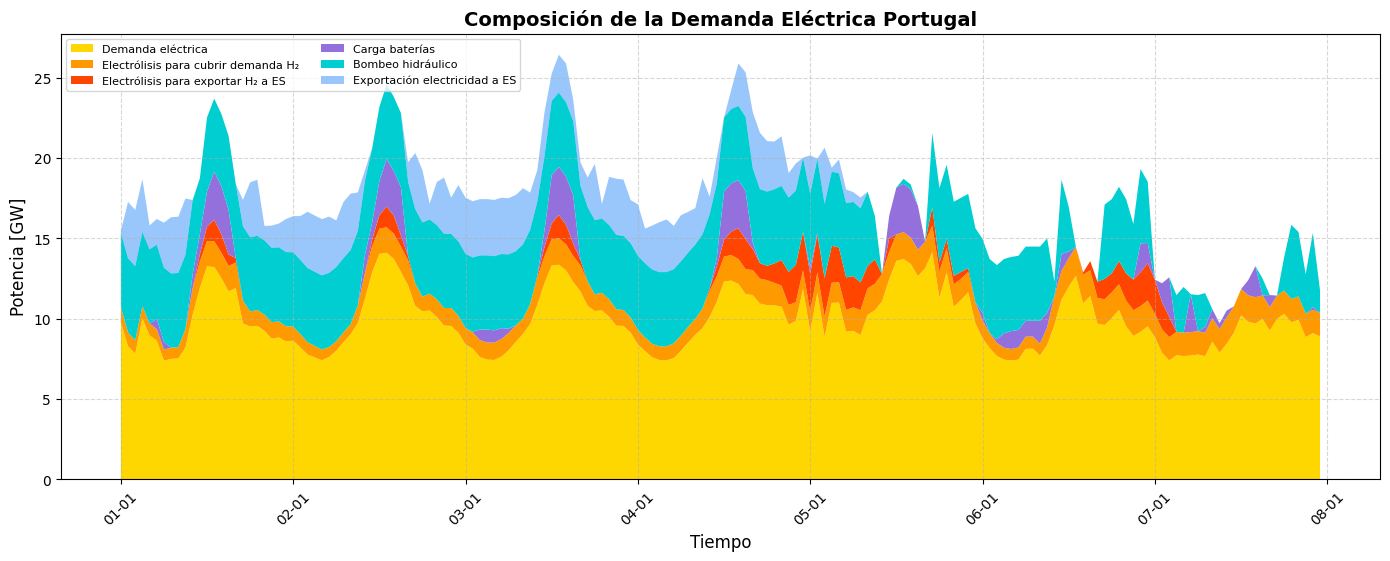

In [293]:
# ----------------------------- DEMANDA ELÉCTRICA (LOAD) -----------------------------
idx = network.snapshots

if "PT_demand_2040" in network.loads_t.p_set.columns:
    national_electricity_demand = (
        network.loads_t.p_set["PT_demand_2040"]
        .reindex(idx)
        .fillna(0.0) / 1e3
    )
else:
    raise ValueError("No encuentro 'PT_demand_2040' en network.loads_t.p_set")

# ----------------------------- ÍNDICES ROBUSTOS -------------------------------------
link_index = network.links.static.index
su_index = network.storage_units.static.index

# ----------------------------- STORAGE UNITS ----------------------------------------
battery_sus = [n for n in su_index if "pt_electricity_market_battery" in n.lower()]
h2_sus = [n for n in su_index if "pt_hydrogen_storage" in n.lower()]

battery_charge = (
    network.storage_units_t.p[battery_sus]
    .clip(upper=0)
    .sum(axis=1)
    .abs()
    .reindex(idx)
    .fillna(0.0) / 1e3
) if battery_sus else pd.Series(0.0, index=idx)

h2_charge = (
    network.storage_units_t.p[h2_sus]
    .clip(upper=0)
    .sum(axis=1)
    .abs()
    .reindex(idx)
    .fillna(0.0) / 1e3
) if h2_sus else pd.Series(0.0, index=idx)

# ----------------------------- BOMBEO HIDRÁULICO ------------------------------------
pumped_links = [
    l for l in link_index
    if ("pt_pump" in l.lower()) or ("pt_turbina" in l.lower())
]

pumping_demand = (
    network.links_t.p0[pumped_links]
    .clip(lower=0)
    .sum(axis=1)
    .reindex(idx)
    .fillna(0.0) / 1e3
) if pumped_links else pd.Series(0.0, index=idx)

# ----------------------------- EXPORT ELECTRICIDAD PT -> ES -------------------------
exportelectricity_links = [
    l for l in link_index
    if "pt_es_interconexion_electricidad" in l.lower()
]

exportelectricity_demand = (
    network.links_t.p0[exportelectricity_links]
    .clip(lower=0)
    .sum(axis=1)
    .reindex(idx)
    .fillna(0.0) / 1e3
) if exportelectricity_links else pd.Series(0.0, index=idx)

# ----------------------------- ELECTROLIZADORES PT (ROBUSTO) ------------------------
# 👉 funciona para 1bus y 2bus automáticamente
electrolyzer_links = [
    l for l in link_index
    if (
        l.lower().startswith("pt")
        and "electrolyzer" in l.lower()
    )
]

electrolyzer_electricity = (
    network.links_t.p0[electrolyzer_links]
    .clip(lower=0)
    .sum(axis=1)
    .reindex(idx)
    .fillna(0.0) / 1e3
) if electrolyzer_links else pd.Series(0.0, index=idx)

# DEBUG (opcional pero recomendable)
print("Electrolizadores PT detectados:", electrolyzer_links)

# ========================= PARTIR ELECTRÓLISIS EN 3 (H2) ============================

# 1) Demanda H2 PT
if "PT_hydrogen_demand" in network.loads_t.p_set.columns:
    h2_demand = (
        network.loads_t.p_set["PT_hydrogen_demand"]
        .reindex(idx)
        .fillna(0.0) / 1e3
    )
else:
    h2_demand = pd.Series(0.0, index=idx)

# 2) Export H2 PT -> ES
export_h2_links = [
    l for l in link_index
    if "pt_es_interconexion_hidrogeno" in l.lower()
]

export_h2 = (
    network.links_t.p0[export_h2_links]
    .clip(lower=0)
    .sum(axis=1)
    .reindex(idx)
    .fillna(0.0) / 1e3
) if export_h2_links else pd.Series(0.0, index=idx)

# 3) Carga almacenamiento H2 = h2_charge

# ----------------------------- REPARTO PROPORCIONAL ---------------------------------
h2_sinks_total = h2_demand + export_h2 + h2_charge

with np.errstate(divide="ignore", invalid="ignore"):
    share_demand = np.where(h2_sinks_total != 0, h2_demand / h2_sinks_total, 0.0)
    share_export = np.where(h2_sinks_total != 0, export_h2 / h2_sinks_total, 0.0)
    share_store = np.where(h2_sinks_total != 0, h2_charge / h2_sinks_total, 0.0)

share_demand = pd.Series(share_demand, index=idx)
share_export = pd.Series(share_export, index=idx)
share_store = pd.Series(share_store, index=idx)

elec_for_h2_demand = electrolyzer_electricity * share_demand
elec_for_h2_export = electrolyzer_electricity * share_export
elec_for_h2_storage = electrolyzer_electricity * share_store

# ----------------------------- GRÁFICA STACKPLOT -----------------------------------

series_to_plot = {
    "Demanda eléctrica": national_electricity_demand,
    "Electrólisis para cubrir demanda H₂": elec_for_h2_demand,
    "Electrólisis para exportar H₂ a ES": elec_for_h2_export,
    "Electrólisis para cargar almacenamiento H₂": elec_for_h2_storage,
    "Carga baterías": battery_charge,
    "Bombeo hidráulico": pumping_demand,
    "Exportación electricidad a ES": exportelectricity_demand,
}

# quitar series vacías
series_to_plot = {k: v for k, v in series_to_plot.items() if v.abs().sum() > 1e-12}

color_map = {
    "Demanda eléctrica": "#FFD700",
    "Electrólisis para cubrir demanda H₂": "#FF9900",
    "Electrólisis para exportar H₂ a ES": "#FF4500",
    "Electrólisis para cargar almacenamiento H₂": "#3256CD",
    "Carga baterías": "#9370DB",
    "Bombeo hidráulico": "#00CED1",
    "Exportación electricidad a ES": "#2386F776",
}

plt.figure(figsize=(14, 6))

plt.stackplot(
    idx,
    *[series_to_plot[k] for k in series_to_plot.keys()],
    labels=list(series_to_plot.keys()),
    colors=[color_map[k] for k in series_to_plot.keys()],
    linewidth=0.0,
)

plt.title(
    "Composición de la Demanda Eléctrica Portugal",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Tiempo", fontsize=12)
plt.ylabel("Potencia [GW]", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=8, ncol=2)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\2169954112.py:14: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.loads.dynamic` as a drop-in replacement for `n.loads_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\2169954112.py:16: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.loads.dynamic` as a drop-in replacement for `n.loads_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\2169954112.py:53: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.



Baterías FR00 detectadas: []
Links exportación FR->ES detectados: ['FR_ES_interconexion_electricidad']


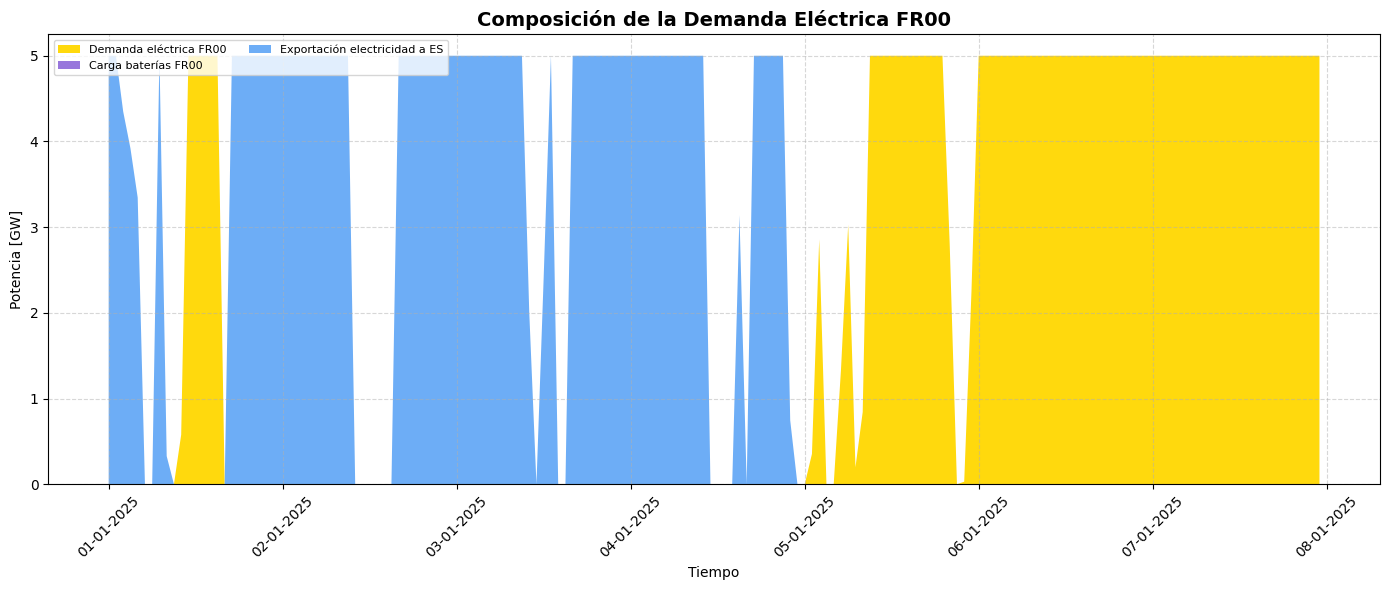

In [294]:
# ==============================
# DEMANDA ELÉCTRICA FR00
# Solo:
# - Demanda eléctrica FR00
# - Carga de baterías
# - Exportación electricidad a ES
# ==============================

idx = network.snapshots

# -----------------------------
# 1) DEMANDA ELÉCTRICA FR00
# -----------------------------
if "FR_demand_2040" in network.loads_t.p_set.columns:
    demanda_fr00 = (
        network.loads_t.p_set["FR_demand_2040"]
        .reindex(idx)
        .fillna(0.0) / 1e3   # MW -> GW
    )
else:
    raise ValueError("No encuentro 'FR_demand_2040' en network.loads_t.p_set.columns")

# -----------------------------
# 2) CARGA DE BATERÍAS FR00
# -----------------------------
su_index = network.storage_units.static.index

battery_sus = [
    n for n in su_index
    if "fr_electricity_market_battery" in n.lower()
]

carga_baterias = (
    network.storage_units_t.p[battery_sus]
    .clip(upper=0)
    .sum(axis=1)
    .abs()
    .reindex(idx)
    .fillna(0.0) / 1e3   # MW -> GW
) if battery_sus else pd.Series(0.0, index=idx)

# -----------------------------
# 3) EXPORTACIÓN ELECTRICIDAD FR -> ES
# -----------------------------
link_index = network.links.static.index

export_links = [
    l for l in link_index
    if "fr_es_interconexion_electricidad" in l.lower()
]

exportacion_es = (
    network.links_t.p0[export_links]
    .clip(lower=0)
    .sum(axis=1)
    .reindex(idx)
    .fillna(0.0) / 1e3   # MW -> GW
) if export_links else pd.Series(0.0, index=idx)

# -----------------------------
# DEBUG
# -----------------------------
print("Baterías FR00 detectadas:", battery_sus)
print("Links exportación FR->ES detectados:", export_links)

# -----------------------------
# STACKPLOT
# -----------------------------
plt.figure(figsize=(14, 6))

plt.stackplot(
    idx,
    demanda_fr00,
    carga_baterias,
    exportacion_es,
    labels=[
        "Demanda eléctrica FR00",
        "Carga baterías FR00",
        "Exportación electricidad a ES",
    ],
    colors=[
        "#FFD700",
        "#9370DB",
        "#65A9F6",
    ],
    linewidth=0.0,
    alpha=0.95
)

plt.title("Composición de la Demanda Eléctrica FR00", fontsize=14, fontweight="bold")
plt.xlabel("Tiempo")
plt.ylabel("Potencia [GW]")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=8, ncol=2)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%m-%Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\2307007063.py:7: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



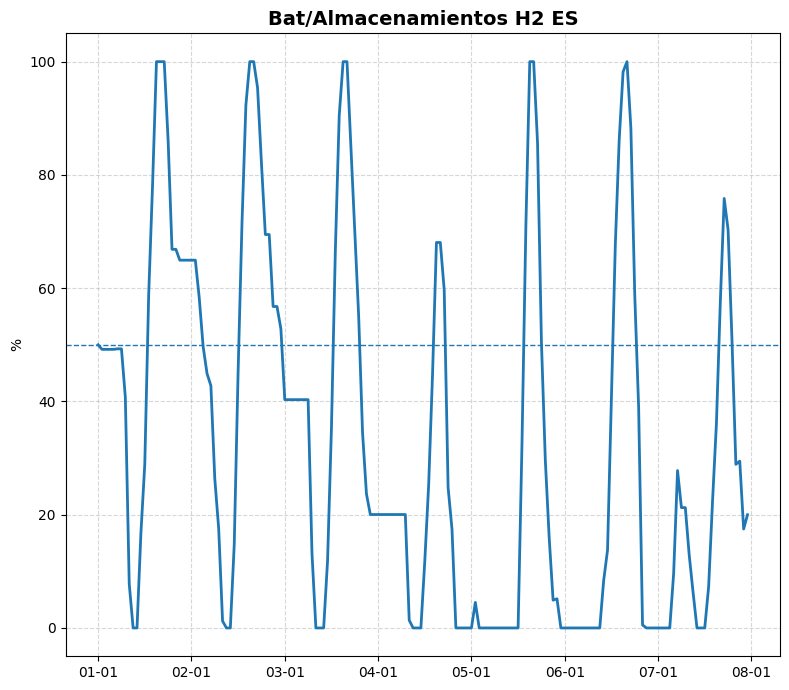

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\2307007063.py:7: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



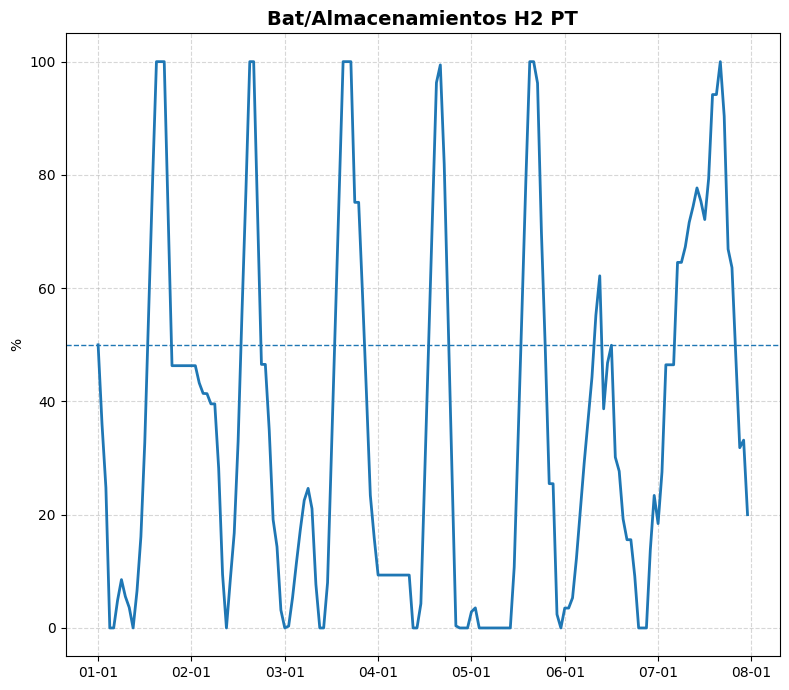

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\2307007063.py:7: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



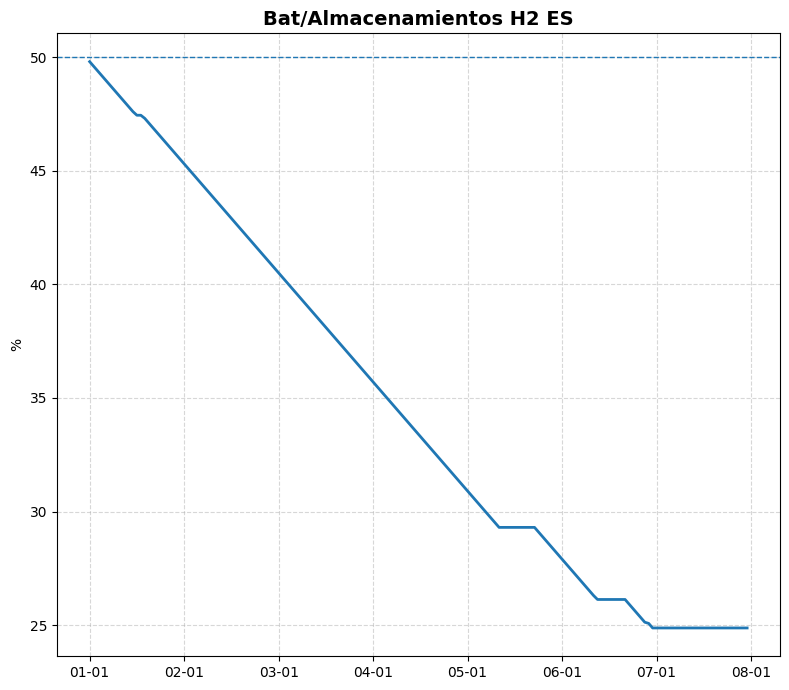

In [295]:

def plot_soc_percent(network, battery_name):
    su = network.storage_units.static
    p_nom = float(su.loc[battery_name, "p_nom"])
    max_hours = float(su.loc[battery_name, "max_hours"])
    Emax = p_nom * max_hours

    soc = network.storage_units_t.state_of_charge[battery_name].astype(float)
    soc_pct = soc / Emax * 100

    plt.figure(figsize=(8,7))
    plt.plot(soc_pct.index, soc_pct, linewidth=2)
    plt.axhline(50, linestyle="--", linewidth=1)
    plt.title(f"Bat/Almacenamientos H2 {battery_name.split('_')[0].upper()}", fontsize=14, fontweight="bold")
    plt.ylabel("%")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
    plt.tight_layout()
    plt.show()

plot_soc_percent(network, "ES_electricity_market_battery")
plot_soc_percent(network, "PT_electricity_market_battery")
plot_soc_percent(network, "ES_hydrogen_market_battery")

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\4171288439.py:4: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\4171288439.py:6: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



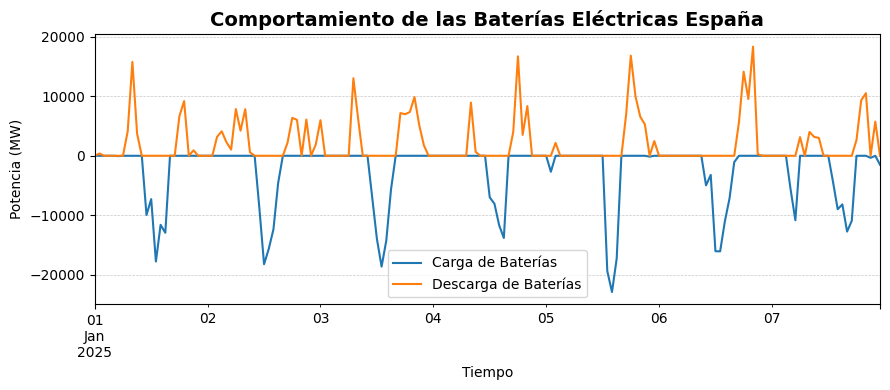

In [296]:
#Grafica de la baterias electricas

#extraemos la serie de carga de las baterias electricas
battery_charge = network.storage_units_t.p["ES_electricity_market_battery"].clip(upper=0)
#extraemos la serie de descarga de las baterias electricas
battery_discharge = network.storage_units_t.p["ES_electricity_market_battery"].clip(lower=0)
#graficamos la carga y descarga de las baterias electricas
plt.figure(figsize=(9,4))
battery_charge.plot(label="Carga de Baterías", color="tab:blue")
battery_discharge.plot(label="Descarga de Baterías", color="tab:orange")
plt.title("Comportamiento de las Baterías Eléctricas España", fontsize=14, fontweight="bold")
plt.ylabel("Potencia (MW)")
plt.xlabel("Tiempo")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

# OJO

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\125842920.py:4: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\125842920.py:6: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



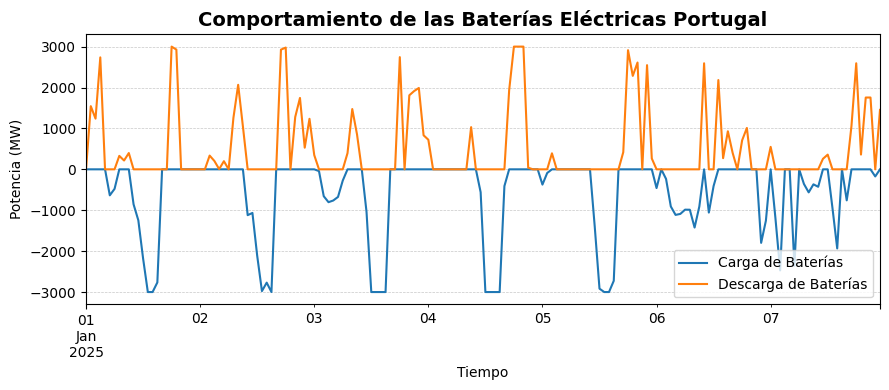

In [297]:
#Grafica de la baterias electricas

#extraemos la serie de carga de las baterias electricas
battery_charge = network.storage_units_t.p["PT_electricity_market_battery"].clip(upper=0)
#extraemos la serie de descarga de las baterias electricas
battery_discharge = network.storage_units_t.p["PT_electricity_market_battery"].clip(lower=0)
#graficamos la carga y descarga de las baterias electricas
plt.figure(figsize=(9,4))
plt.style.use('default')
battery_charge.plot(label="Carga de Baterías", color="tab:blue")
battery_discharge.plot(label="Descarga de Baterías", color="tab:orange")
plt.title("Comportamiento de las Baterías Eléctricas Portugal", fontsize=14, fontweight="bold")
plt.ylabel("Potencia (MW)")
plt.xlabel("Tiempo")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\403570839.py:2: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



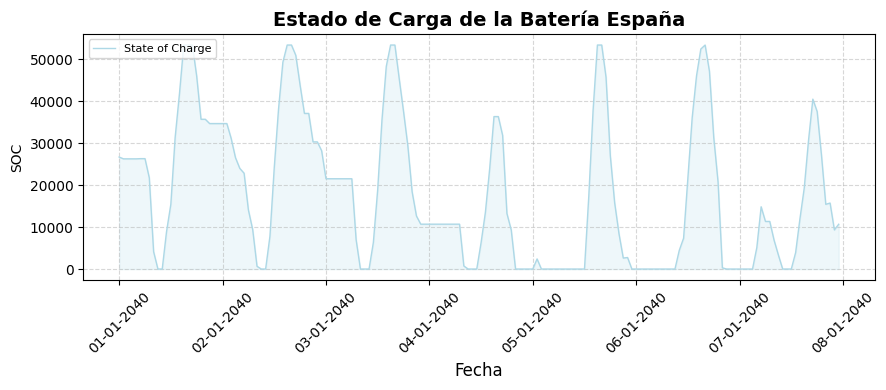

In [298]:
#Grafica del estado de carga de las baterías
soc_batt = network.storage_units_t.state_of_charge["ES_electricity_market_battery"]
plt.figure(figsize=(9,4))
plt.style.use('default')
plt.plot(hours, soc_batt, label="State of Charge", color="lightblue", linewidth=1, linestyle="-")
plt.fill_between(hours, soc_batt, color="lightblue", alpha=0.2)    
plt.title("Estado de Carga de la Batería España", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("SOC", fontsize=10)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=8)
plt.tight_layout()

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-2040'))
plt.xticks(rotation=45)
plt.show()



C:\Users\EXT10348\AppData\Local\Temp\ipykernel_15280\2858478556.py:2: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



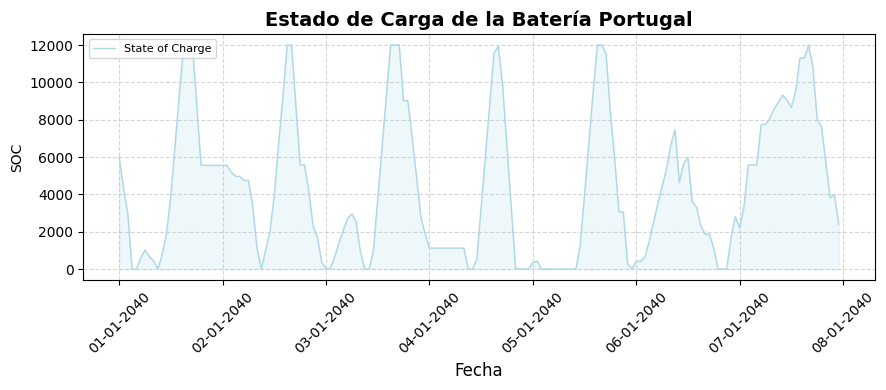

In [299]:
#Grafica del estado de carga de las baterías
soc_batt = network.storage_units_t.state_of_charge["PT_electricity_market_battery"]
plt.figure(figsize=(9,4))
plt.style.use('default')
plt.plot(hours, soc_batt, label="State of Charge", color="lightblue", linewidth=1, linestyle="-")
plt.fill_between(hours, soc_batt, color="lightblue", alpha=0.2)    
plt.title("Estado de Carga de la Batería Portugal", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("SOC", fontsize=10)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=8)
plt.tight_layout()

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-2040'))
plt.xticks(rotation=45)
plt.show()
